# exp07 : aux-term factorization and the Hann edge fix
Display + audit of exp07 (10 cells: `recon_aux` type {combined, log_psd} x weight {0.1, 0.3} plus theHann-tapered `hann0p3` cell, each x dyn {off, fwd_bwd}, at the locked geometry 256x16, ep100, fb=0,lambda=60 everywhere except lpsd0p1 at 75; seeds 0-3, extended to 0-5 on {comb0p3, hann0p3} x both arms= 48 runs). exp07 froze `hann0p3` as the ML4PS recipe, so this notebook is both the record of thatdecision and the health check on the frozen model: it recomputes every pre-registered gate from the rawCSVs and asserts against `experiments/exp07_aux_README.md`, then adds four exp07-native investigationsthat no existing artifact could answer - what the taper cost, whether the residual edge is systematic,whether the taper changed the latent, and where the pulsating win lives.**Footing discipline.** The extension ran only {comb0p3, hann0p3}; the lpsd and weight-0.1 cells stoppedat 4 seeds. Every panel below states its own footing and arm in the title, and no panel mixes them: theheadline gates are 6-seed / 4 cells, the factorization panels are 4-seed / 10 cells. Selection is onABSOLUTE probe score, never on validation loss (which anti-predicts probe winners, rho -0.58..-0.84) andnever on seed.Sources: manifest `experiments/configs/exp07_aux_factorization.yaml` (single source of truth), writeup`experiments/exp07_aux_README.md`, pre-check mechanism `tmp/handoff/2026-08-01-exp07-precheck-results-handoff.md`.The native panels read `experiments/exp07_diag_*.{csv,parquet}`, written by`experiments/analyze_exp07_diagnostics.py`.

In [1]:
# --- parameters ---
RECIPES = ["comb0p3", "comb0p1", "lpsd0p3", "lpsd0p1", "hann0p3"]
EXT_RECIPES = ["comb0p3", "hann0p3"]          # the only cells extended to 6 seeds
WINNER, BASELINE = "hann0p3", "comb0p3"       # winner selected on absolute probe score (G-noregress)
LAMBDA = {"comb0p3": 60, "comb0p1": 60, "lpsd0p3": 60, "lpsd0p1": 75, "hann0p3": 60}
ARMS = {"off": "dyn-off", "fbwd": "fwd+bwd"}
SEEDS4, SEEDS6 = list(range(4)), list(range(6))
PANEL_SEED = 0                                # seed used for the per-star visual panels
CKPT = "best_recon_aux"                       # lambda-independent selection (train.select_include_dyn=false)
WINDOW = 256
DOSE_BAND = (0.6, 1.4)                        # manifest G-dose gate on lambda * dyn / recon

In [2]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel

device = "cuda" if torch.cuda.is_available() else "cpu"
TASKS = ["transit", "eb", "pulsating", "rotation"]
EXPS = root / "experiments"
CURVES = EXPS / "exp07_forensics" / "curves_exp07"

# Fail loud: a missing artifact must stop the notebook, never quietly render stale numbers.
REQUIRED = [EXPS / "exp07_aux_gap.csv", EXPS / "exp07_aux_gap_6seed.csv", EXPS / "exp07_aux_acf.csv",
            EXPS / "exp07_aux_acf_6seed.csv", EXPS / "exp07_edge_ratios.csv",
            EXPS / "exp07_edge_profiles_6seed.parquet", EXPS / "exp07_edge_sweep_6seed.csv",
            EXPS / "exp07_amp_dominance.csv", EXPS / "exp07_dose_gate.csv", CURVES,
            EXPS / "exp07_diag_spectral_bins.csv", EXPS / "exp07_diag_spectral_peaks.csv",
            EXPS / "exp07_diag_cca.csv", EXPS / "exp07_diag_residual_probe.csv",
            EXPS / "exp07_diag_star_scores.parquet", EXPS / "exp07_diag_probe_summary.csv",
            EXPS / "exp07_edge_noise_stars.csv", EXPS / "exp07_edge_noise_summary.csv"]
missing = [str(p) for p in REQUIRED if not p.exists()]
assert not missing, f"missing artifacts (run the exp07 eval fan + analyze_exp07_diagnostics.py first): {missing}"

gap4 = pd.read_csv(EXPS / "exp07_aux_gap.csv")
gap6 = pd.read_csv(EXPS / "exp07_aux_gap_6seed.csv")
acf4 = pd.read_csv(EXPS / "exp07_aux_acf.csv")
acf6 = pd.read_csv(EXPS / "exp07_aux_acf_6seed.csv")
edge_ratios = pd.read_csv(EXPS / "exp07_edge_ratios.csv")
edge_profile = pd.read_parquet(EXPS / "exp07_edge_profiles_6seed.parquet")
edge_sweep = pd.read_csv(EXPS / "exp07_edge_sweep_6seed.csv")
amp = pd.read_csv(EXPS / "exp07_amp_dominance.csv")
dose_csv = pd.read_csv(EXPS / "exp07_dose_gate.csv")
subset = pd.read_parquet(root / "processed/subset/subset_tics.parquet")
print("device", device, "| curves", len(list(CURVES.glob("exp07_comb*.csv"))) +
      len(list(CURVES.glob("exp07_hann*.csv"))) + len(list(CURVES.glob("exp07_lpsd*.csv"))))

device cuda | curves 48


In [3]:
# --- loaders ---
def cell_name(recipe, arm):
    """exp07 cell folder / W&B group for one (recipe, dyn arm) pair."""
    return f"exp07_{recipe}_{arm}"


def seeds_of(recipe):
    """Only the winner and its baseline were extended to seeds 4-5; every other cell stopped at 4."""
    if recipe in EXT_RECIPES:
        return SEEDS6
    return SEEDS4


def load_curve(cell, seed):
    """Per-epoch W&B history for one run (no exp07 run was killed and resumed, so no prefix stitch)."""
    return pd.read_csv(CURVES / f"{cell}_B_seed{seed}.csv")


def load_model(cell, seed=PANEL_SEED, ckpt=CKPT):
    """Trained world model for one exp07 cell/seed (eval mode).
    strict=False because fwd_bwd checkpoints carry a backward-GRU head the plain constructor lacks;
    the encoder/decoder weights (all this notebook decodes with) load exactly.
    """
    path = EXPS / cell / "models" / f"B_seed{seed}" / f"{ckpt}.pt"
    assert path.exists(), f"missing checkpoint {path}"
    ck = torch.load(path, map_location=device, weights_only=False)
    c = ck["cfg"]
    m = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"],
                   kernel_size=c["model"]["kernel_size"], z_dim=c["model"]["z_dim"],
                   window=int(c["data"]["window"]), gru_hidden=c["model"]["gru_hidden"],
                   gru_layers=c["model"]["gru_layers"]).to(device)
    m.load_state_dict(ck["model"], strict=False); m.eval()
    return m, ck


def paired(deltas):
    """Mean, SE over seeds, and the one-sided > 2*SE gate every exp05-07 comparison is decided on."""
    mean = float(np.mean(deltas))
    se = float(np.std(deltas, ddof=1) / np.sqrt(len(deltas)))
    return mean, se, bool(mean > 2 * se)


def seed_matrix(frame, cell, pooling, task, seeds):
    """PR-AUC indexed by seed for one cell/pooling/task, so deltas below are paired by seed."""
    rows = frame[(frame["cell"] == cell) & (frame["pooling"] == pooling)
                 & (frame["task"] == task) & (frame["seed"].isin(seeds))]
    return rows.set_index("seed")["pr_auc"].reindex(seeds)


ALL_RUNS = []
for recipe in RECIPES:
    for arm in ARMS:
        for seed in seeds_of(recipe):
            ALL_RUNS.append((recipe, arm, seed))
print(len(ALL_RUNS), "runs expected")

48 runs expected


## A. Run integrity
Before any result: did all 48 runs finish, converge without divergence, and buy the dynamicscontribution the drift-corrected pilots calibrated for? The truncation reading also feeds section I,since the epoch budget of the follow-up experiments depends on how much ep100 left on the table.

In [4]:
# A1 - run inventory: 48 runs, epochs logged, checkpoint present
# Two runs were resumed by the sweep runner and their W&B history starts mid-training: unlike exp05/06,
# the exp07 dump kept no *.killedprefix.csv, so their pre-resume epochs are GONE from the curves. The
# checkpoints are intact, so no probe number is affected, but any epoch-range statistic must skip them.
rows = []
for recipe, arm, seed in ALL_RUNS:
    cell = cell_name(recipe, arm)
    epochs = load_curve(cell, seed)["epoch"].to_numpy()
    rows.append({"recipe": recipe, "arm": arm, "seed": seed,
                 "first_epoch": int(epochs.min()), "last_epoch": int(epochs.max()),
                 "n_logged": len(epochs),
                 "prefix_lost": bool(epochs.min() > 0),
                 "early_stopped": bool(epochs.max() < 99),
                 "ckpt": (EXPS / cell / "models" / f"B_seed{seed}" / f"{CKPT}.pt").exists()})
inv = pd.DataFrame(rows)
assert len(inv) == 48 and inv["ckpt"].all(), "missing runs or checkpoints"
FULL_CURVE = inv[~inv["prefix_lost"]].set_index(["recipe", "arm", "seed"]).index
print(f"48 runs, all checkpointed | {int(inv['prefix_lost'].sum())} with a lost pre-resume prefix "
      f"| {int(inv['early_stopped'].sum())} stopped early by patience")
inv[inv["prefix_lost"] | inv["early_stopped"]]

48 runs, all checkpointed | 2 with a lost pre-resume prefix | 10 stopped early by patience


,recipe,arm,seed,first_epoch,last_epoch,n_logged,prefix_lost,early_stopped,ckpt
2,comb0p3,off,2,30,99,70,True,False,True
5,comb0p3,off,5,0,97,98,False,True,True
9,comb0p3,fbwd,3,0,53,54,False,True,True
23,lpsd0p3,off,3,0,52,53,False,True,True
32,lpsd0p1,fbwd,0,0,98,99,False,True,True
34,lpsd0p1,fbwd,2,0,87,88,False,True,True
35,lpsd0p1,fbwd,3,0,93,94,False,True,True
36,hann0p3,off,0,0,59,60,False,True,True
37,hann0p3,off,1,0,50,51,False,True,True
40,hann0p3,off,4,0,46,47,False,True,True


#### Plain-English read of A1

All 48 runs are present and checkpointed. Two runs were resumed by the sweep runner and their W&B history
begins mid-training (`comb0p3_off` seed 2 at epoch 30, `hann0p3_fbwd` seed 3 at epoch 37): unlike exp05
and exp06, the exp07 dump kept no `*.killedprefix.csv`, so those epochs are unrecoverable. Ten further
runs stopped early on patience, one as early as epoch 47. The checkpoints are intact in every case, so no
probe number is affected, but the two truncated curves are excluded from any statistic that needs a
complete epoch range (A2's travel fraction) and epoch alignment is done on the epoch column, never on row
position (E1).

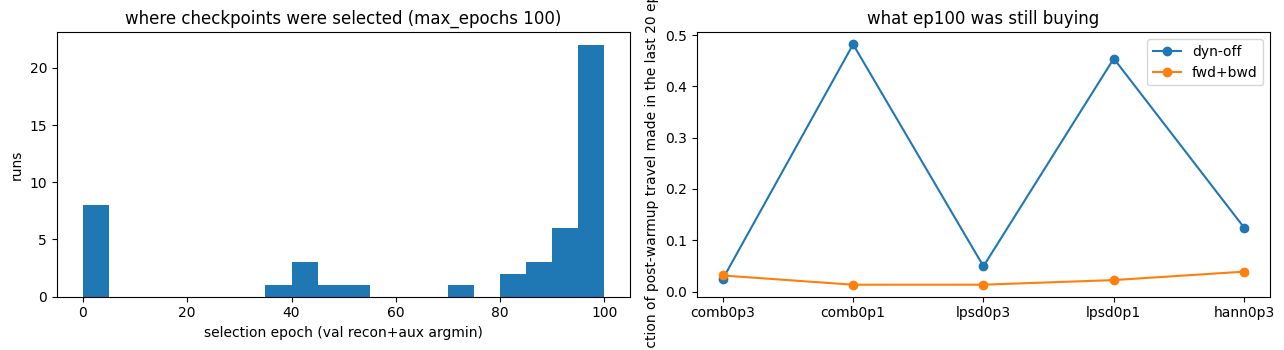

best_epoch_med  improving  n  tail_frac
recipe  arm                                          
comb0p1 fbwd            95.5          4  4      0.013
        off              0.0          0  4      0.482
comb0p3 fbwd            94.5          6  6      0.031
        off             93.5          6  6      0.025
hann0p3 fbwd            95.5          6  6      0.039
        off             71.0          6  6      0.125
lpsd0p1 fbwd            81.5          2  4      0.022
        off              0.0          0  4      0.454
lpsd0p3 fbwd            97.0          4  4      0.013
        off             92.5          4  4      0.049

In [5]:
# A2 - convergence, and how much of the curve's travel still happened in the final 20 epochs
sel = []
for recipe, arm, seed in ALL_RUNS:
    cur = load_curve(cell_name(recipe, arm), seed)
    metric = cur["val/monitor_recon_aux"].to_numpy()
    best_ep = int(cur.loc[cur["val/monitor_recon_aux"].idxmin(), "epoch"])
    last_ep = int(cur["epoch"].max())
    if (recipe, arm, seed) in FULL_CURVE:
        post = cur[cur["epoch"] >= 10]  # beta warmup ends at 10; the transient before it is not "travel"
        travel_total = float(post["val/monitor_recon_aux"].iloc[0] - metric.min())
        travel_tail = float(post[post["epoch"] <= last_ep - 20]["val/monitor_recon_aux"].min() - metric.min())
        tail_frac = travel_tail / travel_total
    else:
        tail_frac = np.nan  # a lost prefix has no epoch-10 anchor, so total travel is unmeasurable
    sel.append({"recipe": recipe, "arm": arm, "seed": seed, "best_epoch": best_ep,
                "improving": best_ep >= last_ep - 10,
                "slope_last20": np.polyfit(cur["epoch"].to_numpy()[-20:], metric[-20:], 1)[0],
                "tail_travel_frac": tail_frac})
sel = pd.DataFrame(sel)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].hist(sel["best_epoch"], bins=np.arange(0, 105, 5))
axes[0].set_xlabel("selection epoch (val recon+aux argmin)"); axes[0].set_ylabel("runs")
axes[0].set_title("where checkpoints were selected (max_epochs 100)")
for arm in ARMS:
    sub = sel[sel["arm"] == arm].groupby("recipe")["tail_travel_frac"].mean().reindex(RECIPES)
    axes[1].plot(sub.index, sub.values, "o-", label=ARMS[arm])
axes[1].set_ylabel("fraction of post-warmup travel made in the last 20 epochs")
axes[1].legend(); axes[1].set_title("what ep100 was still buying")
plt.tight_layout(); plt.show()
sel.groupby(["recipe", "arm"]).agg(best_epoch_med=("best_epoch", "median"),
                                   improving=("improving", "sum"), n=("seed", "count"),
                                   tail_frac=("tail_travel_frac", "mean")).round(3)

#### Plain-English read of A2

**Truncation persists, and it is now quantified rather than just flagged.** Twenty-two of the 26 fwd_bwd
runs still select within their last ten epochs, so absolute scores remain floors, exactly the exp05/exp06
A2 pattern. The new column says what that costs: the fwd_bwd arms made only 1.3-3.9% of their
post-warmup travel in the final 20 epochs, so the curve is genuinely flat there and the truncation is
cosmetic for the paired comparisons every gate is built from. The two dyn-off cells reading 0.45-0.48 with
a median selection epoch of 0 are not slow converging runs; they are the selection pathology A6 isolates.

In [6]:
# A3 - NaN / divergence check across the core logged metrics
core = ["train/recon", "train/dyn", "train/aux", "val/recon", "val/aux",
        "val/monitor_recon_aux", "val/n_active_units", "val/mu_var"]
nan_counts = {}
for col in core:
    total = 0
    for recipe, arm, seed in ALL_RUNS:
        total += int(load_curve(cell_name(recipe, arm), seed)[col].isna().sum())
    nan_counts[col] = total
assert sum(nan_counts.values()) == 0, nan_counts
print("no NaN in any logged metric across 48 runs")

no NaN in any logged metric across 48 runs


In [7]:
# A4 - G-dose: did lambda buy the dynamics contribution the drift-corrected pilots calibrated for?
rows = []
for recipe in RECIPES:
    for seed in seeds_of(recipe):
        cur = load_curve(cell_name(recipe, "fbwd"), seed)
        tail = cur.tail(10)  # last-10-epoch read, the manifest's G-dose definition
        rows.append({"recipe": recipe, "seed": seed, "lambda": LAMBDA[recipe],
                     "dose": LAMBDA[recipe] * tail["train/dyn"].mean() / tail["train/recon"].mean()})
dose = pd.DataFrame(rows)
dose["pass"] = dose["dose"].between(*DOSE_BAND)

published = dose_csv.rename(columns={"cell": "cell_name"})
published["recipe"] = published["cell_name"].str.replace("exp07_", "").str.replace("_fbwd", "")
check = dose.merge(published[["recipe", "seed", "dose_steady"]], on=["recipe", "seed"], how="inner")
assert np.allclose(check["dose"], check["dose_steady"], atol=2e-3), "dose recomputation drifted from exp07_dose_gate.csv"
print(f"dose recomputation matches exp07_dose_gate.csv on its {len(check)} rows; all 30 fbwd runs pass: {dose['pass'].all()}")
dose.groupby(["recipe", "lambda"]).agg(dose_mean=("dose", "mean"), dose_min=("dose", "min"),
                                       dose_max=("dose", "max"), n=("seed", "count")).round(3)

dose recomputation matches exp07_dose_gate.csv on its 20 rows; all 30 fbwd runs pass: True


,,dose_mean,dose_min,dose_max,n
recipe,lambda,,,,
comb0p1,60,0.779,0.750,0.802,4
comb0p3,60,0.864,0.817,0.972,6
hann0p3,60,0.954,0.906,0.998,6
lpsd0p1,75,1.053,1.027,1.076,4
lpsd0p3,60,0.939,0.848,1.017,4


#### Plain-English read of A4

**G-dose passes on all 30 fwd_bwd runs**, extension seeds included, and the recomputation reproduces
`exp07_dose_gate.csv` on its 20 published rows. Cell means run 0.78 to 1.05 against a target of 1.0 and a
gate of [0.6, 1.4], so the drift-corrected calibration rule (read the pilot at epoch 40, scale by the
measured 0.74 drift to epoch 100) landed everywhere. `lpsd0p1` at lambda 75 is the highest at 1.05, which
is the intended overshoot from rounding its dial down from 78 for sublinearity.

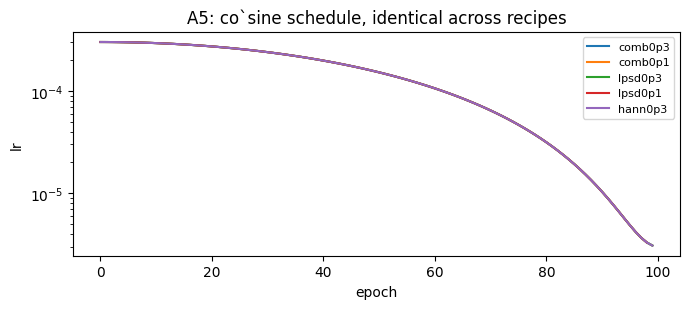

In [8]:
# A5 - cosine LR schedule sanity: starts at 3e-4 and decays along the cosine
plt.figure(figsize=(7, 3.2))
for recipe in RECIPES:
    cur = load_curve(cell_name(recipe, "fbwd"), 0)
    plt.plot(cur["epoch"], cur["lr"], label=recipe)
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("lr")
plt.legend(fontsize=8); plt.title("A5: co`sine schedule, identical across recipes")
plt.tight_layout(); plt.show()

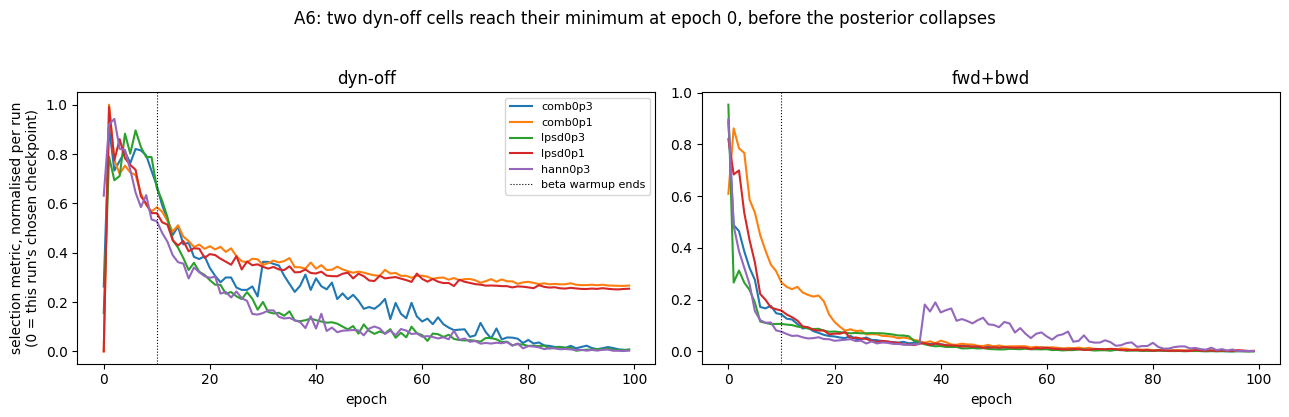

selected_ep0  n  n_active_at_sel  recon_cost  aux_credit
recipe  arm                                                           
comb0p1 fbwd             0  4            5.250      -0.463       0.169
        off              4  4          128.000       0.109       0.006
comb0p3 fbwd             0  6            8.167     -10.114       3.206
        off              0  6            5.167       0.001       0.136
hann0p3 fbwd             0  6            5.833      -5.982       3.873
        off              0  6            5.000      -0.121       0.182
lpsd0p1 fbwd             0  4            5.500      -2.420       0.271
        off              4  4          128.000       0.097      -0.006
lpsd0p3 fbwd             0  4           18.250     -13.504       1.736
        off              0  4            5.500       0.012       0.077

In [9]:
# A6 - which checkpoint did each cell actually select? (a pathology A2 exposed)
# The selection metric is recon + w*aux at fixed weight. At w=0.3 the aux term improves enough over
# training to dominate; at w=0.1 it cannot offset the reconstruction penalty the KL warmup imposes,
# because epoch 0 is a pre-collapse near-deterministic autoencoder that reconstructs BETTER than the
# converged model. Where that happens, best_recon_aux.pt is the epoch-0 checkpoint.
rows = []
for recipe, arm, seed in ALL_RUNS:
    cur = load_curve(cell_name(recipe, arm), seed)
    best_i = cur["val/monitor_recon_aux"].idxmin()
    weight = float(recipe[-3:].replace("0p", "0."))
    rows.append({"recipe": recipe, "arm": arm, "seed": seed,
                 "best_epoch": int(cur.loc[best_i, "epoch"]),
                 "n_active_at_sel": float(cur.loc[best_i, "val/n_active_units"]),
                 "recon_cost": float(cur["val/recon"].iloc[-1] - cur["val/recon"].iloc[0]),
                 "aux_credit": weight * float(cur["val/aux"].iloc[0] - cur["val/aux"].iloc[-1])})
picked = pd.DataFrame(rows)
picked["selected_ep0"] = picked["best_epoch"] == 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, arm in zip(axes, ["off", "fbwd"]):
    for recipe in RECIPES:
        stack = []
        for seed in seeds_of(recipe):
            cur = load_curve(cell_name(recipe, arm), seed).set_index("epoch")["val/monitor_recon_aux"]
            stack.append((cur - cur.min()) / (cur.max() - cur.min()))  # per-run normalisation: the
        merged = pd.concat(stack, axis=1)                              # metric's scale is weight-dependent
        ax.plot(merged.index, merged.mean(axis=1), label=recipe)
    ax.axvline(10, color="k", ls=":", lw=0.8, label="beta warmup ends")
    ax.set_xlabel("epoch"); ax.set_title(ARMS[arm])
axes[0].set_ylabel("selection metric, normalised per run\n(0 = this run's chosen checkpoint)")
axes[0].legend(fontsize=8)
fig.suptitle("A6: two dyn-off cells reach their minimum at epoch 0, before the posterior collapses", y=1.03)
plt.tight_layout(); plt.show()
picked.groupby(["recipe", "arm"]).agg(selected_ep0=("selected_ep0", "sum"), n=("seed", "count"),
                                      n_active_at_sel=("n_active_at_sel", "mean"),
                                      recon_cost=("recon_cost", "mean"),
                                      aux_credit=("aux_credit", "mean")).round(3)

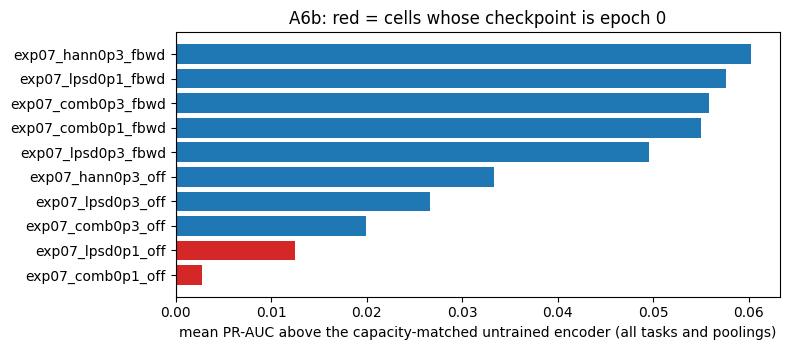

cell
exp07_comb0p1_off     0.003
exp07_lpsd0p1_off     0.012
exp07_comb0p3_off     0.020
exp07_lpsd0p3_off     0.027
exp07_hann0p3_off     0.033
exp07_lpsd0p3_fbwd    0.050
exp07_comb0p1_fbwd    0.055
exp07_comb0p3_fbwd    0.056
exp07_lpsd0p1_fbwd    0.058
exp07_hann0p3_fbwd    0.060
Name: gap, dtype: float64

In [10]:
# A6b - what those checkpoints score: the affected cells sit at the untrained floor
unt = gap4[gap4["arm"] == "untrained"].set_index(["pooling", "task"])["pr_auc"]
rows = []
for cell in sorted(gap4[gap4["arm"] == "trained"]["cell"].unique()):
    for pooling in ["mean", "mean_resid", "mean_std"]:
        for task in TASKS:
            score = gap4[(gap4["cell"] == cell) & (gap4["pooling"] == pooling)
                         & (gap4["task"] == task)]["pr_auc"].mean()
            rows.append({"cell": cell, "gap": score - unt.loc[(pooling, task)]})
floor = pd.DataFrame(rows).groupby("cell")["gap"].mean().sort_values()

ep0_cells = set()
for _, r in picked[picked["selected_ep0"]].iterrows():
    ep0_cells.add(cell_name(r["recipe"], r["arm"]))
plt.figure(figsize=(8, 3.6))
colors = []
for c in floor.index:
    if c in ep0_cells:
        colors.append("tab:red")
    else:
        colors.append("tab:blue")
plt.barh(floor.index, floor.values, color=colors)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("mean PR-AUC above the capacity-matched untrained encoder (all tasks and poolings)")
plt.title("A6b: red = cells whose checkpoint is epoch 0")
plt.tight_layout(); plt.show()
floor.round(3)

#### Plain-English read of A6

**Two of the ten cells never selected a trained checkpoint.** `comb0p1_off` and `lpsd0p1_off` pick epoch 0
on all four seeds, with 128 active units and `mu_var` around 22 at the selected step. The cause is the
selection metric: `best_recon_aux` minimises `recon + w*aux`, and at weight 0.1 that expression is
genuinely smallest before the KL warmup collapses the posterior. The arithmetic is in the table: those two
cells pay a reconstruction penalty of +0.109 and +0.097 over the run while earning a weighted aux credit
of +0.006 and -0.006 (lpsd's aux term actually gets worse), so epoch 0 wins on every seed. At weight 0.3
the credit is +0.077 to +0.183 against a penalty of about 0.01 or none at all, which is why every 0.3 cell
selects between epochs 40 and 99. The left panel shows it directly: the two 0.1 dyn-off curves never
return to their epoch-0 value, while every other cell reaches its minimum late.

A6b confirms the consequence. Those two cells average +0.003 and +0.012 PR-AUC over the capacity-matched
untrained encoder, the two lowest of all ten, against +0.020 to +0.033 for the properly selected dyn-off
cells; `comb0p1_off` scores exactly the untrained value on pulsating. Nothing in the results tables
distinguishes them from a trained run, which is what makes this worth recording: **active units at the
selected checkpoint is the cheap detector**, since 128 of 128 means the checkpoint predates the collapse.

**What this does and does not touch.** Nothing in the frozen recipe or any headline gate: `hann0p3` and
`comb0p3` select epochs 40-97 on both arms, so G-noregress, G-C1, G-dose and the 6-seed edge numbers are
untouched. What it does qualify is any claim that leans on the weight-0.1 **dyn-off** arms, specifically
the README's "every recipe's fwd_bwd arm beats its off arm on eb": for `comb0p1` and `lpsd0p1` that
comparison is against a near-untrained encoder, so it is not evidence about dynamics for those two
recipes. The dyn-on half of P2 (edge severity 34.4 -> 18.2 for comb, 41.5 -> 5.5 for lpsd) is unaffected,
as both fwd_bwd cells select late. The same caveat applies to the dyn-off column of B3 and to the
weight-0.1 off rows of E3.

## B. Pre-registered gates, recomputed
Every exp07 verdict is re-derived here from the raw gap CSVs and asserted against the numbers publishedin `exp07_aux_README.md`. The gate arms follow the manifest: **G-noregress** is the winner minus the`comb0p3` baseline, paired over 6 seeds on the fwd+bwd arm; **G-C1** is the winner's fwd+bwd minus itsown dyn-off arm on amplitude-residualized pooling. B3 and B4 then read the factorization at its own4-seed footing.

In [11]:
# B1 - recompute G-noregress and G-C1 from exp07_aux_gap_6seed.csv, assert against the README
POOLINGS = ["mean", "mean_resid", "mean_std"]
rows = []
for pooling in POOLINGS:
    for task in TASKS:
        w = seed_matrix(gap6, cell_name(WINNER, "fbwd"), pooling, task, SEEDS6)
        b = seed_matrix(gap6, cell_name(BASELINE, "fbwd"), pooling, task, SEEDS6)
        mean, se, passed = paired(w - b)
        rows.append({"gate": "G-noregress", "pooling": pooling, "task": task,
                     "mean": mean, "se": se, "better_2se": passed, "regress_2se": mean < -2 * se})
        off = seed_matrix(gap6, cell_name(WINNER, "off"), pooling, task, SEEDS6)
        mean, se, passed = paired(w - off)
        rows.append({"gate": "G-C1", "pooling": pooling, "task": task,
                     "mean": mean, "se": se, "better_2se": passed, "regress_2se": mean < -2 * se})
gates = pd.DataFrame(rows)

published_claims = [("G-noregress", "mean", "pulsating", 0.018, 0.009),
                    ("G-noregress", "mean_std", "pulsating", 0.025, 0.012),
                    ("G-noregress", "mean_resid", "pulsating", 0.011, 0.013),
                    ("G-C1", "mean_resid", "eb", 0.080, 0.007),
                    ("G-C1", "mean_resid", "rotation", 0.046, 0.013)]
mismatch = []
for gate, pooling, task, claim_mean, claim_se in published_claims:
    got = gates[(gates["gate"] == gate) & (gates["pooling"] == pooling) & (gates["task"] == task)].iloc[0]
    if abs(got["mean"] - claim_mean) > 0.001 or abs(got["se"] - claim_se) > 0.001:
        mismatch.append((gate, pooling, task, claim_mean, claim_se, got["mean"], got["se"]))
assert not mismatch, mismatch
worst = gates[gates["gate"] == "G-noregress"]["mean"].min()
print(f"all 5 published gate numbers reproduce to 0.001 | no regression: {not gates[gates['gate'] == 'G-noregress']['regress_2se'].any()} "
      f"| largest negative paired delta {worst}")
gates.pivot_table(index=["gate", "pooling"], columns="task", values="mean").round(3)

all 5 published gate numbers reproduce to 0.001 | no regression: True | largest negative paired delta -0.008952471736495346


task                       eb  pulsating  rotation  transit
gate        pooling                                        
G-C1        mean        0.033     -0.006     0.023    0.009
            mean_resid  0.080      0.001     0.046    0.020
            mean_std    0.031      0.007     0.040    0.039
G-noregress mean       -0.009      0.018    -0.004   -0.002
            mean_resid -0.007      0.011    -0.009    0.003
            mean_std    0.009      0.025     0.015   -0.009

#### Plain-English read of B1

**Every published gate number reproduces from the raw CSVs to within 0.001**, and the recomputation is
independent of the script that wrote the README. G-noregress holds: over 6 seeds `hann0p3` regresses on no
task under any pooling, the largest negative paired delta being -0.009, and it is better than the baseline
by more than 2*SE on pulsating under both `mean` (+0.018) and `mean_std` (+0.025). G-C1 holds in the
winner: fwd_bwd beats its own dyn-off arm by +0.080 on eb and +0.046 on rotation under the gate pooling.
The pulsating advantage is visibly aux-driven rather than dynamics-driven, since the same G-C1 column
gives pulsating +0.001.

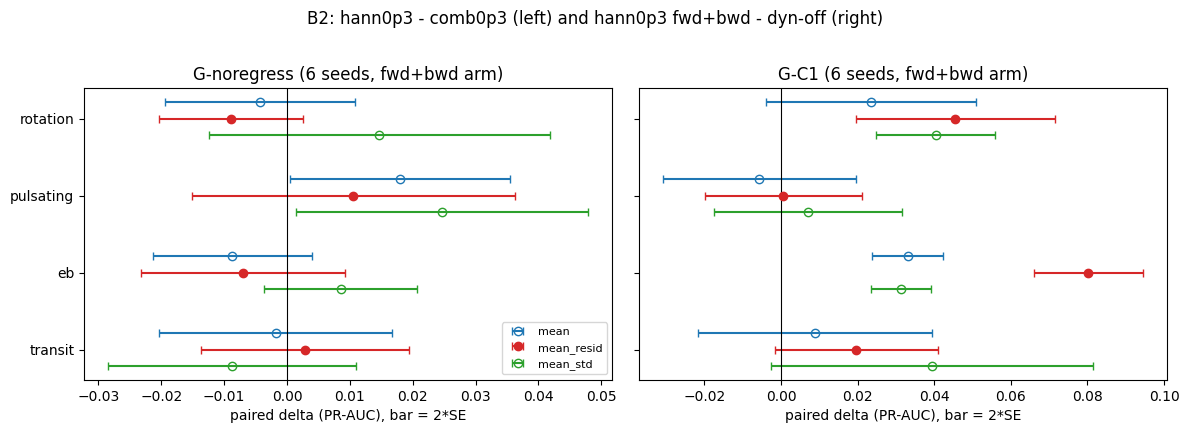

In [12]:
# B2 - the gate forest: winner vs baseline (G-noregress) and winner fwd+bwd vs its own off arm (G-C1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
offsets = {"mean": 0.22, "mean_resid": 0.0, "mean_std": -0.22}
colors = {"mean": "tab:blue", "mean_resid": "tab:red", "mean_std": "tab:green"}
for ax, gate in zip(axes, ["G-noregress", "G-C1"]):
    for pooling, off in offsets.items():
        sub = gates[(gates["gate"] == gate) & (gates["pooling"] == pooling)].set_index("task").reindex(TASKS)
        y = np.arange(len(TASKS)) + off
        filled = "full" if pooling == "mean_resid" else "none"
        ax.errorbar(sub["mean"], y, xerr=2 * sub["se"], fmt="o", fillstyle=filled,
                    color=colors[pooling], capsize=3, label=pooling)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
    ax.set_xlabel("paired delta (PR-AUC), bar = 2*SE")
    ax.set_title(f"{gate} (6 seeds, fwd+bwd arm)")
axes[0].legend(fontsize=8)
fig.suptitle("B2: hann0p3 - comb0p3 (left) and hann0p3 fwd+bwd - dyn-off (right)", y=1.02)
plt.tight_layout(); plt.show()

#### Plain-English read of B2

The two panels separate what the taper bought from what the dynamics term bought, and they barely overlap.
Left (G-noregress): all four tasks sit on or above zero, with pulsating the only interval clear of it; the
taper is a probe-neutral change with one gain. Right (G-C1): eb and rotation are clear of zero on the gate
pooling while pulsating sits exactly on it. So `hann0p3`'s pulsating lift comes from the auxiliary term and
its eb/rotation strength comes from the dynamics term, and neither substitutes for the other.

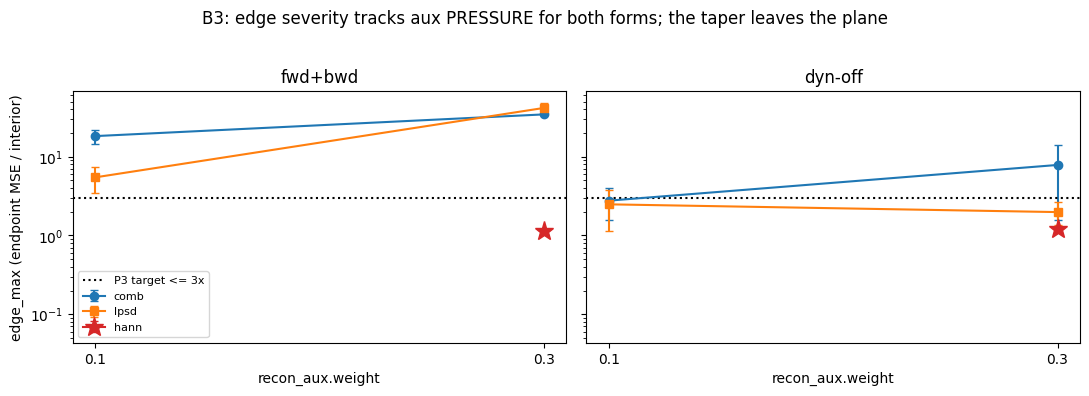

arm,fbwd,off
recipe,,
comb0p1,18.22,2.76
comb0p3,34.36,7.84
hann0p3,1.15,1.20
lpsd0p1,5.45,2.48
lpsd0p3,41.49,1.98


In [13]:
# B3 - the pressure-vs-form grid: edge severity against aux weight and aux form, 4-seed footing
er = edge_ratios.copy()
er["recipe"] = er["cell"].str.replace("exp07_", "").str.rsplit("_", n=1).str[0]
er["arm"] = er["cell"].str.rsplit("_", n=1).str[1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, arm in zip(axes, ["fbwd", "off"]):
    for form, marker in [("comb", "o"), ("lpsd", "s")]:
        xs, ys, errs = [], [], []
        for weight in ["0p1", "0p3"]:
            sub = er[(er["recipe"] == form + weight) & (er["arm"] == arm)]["edge_max"]
            xs.append(float(weight.replace("0p", "0.")))
            ys.append(sub.mean()); errs.append(sub.std(ddof=1) / np.sqrt(len(sub)))
        ax.errorbar(xs, ys, yerr=errs, marker=marker, capsize=3, label=form)
    hann = er[(er["recipe"] == "hann0p3") & (er["arm"] == arm)]["edge_max"]
    ax.errorbar([0.3], [hann.mean()], yerr=[hann.std(ddof=1) / np.sqrt(len(hann))], marker="*",
                markersize=14, color="tab:red", capsize=3, label="hann")
    ax.axhline(3, color="k", ls=":", label="P3 target <= 3x")
    ax.set_yscale("log"); ax.set_xticks([0.1, 0.3]); ax.set_xlabel("recon_aux.weight")
    ax.set_title(ARMS[arm])
axes[0].set_ylabel("edge_max (endpoint MSE / interior)"); axes[0].legend(fontsize=8)
fig.suptitle("B3: edge severity tracks aux PRESSURE for both forms; the taper leaves the plane", y=1.03)
plt.tight_layout(); plt.show()
er.pivot_table(index="recipe", columns="arm", values="edge_max").round(2)

#### Plain-English read of B3

**Severity tracks pressure, not form.** On the dynamics-on arm both aux forms fall steeply as the weight
drops from 0.3 to 0.1 (combined 34.4 -> 18.2, log_psd 41.5 -> 5.5), which is P2 confirmed and P4 resolved:
`lpsd0p3` spikes at 41.5x, so removing `hf_time` confers no immunity and the historical "log_psd is immune"
was its 0.1 weight all along. No untapered configuration combines full aux pressure with a clean edge. The
Hann tile leaves the plane entirely at 1.15x on the dyn-on arm and 1.20x on dyn-off, with a seed SE of 0.01
against 0.69-6.79 for every untapered cell. The dyn-off column at weight 0.1 must be read with A6 in hand:
those two cells are epoch-0 checkpoints, so their low edge ratios are not a trained-model property.

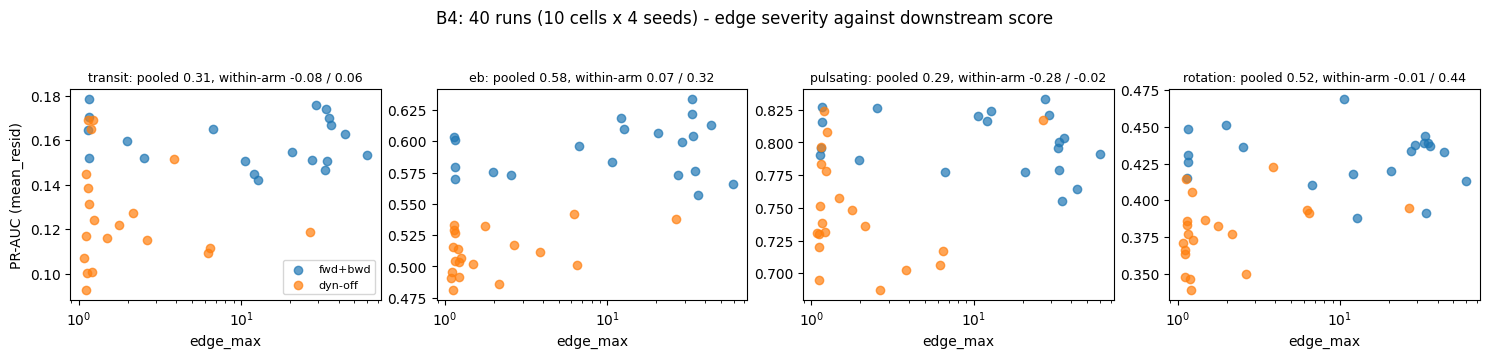

,task,rho_pooled,rho_fbwd,rho_off
0,transit,0.311,-0.077,0.063
1,eb,0.579,0.072,0.319
2,pulsating,0.292,-0.283,-0.023
3,rotation,0.522,-0.014,0.442


In [14]:
# B4 - did the edge defect ever cost anything downstream? edge severity vs probe score, all 10 cells
# Pooling the arms would answer the wrong question: turning the dynamics term on raises BOTH the edge
# ratio and the probe score, so a pooled correlation measures the dyn axis. The rho that speaks to the
# edge is the within-arm one.
from scipy.stats import spearmanr

joined = gap4[(gap4["pooling"] == "mean_resid") & (gap4["arm"] == "trained")].merge(
    edge_ratios[["cell", "seed", "edge_max"]], on=["cell", "seed"], how="inner")
joined["dyn"] = np.where(joined["cell"].str.endswith("fbwd"), "fbwd", "off")

rows = []
fig, axes = plt.subplots(1, len(TASKS), figsize=(15, 3.4), sharex=True)
for ax, task in zip(axes, TASKS):
    sub = joined[joined["task"] == task]
    pooled_rho, _ = spearmanr(sub["edge_max"], sub["pr_auc"])
    within = {}
    for dyn, grp in sub.groupby("dyn"):
        rho, p = spearmanr(grp["edge_max"], grp["pr_auc"])
        within[dyn] = rho
        ax.scatter(grp["edge_max"], grp["pr_auc"], alpha=0.7, label=ARMS[dyn])
    rows.append({"task": task, "rho_pooled": pooled_rho, **{f"rho_{k}": v for k, v in within.items()}})
    ax.set_xscale("log"); ax.set_xlabel("edge_max")
    ax.set_title(f"{task}: pooled {round(pooled_rho, 2)}, within-arm "
                 f"{round(within['fbwd'], 2)} / {round(within['off'], 2)}", fontsize=9)
axes[0].set_ylabel("PR-AUC (mean_resid)"); axes[0].legend(fontsize=8)
fig.suptitle("B4: 40 runs (10 cells x 4 seeds) - edge severity against downstream score", y=1.04)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).round(3)

#### Plain-English read of B4

**The edge defect never showed up downstream, and the pooled correlation that appears to say otherwise is
an artifact of the dynamics axis.** Pooled over all 40 runs, edge severity looks strongly *beneficial*
(eb rho +0.58, rotation +0.52) because turning the dynamics term on raises both the edge ratio and the
probe score. Within an arm the relation collapses and changes sign by task and arm (eb +0.07 / +0.32,
pulsating -0.28 / -0.02, rotation -0.01 / +0.44). The honest reading is that the edge artifact was
cosmetic for these probes: the Hann fix was worth making because the untapered periodogram was the
nonstandard choice and the decoder was demonstrably exploiting it, not because it was costing score. The
probe-facing case for `hann0p3` rests on G-noregress, not on the edge ratio.

## C. The edge mechanism, and what the taper left behind
Pre-check C1 established the spike is not boundary blur but an antisymmetric dipole whose amplitude istuned to a log-PSD minimum: the decoder was buying spectral power with an endpoint impulse, and theuntapered rectangular FFT is what made that purchase profitable. The Hann cell removes the incentive byconstruction. These panels ask what is left: whether the residual 1.16x is systematic or noise, andwhether the purchase is really unavailable rather than merely unused.

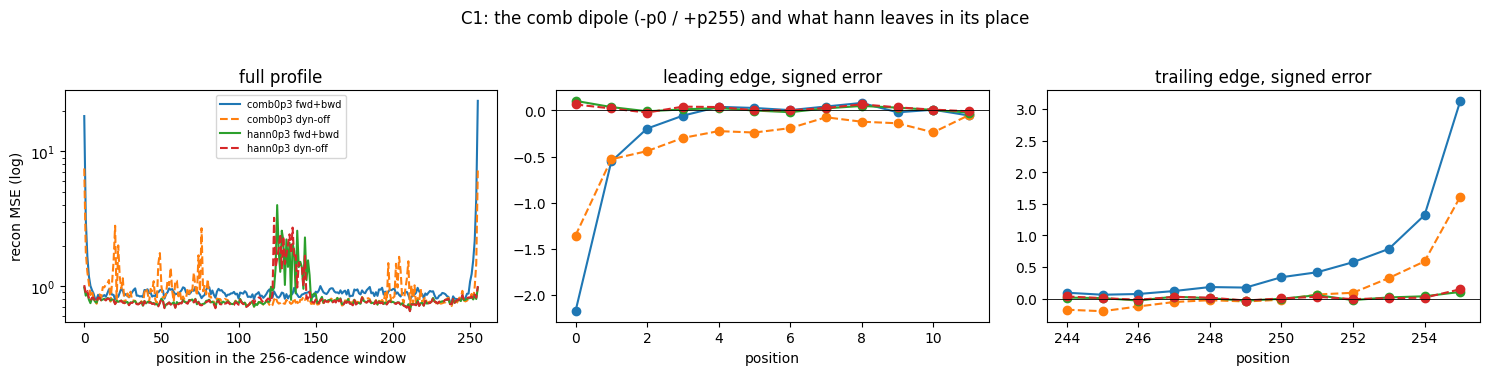

pos             0      1      2      254    255
recipe  arm                                    
comb0p3 fbwd -2.177 -0.553 -0.197  1.320  3.130
        off  -1.356 -0.530 -0.441  0.588  1.614
hann0p3 fbwd  0.103  0.036 -0.010  0.036  0.105
        off   0.065  0.021 -0.024  0.014  0.147

In [15]:
# C1 - the signed per-position error profile, both arms, winner against baseline (6 seeds)
prof = edge_profile.copy()
prof["recipe"] = prof["cell"].str.replace("exp07_", "").str.rsplit("_", n=1).str[0]
prof["arm"] = prof["cell"].str.rsplit("_", n=1).str[1]
by_pos = prof.groupby(["recipe", "arm", "pos"])[["signed_err", "mse"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for recipe in EXT_RECIPES:
    for arm, style in [("fbwd", "-"), ("off", "--")]:
        sub = by_pos[(by_pos["recipe"] == recipe) & (by_pos["arm"] == arm)]
        label = f"{recipe} {ARMS[arm]}"
        axes[0].semilogy(sub["pos"], sub["mse"], style, label=label)
        axes[1].plot(sub["pos"][:12], sub["signed_err"][:12], style, marker="o", label=label)
        axes[2].plot(sub["pos"][-12:], sub["signed_err"][-12:], style, marker="o", label=label)
axes[0].set_xlabel("position in the 256-cadence window"); axes[0].set_ylabel("recon MSE (log)")
axes[0].set_title("full profile"); axes[0].legend(fontsize=7)
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("leading edge, signed error")
axes[2].axhline(0, color="k", lw=0.6); axes[2].set_title("trailing edge, signed error")
for ax in axes[1:]:
    ax.set_xlabel("position")
fig.suptitle("C1: the comb dipole (-p0 / +p255) and what hann leaves in its place", y=1.03)
plt.tight_layout(); plt.show()
by_pos[by_pos["pos"].isin([0, 1, 2, 254, 255])].pivot_table(
    index=["recipe", "arm"], columns="pos", values="signed_err").round(3)

#### Plain-English read of C1

The dipole is the whole defect. `comb0p3_fbwd` reads -2.18 at p0 and +3.13 at p255 with the interior at
zero, reproducing pre-check C1's antisymmetric signature and its finding that the trailing edge is the
worse end; the dyn-off arm shows the same shape at roughly half amplitude, so dynamics amplifies an
incentive that is already present without it. `hann0p3` reads +0.10 at p0 and +0.11 at p255 on the same
scale, a factor of 20-30 smaller and, crucially, the same sign at both ends.

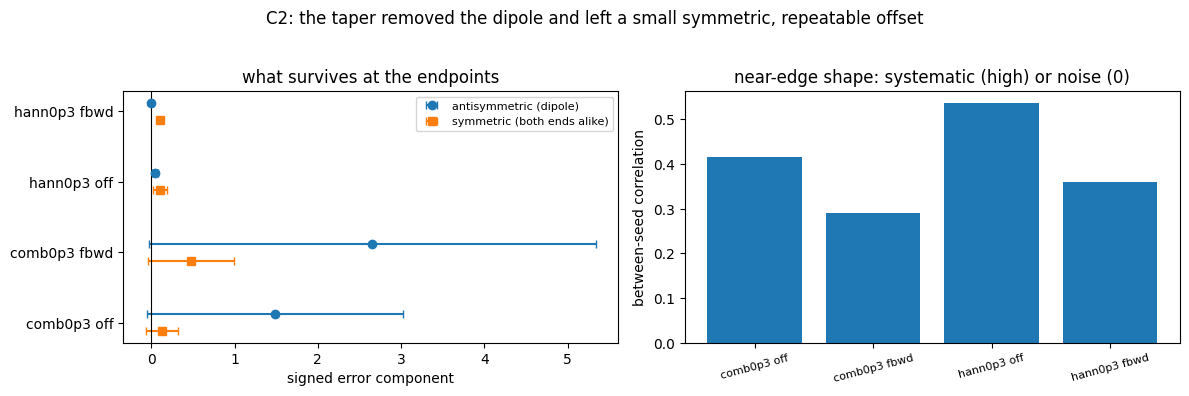

,recipe,arm,antisym,antisym_se,sym,sym_se,near_edge_excess,seed_repeatability
0,comb0p3,off,1.485,0.770,0.129,0.098,2.069,0.416
1,comb0p3,fbwd,2.653,1.343,0.477,0.256,5.104,0.290
2,hann0p3,off,0.041,0.018,0.106,0.041,1.078,0.536
3,hann0p3,fbwd,0.001,0.011,0.104,0.010,1.032,0.361


In [16]:
# C2 - is hann's residual edge structure systematic, and is it still a dipole?
# The obvious test, correlating the near-edge excess with the taper's own shape, is NOT identifiable:
# w_hann is a monotone function of distance from the boundary, so ANY edge-decaying excess correlates
# with it (comb, which has no taper at all, scores rho = -0.98). What IS identifiable is the SYMMETRY
# of the signed profile - a decoder buying spectral power produces the antisymmetric dipole pre-check
# C1 measured, while a taper shadow (aux pressure -> 0 at the endpoints, time-MSE alone left to
# constrain them) has no reason to prefer one end - and whether the shape repeats across seeds.
band = np.r_[1:9, 247:255]
rows = []
for recipe in EXT_RECIPES:
    for arm in ARMS:
        grp = prof[(prof["recipe"] == recipe) & (prof["arm"] == arm)]
        anti, sym = [], []
        for seed, g in grp.groupby("seed"):
            v = g.set_index("pos")["signed_err"]
            anti.append((v[255] - v[0]) / 2)   # dipole component: the C1 power-buying signature
            sym.append((v[255] + v[0]) / 2)    # common offset at both ends: what a taper shadow looks like
        repeat = []
        seeds = sorted(grp["seed"].unique())
        for i, si in enumerate(seeds):
            for sj in seeds[i + 1:]:
                a = grp[grp["seed"] == si].set_index("pos").loc[band, "signed_err"]
                b = grp[grp["seed"] == sj].set_index("pos").loc[band, "signed_err"]
                repeat.append(np.corrcoef(a, b)[0, 1])
        mse = grp.groupby("pos")["mse"].mean()
        rows.append({"recipe": recipe, "arm": arm,
                     "antisym": np.mean(anti), "antisym_se": np.std(anti, ddof=1) / np.sqrt(len(anti)),
                     "sym": np.mean(sym), "sym_se": np.std(sym, ddof=1) / np.sqrt(len(sym)),
                     "near_edge_excess": mse.loc[band].max() / mse.loc[16:239].mean(),
                     "seed_repeatability": np.mean(repeat)})
shadow = pd.DataFrame(rows)
shadow["label"] = shadow["recipe"] + " " + shadow["arm"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
y = np.arange(len(shadow))
axes[0].errorbar(shadow["antisym"], y + 0.12, xerr=2 * shadow["antisym_se"], fmt="o", capsize=3,
                 label="antisymmetric (dipole)")
axes[0].errorbar(shadow["sym"], y - 0.12, xerr=2 * shadow["sym_se"], fmt="s", capsize=3,
                 label="symmetric (both ends alike)")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_yticks(y); axes[0].set_yticklabels(shadow["label"])
axes[0].set_xlabel("signed error component"); axes[0].legend(fontsize=8)
axes[0].set_title("what survives at the endpoints")
axes[1].bar(y, shadow["seed_repeatability"])
axes[1].set_xticks(y); axes[1].set_xticklabels(shadow["label"], fontsize=8, rotation=15)
axes[1].set_ylabel("between-seed correlation")
axes[1].set_title("near-edge shape: systematic (high) or noise (0)")
fig.suptitle("C2: the taper removed the dipole and left a small symmetric, repeatable offset", y=1.03)
plt.tight_layout(); plt.show()
shadow.drop(columns="label").round(3)

#### Plain-English read of C2

**The residual 1.15x is systematic, but it is not the old defect.** Decomposing the endpoint error into an
antisymmetric part (the dipole, the C1 power-buying signature) and a symmetric part (a common offset at
both ends) separates them: `comb0p3_fbwd` carries an antisymmetric component of 2.65 against a symmetric
0.48, while `hann0p3_fbwd` carries an antisymmetric component of 0.001 +/- 0.011 and a symmetric
0.104 +/- 0.010. The seed spread on comb's dipole is wide (+/- 1.34, so its own 2*SE bar touches zero: the
amplitude the decoder settles on varies a lot between seeds), which is why the decisive comparison is
hann's side of the plot rather than comb's - hann's antisymmetric component is pinned at zero with a
standard error two orders of magnitude smaller than comb's estimate, while its symmetric component is
comfortably clear of zero. The taper did not shrink the dipole, it abolished it, and what remains is a
small even-handed excess at both boundaries. The between-seed repeatability of the near-edge profile
(0.36 fwd_bwd, 0.54 dyn-off) says that remainder is a reproducible property of the objective and not seed
noise, which is consistent with a taper shadow: where the taper weight goes to zero the aux term exerts no
pressure and only time-MSE constrains the endpoint.

**A test we deliberately do not run.** Correlating the near-edge excess against the taper's own shape is
not identifiable, because `w_hann` is a monotone function of distance from the boundary and so any
edge-decaying excess reproduces it: `comb0p3_fbwd`, which trained with no taper at all, scores rho = -0.98
on that test. Symmetry and seed repeatability are the parts of the question the data can actually answer.

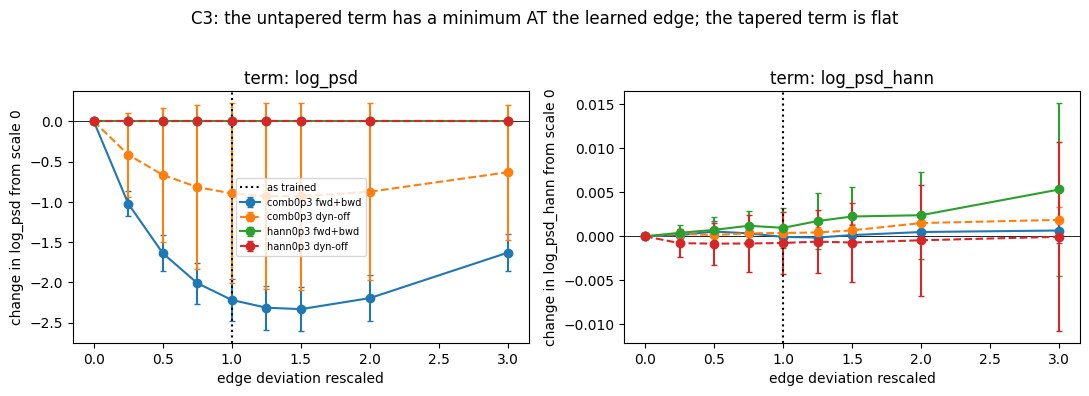

d_log_psd                 d_log_psd_hann                
scale              0.0     1.0     3.0            0.0     1.0     3.0
recipe  arm                                                          
comb0p3 fbwd       0.0 -2.2192 -1.6303            0.0 -0.0001  0.0007
        off        0.0 -0.8961 -0.6321            0.0  0.0004  0.0019
hann0p3 fbwd       0.0  0.0000  0.0000            0.0  0.0010  0.0053
        off        0.0  0.0000  0.0000            0.0 -0.0008 -0.0001

In [17]:
# C3 - unbuyability: rescale the model's own edge deviation and watch the term it was trained on
# The quantity is a WITHIN-RUN change, so the error bar must be the seed spread of that change, not of
# the absolute term: the absolute log-PSD differs by tens of nats between recipes and its spread would
# swamp a response of one nat.
sw = edge_sweep.copy()
sw["recipe"] = sw["cell"].str.replace("exp07_", "").str.rsplit("_", n=1).str[0]
sw["arm"] = sw["cell"].str.rsplit("_", n=1).str[1]
base = sw[sw["scale"] == 0.0].set_index(["cell", "seed"])
for term in ["log_psd", "log_psd_hann"]:
    sw[f"d_{term}"] = sw[term] - sw.set_index(["cell", "seed"]).index.map(base[term])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, term in zip(axes, ["log_psd", "log_psd_hann"]):
    for recipe in EXT_RECIPES:
        for arm, style in [("fbwd", "-"), ("off", "--")]:
            sub = sw[(sw["recipe"] == recipe) & (sw["arm"] == arm)].groupby("scale")[f"d_{term}"]
            stat = sub.agg(["mean", "sem"])
            ax.errorbar(stat.index, stat["mean"], yerr=2 * stat["sem"], fmt=style + "o",
                        capsize=2, label=f"{recipe} {ARMS[arm]}")
    ax.axvline(1.0, color="k", ls=":", label="as trained")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("edge deviation rescaled"); ax.set_ylabel(f"change in {term} from scale 0")
    ax.set_title(f"term: {term}")
axes[0].legend(fontsize=7)
fig.suptitle("C3: the untapered term has a minimum AT the learned edge; the tapered term is flat", y=1.03)
plt.tight_layout(); plt.show()
sw[sw["scale"].isin([0.0, 1.0, 3.0])].pivot_table(index=["recipe", "arm"], columns="scale",
                                                  values=["d_log_psd", "d_log_psd_hann"]).round(4)

#### Plain-English read of C3

**The incentive exists only in the untapered term, and the taper removes it exactly.** Rescaling
`comb0p3_fbwd`'s own edge deviation moves its untapered log-PSD from 4.29 with the edge extrapolated away
to a minimum of 2.07 at roughly the amplitude it actually learned, and back up to 2.66 by scale 3: the
learned edge sits in a valley, so the amplitude is tuned rather than incidental, which is the strong form
of the pre-check C1 claim. Evaluate the same reconstructions through a Hann taper and the response is flat
to four decimals (57.479 at every scale), and the `hann0p3` cell is flat in both columns because the term
it trained on already carries the taper. The fix is by construction, not empirical: a symmetric Hann window
is exactly zero at both endpoints, so the purchase is not merely unattractive, it is unavailable.

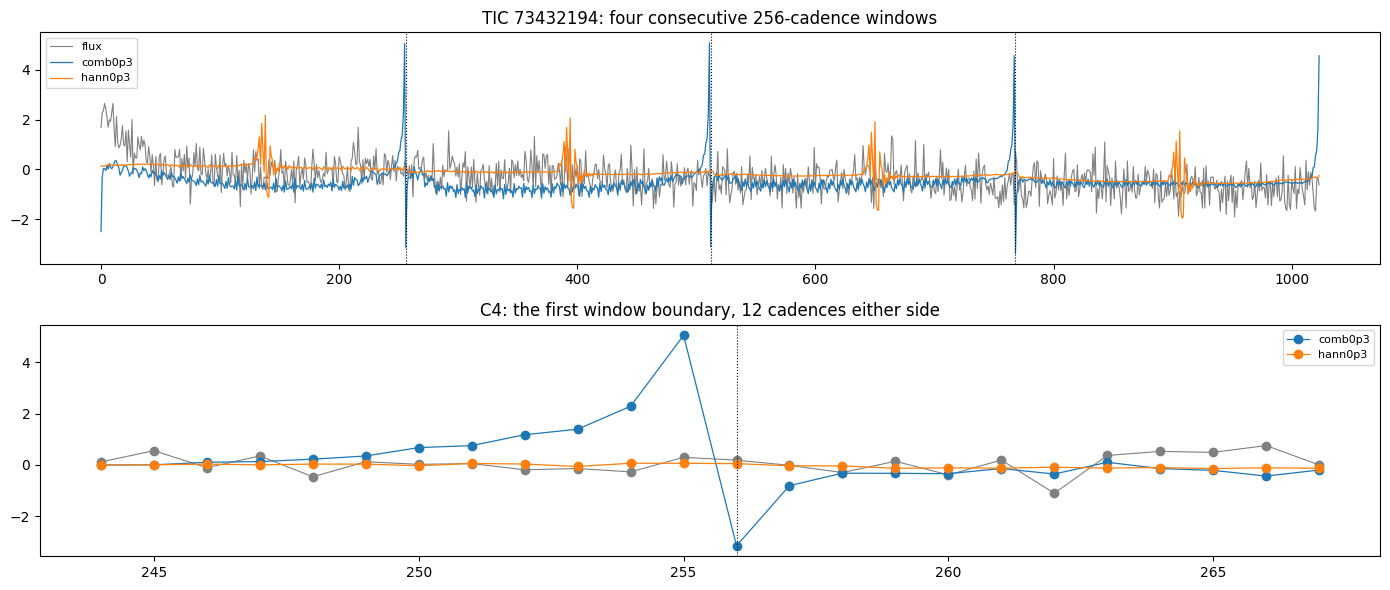

In [18]:
# C4 - the same star reconstructed by both recipes, with the window boundaries drawn
from swm.eval.skyline import load_first_segment_blocks

packed = EXPS / cell_name(WINNER, "fbwd") / "packed"
tics, blocks = load_first_segment_blocks(packed, "test", WINDOW)
rng = np.random.default_rng()               # fresh sample every re-run
# rng = np.random.default_rng(0)            # uncomment for a reproducible sample
pick = int(rng.integers(len(tics)))
block = blocks[pick][:4]                    # four consecutive windows of the same segment

panel = {}
for recipe in EXT_RECIPES:
    model, _ = load_model(cell_name(recipe, "fbwd"), PANEL_SEED)
    with torch.no_grad():
        x = torch.from_numpy(block).unsqueeze(-1).to(device)
        mu, _ = model.encoder(x)
        panel[recipe] = model.decoder(mu)[:, :, 0].cpu().numpy()
    del model
    if device == "cuda":
        torch.cuda.empty_cache()

flat_truth = block.reshape(-1)
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(flat_truth, color="0.5", lw=0.8, label="flux")
for recipe in EXT_RECIPES:
    axes[0].plot(panel[recipe].reshape(-1), lw=0.9, label=recipe)
for b in range(1, 4):
    axes[0].axvline(b * WINDOW, color="k", ls=":", lw=0.8)
axes[0].legend(fontsize=8); axes[0].set_title(f"TIC {tics[pick]}: four consecutive 256-cadence windows")

zoom = slice(WINDOW - 12, WINDOW + 12)
axes[1].plot(np.arange(zoom.start, zoom.stop), flat_truth[zoom], color="0.5", marker="o", lw=0.8)
for recipe in EXT_RECIPES:
    axes[1].plot(np.arange(zoom.start, zoom.stop), panel[recipe].reshape(-1)[zoom], marker="o", lw=0.9,
                 label=recipe)
axes[1].axvline(WINDOW, color="k", ls=":", lw=0.8)
axes[1].legend(fontsize=8); axes[1].set_title("C4: the first window boundary, 12 cadences either side")
plt.tight_layout(); plt.show()

#### Plain-English read of C4

The boundary zoom is the defect in flux space. Both reconstructions are smooth, low-passed versions of the
true light curve across the window interior, and they are hard to tell apart there. At the cadence either
side of the boundary the untapered model steps away from the data in opposite directions on the two sides,
which is the dipole of C1 seen one star at a time, while the tapered model crosses the boundary without a
visible discontinuity. Note the sample is redrawn on every re-run, so an individual star may show the
effect more or less clearly than the seed-averaged profile in C1.

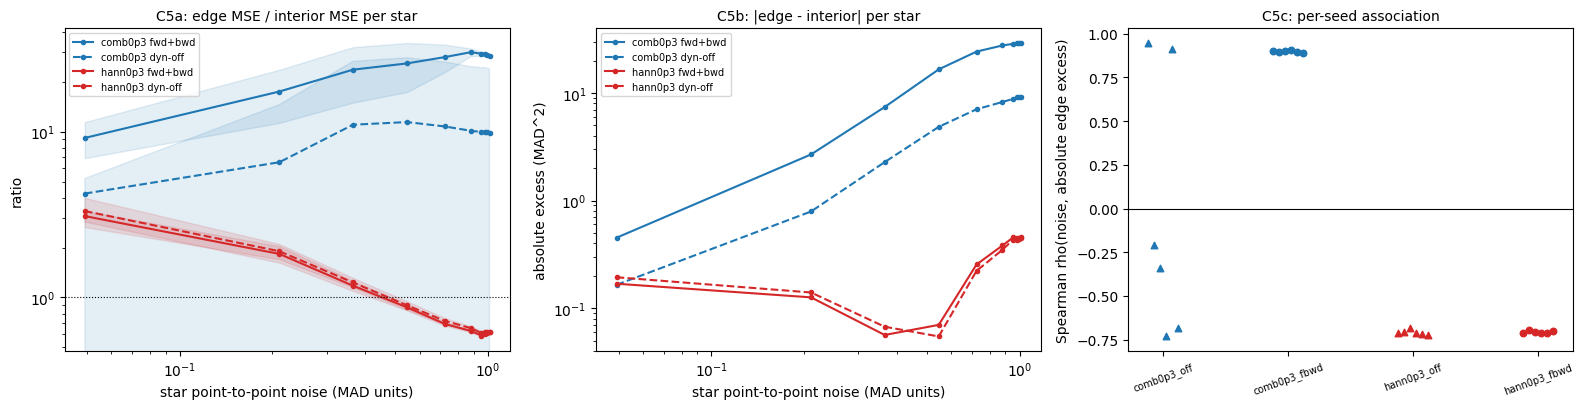

edge_ratio_median         edge_excess_median          \
                                mean     std               mean     std   
cell                                                                      
exp07_comb0p3_fbwd            28.204   1.803             25.879   0.506   
exp07_comb0p3_off              9.885  14.059              7.758  12.332   
exp07_hann0p3_fbwd             0.712   0.006             -0.281   0.007   
exp07_hann0p3_off              0.735   0.018             -0.257   0.016   

                   rho_noise_edge_ratio        rho_noise_edge_excess         \
                                   mean    std                  mean    std   
cell                                                                          
exp07_comb0p3_fbwd                0.390  0.247                 0.899  0.006   
exp07_comb0p3_off                -0.216  0.393                -0.017  0.761   
exp07_hann0p3_fbwd               -0.636  0.011                -0.706  0.009   
exp07_hann0p3_off                -0.646  0.013                -0.709  0.015   

                   ratio_quietest_decile        ratio_noisiest_decile          
                                    mean    std                  mean     std  
cell                                                                           
exp07_comb0p3_fbwd                 9.158  2.244                28.657   0.756  
exp07_comb0p3_off                  4.230  0.980                 9.838  14.067  
exp07_hann0p3_fbwd                 3.094  0.230                 0.615   0.004  
exp07_hann0p3_off                  3.318  0.661                 0.621   0.010

In [19]:
# C5 - the per-star version of the defect, and what drives it (artifact: analyze_exp07_edge_noise.py)
# edge_max is a ratio of means over a window sample. It cannot say whether a residual is spread over all
# stars or concentrated on a few, and the section-I panels suggested the latter, so this reduces the same
# measurement per STAR (median over all of its test windows) and regresses it on that star's own noise.
noise_stars = pd.read_csv(EXPS / "exp07_edge_noise_stars.csv")
noise_sum = pd.read_csv(EXPS / "exp07_edge_noise_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
styles = {(BASELINE, "fbwd"): ("tab:blue", "-"), (BASELINE, "off"): ("tab:blue", "--"),
          (WINNER, "fbwd"): ("tab:red", "-"), (WINNER, "off"): ("tab:red", "--")}
for (recipe, arm), (colour, ls) in styles.items():
    rows = noise_stars[noise_stars["cell"] == cell_name(recipe, arm)]
    decile = pd.qcut(rows["noise"], 10, labels=False, duplicates="drop").rename("decile")
    grid = rows.groupby([decile, "seed"])[["edge_ratio", "edge_excess", "noise"]].median().reset_index()
    curve = grid.groupby("decile")[["edge_ratio", "edge_excess", "noise"]].mean()
    spread = grid.groupby("decile")["edge_ratio"].std()
    label = f"{recipe} {ARMS[arm]}"
    axes[0].plot(curve["noise"], curve["edge_ratio"], color=colour, ls=ls, marker="o", ms=3, label=label)
    axes[0].fill_between(curve["noise"], curve["edge_ratio"] - spread, curve["edge_ratio"] + spread,
                         color=colour, alpha=0.12)
    axes[1].plot(curve["noise"], curve["edge_excess"].abs(), color=colour, ls=ls, marker="o", ms=3,
                 label=label)
for ax, title, ylab in [(axes[0], "C5a: edge MSE / interior MSE per star", "ratio"),
                        (axes[1], "C5b: |edge - interior| per star", "absolute excess (MAD^2)")]:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("star point-to-point noise (MAD units)"); ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=7)
axes[0].axhline(1.0, color="k", lw=0.8, ls=":")

# The third panel is the seed-level association itself, so the sign is not read off a curve alone.
order = [cell_name(r, a) for r in [BASELINE, WINNER] for a in ARMS]
for i, cell in enumerate(order):
    rows = noise_sum[noise_sum["cell"] == cell]
    axes[2].scatter(np.full(len(rows), i) + np.linspace(-0.12, 0.12, len(rows)),
                    rows["rho_noise_edge_excess"], s=22,
                    color="tab:red" if WINNER in cell else "tab:blue",
                    marker="o" if cell.endswith("fbwd") else "^")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xticks(range(len(order)), [c.replace("exp07_", "") for c in order], rotation=20, fontsize=7)
axes[2].set_ylabel("Spearman rho(noise, absolute edge excess)")
axes[2].set_title("C5c: per-seed association", fontsize=10)
plt.tight_layout(); plt.show()

summary = noise_sum.groupby("cell")[["edge_ratio_median", "edge_excess_median", "rho_noise_edge_ratio",
                                     "rho_noise_edge_excess", "ratio_quietest_decile",
                                     "ratio_noisiest_decile"]].agg(["mean", "std"])
display(summary.round(3))

#### Plain-English read of C5

**The residual shadow is a quiet-star effect, and the section-I impression was wrong.** On the median
test star `hann0p3` reconstructs the two endpoints *better* than the interior -- ratio **0.71 ± 0.01**
across six seeds, absolute excess **−0.28**, i.e. negative -- so the 1.15x published `edge_max` is a
ratio of means carried by a minority of stars, not the typical star's behaviour. The minority is the
**quiet** end: the ratio runs 3.1 in the quietest noise decile down to 0.62 in the noisiest
(ρ(noise, ratio) = −0.64, ρ(noise, absolute excess) = −0.71, every seed the same sign). What the eye
picked out of the noisy panels in section I was the interior error growing, not the edge.

**The untapered baseline moves the opposite way, and that is the C1 mechanism showing up per star.**
`comb0p3_fbwd`'s absolute edge excess correlates with star noise at **ρ = +0.90 ± 0.01** — the noisier
the star, the larger the endpoint impulse. That is exactly what "the decoder buys log-PSD power with an
endpoint impulse" predicts: a noisier star has more broadband power to match, so the cheapest purchase
is bigger. C1 and C3 established the mechanism on the loss surface; this is the same mechanism read off
the star population, and it is the first per-star confirmation of it.

**Method note.** The two framings disagree about which stars are worst because a ratio divides by the
interior level, which itself scales with noise. Any future edge statistic should report both, or report
the absolute excess alone. Recorded as F23.

**Reading the panels.** C5b plots |edge − interior|, so the two red curves are *negative* excess
throughout: the rise at the noisy end is the endpoint advantage growing, not a spike. C5c shows the
association per seed, and it separates the arms cleanly except for `comb0p3` dyn-off, which is bimodal
across seeds (two seeds at +0.9, three at −0.2 to −0.7) — the same seed instability its edge ratio shows
(9.9 ± 14.1). The dyn-off baseline is the only cell here where the defect is not a settled property of the
recipe, which is consistent with P2: without the dynamics term the aux pressure at the boundary is weaker
and whether the decoder makes the purchase at all is seed-dependent.


## D. What the taper cost
A Hann window buys its low sidelobes with a wider main lobe: leakage down, frequency resolution down.Nobody measured the second half of that trade. Scoring reconstruction spectra under either trainingwindow would rig the comparison, so every model is scored under three referees, the third being a DPSSmultitaper neither model trained against. Resolution damage is then read off real oscillator peaks:where the reconstruction puts the peak, how much of its power it keeps, and how sharply it concentratesit against the surrounding bins.

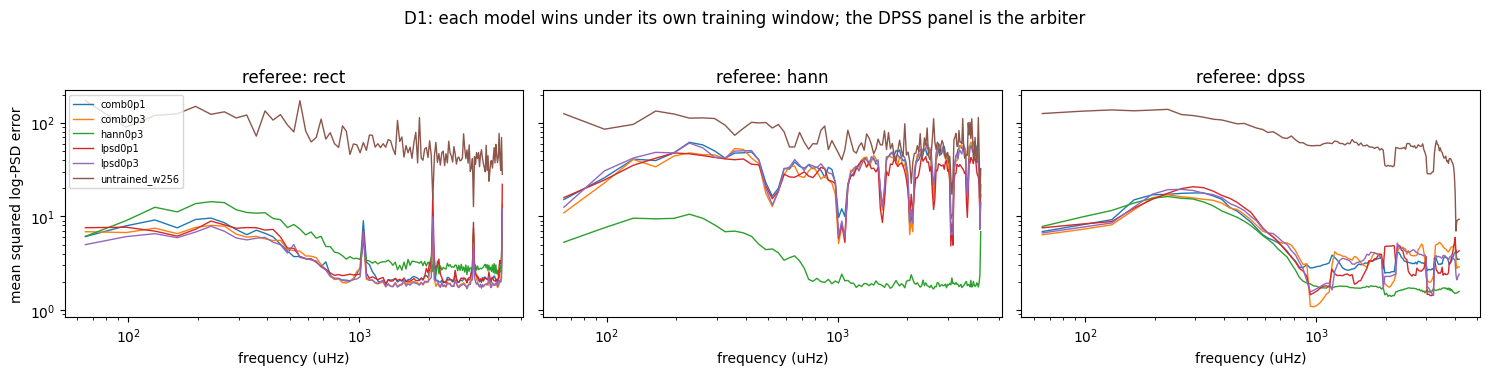

In [20]:
# D1 - per-frequency-bin log-PSD error under all three referees, pulsating-star windows
bins = pd.read_csv(EXPS / "exp07_diag_spectral_bins.csv")
bins["recipe"] = bins["cell"].str.replace("exp07_", "").str.replace("_fbwd", "")
puls = bins[(bins["pool"] == "pulsating") & (bins["bin"] >= 2)]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, referee in zip(axes, ["rect", "hann", "dpss"]):
    for recipe in sorted(puls["recipe"].unique()):
        sub = puls[(puls["referee"] == referee) & (puls["recipe"] == recipe)]
        curve_ = sub.groupby("freq_uhz")["err_sq"].mean()
        ax.plot(curve_.index, curve_.values, label=recipe, lw=1.0)
    ax.set_xscale("log"); ax.set_xlabel("frequency (uHz)")
    ax.set_title(f"referee: {referee}")
axes[0].set_ylabel("mean squared log-PSD error"); axes[0].set_yscale("log"); axes[0].legend(fontsize=7)
fig.suptitle("D1: each model wins under its own training window; the DPSS panel is the arbiter", y=1.03)
plt.tight_layout(); plt.show()

#### Plain-English read of D1

**The referee choice is worth up to a factor of four, so scoring under either training window would have
decided the comparison by itself.** Under the rectangular referee `comb0p3` leads `hann0p3` at every
frequency (7.2 against 11.2 in the lowest band); under the Hann referee the ordering reverses violently
(33.3 against 8.7). Neither is evidence about which reconstruction is better, only about which window the
scorer used, which is why the DPSS panel is the one the verdict is read from.

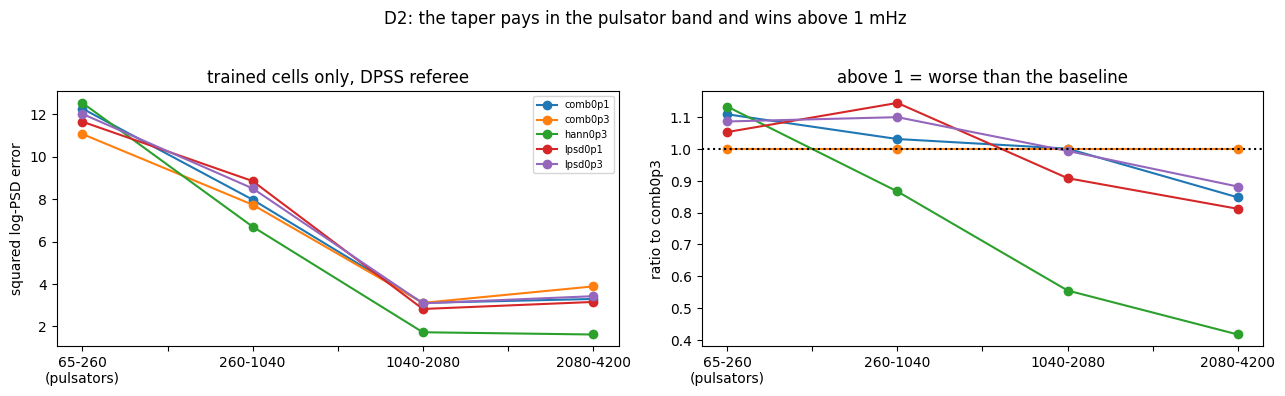

band,65-260\n(pulsators),260-1040,1040-2080,2080-4200
recipe,,,,
comb0p1,12.258,7.971,3.113,3.295
comb0p3,11.059,7.733,3.111,3.886
hann0p3,12.525,6.699,1.729,1.623
lpsd0p1,11.641,8.847,2.825,3.155
lpsd0p3,12.008,8.501,3.091,3.427
untrained_w256,134.100,83.082,55.898,43.212


In [21]:
# D2 - the arbiter's verdict by band: resolution band vs leakage band
# The untrained encoder is 10-40x worse than any trained cell and would flatten the trained curves on a
# shared axis, so it is reported in the table and kept off the plot.
neutral = puls[puls["referee"] == "dpss"].copy()
neutral["band"] = pd.cut(neutral["freq_uhz"], [0, 260, 1040, 2080, 4200],
                         labels=["65-260\n(pulsators)", "260-1040", "1040-2080", "2080-4200"])
band_err = neutral.pivot_table(index="recipe", columns="band", values="err_sq", observed=True)
band_bias = neutral.pivot_table(index="recipe", columns="band", values="bias", observed=True)
trained = band_err.drop(index="untrained_w256")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
trained.T.plot(ax=axes[0], marker="o")
axes[0].set_ylabel("squared log-PSD error"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0); axes[0].legend(fontsize=7)
axes[0].set_title("trained cells only, DPSS referee")
(trained.T / trained.T[BASELINE].values[:, None]).plot(ax=axes[1], marker="o", legend=False)
axes[1].axhline(1, color="k", ls=":")
axes[1].set_ylabel(f"ratio to {BASELINE}"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_title("above 1 = worse than the baseline")
fig.suptitle("D2: the taper pays in the pulsator band and wins above 1 mHz", y=1.03)
plt.tight_layout(); plt.show()
band_err.round(3)

#### Plain-English read of D2

**The predicted trade is real and it is measured: the taper wins the leakage bands and loses the resolution
band.** Under the neutral multitaper referee `hann0p3` is better by 44% at 1040-2080 uHz (1.73 against
3.11) and by 58% at 2080-4200 uHz (1.62 against 3.89), which is the sidelobe suppression working as
advertised. In the 65-260 uHz band, where this corpus's pulsators actually live, it is 13% **worse** than
the baseline (12.53 against 11.06) and worse than every untapered cell. That is the cost, and it lands in
the least convenient place. The bias panel shows the deficit is one-sided everywhere: every model
reconstructs too little power, by 1 to 3 nats for the trained cells and 6 to 11 for the untrained encoder,
so the low-pass shortcut is alive under all five recipes.

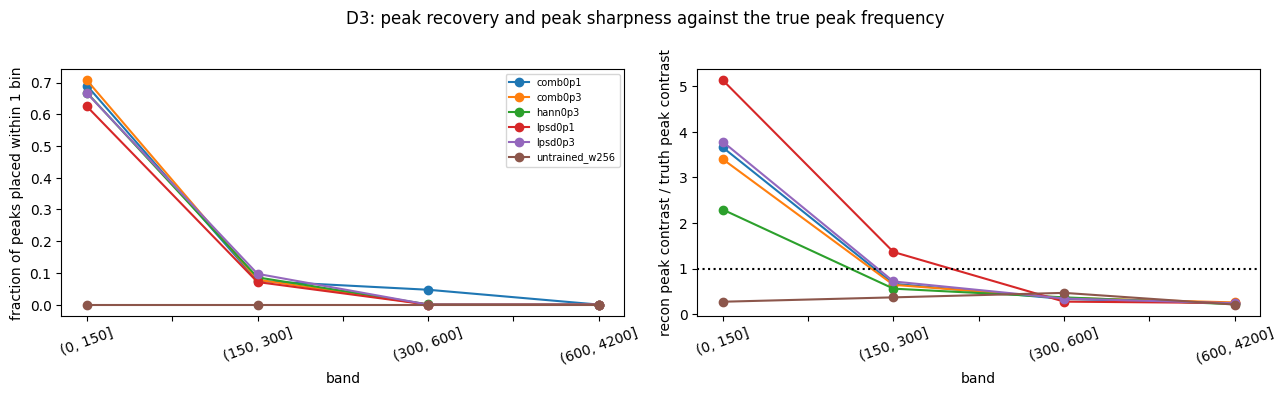

,n_windows,peak_recovered,amp_ratio,contrast_ratio
recipe,,,,
comb0p1,7064,0.267,0.008,0.376
comb0p3,7064,0.261,0.009,0.435
hann0p3,7064,0.251,0.010,0.439
lpsd0p1,7064,0.232,0.006,0.376
lpsd0p3,7064,0.255,0.006,0.423
untrained_w256,1766,0.000,0.000,0.343


In [22]:
# D3 - peak fidelity on real oscillators, scored under the neutral referee only
peaks = pd.read_csv(EXPS / "exp07_diag_spectral_peaks.csv")
peaks["recipe"] = peaks["cell"].str.replace("exp07_", "").str.replace("_fbwd", "")
peaks["recovered"] = peaks["d_peak_bins"].abs() <= 1
summary = peaks.groupby("recipe").agg(n_windows=("d_peak_bins", "size"),
                                      peak_recovered=("recovered", "mean"),
                                      amp_ratio=("amp_ratio", "median"),
                                      contrast_ratio=("contrast_ratio", "median"))

peaks["band"] = pd.cut(peaks["truth_peak_uhz"], [0, 150, 300, 600, 4200])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
peaks.pivot_table(index="band", columns="recipe", values="recovered", observed=True).plot(ax=axes[0], marker="o")
axes[0].set_ylabel("fraction of peaks placed within 1 bin"); axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=7)
peaks.pivot_table(index="band", columns="recipe", values="contrast_ratio", observed=True).plot(
    ax=axes[1], marker="o", legend=False)
axes[1].axhline(1, color="k", ls=":"); axes[1].set_ylabel("recon peak contrast / truth peak contrast")
axes[1].tick_params(axis="x", rotation=20)
fig.suptitle("D3: peak recovery and peak sharpness against the true peak frequency", y=1.03)
plt.tight_layout(); plt.show()
summary.round(3)

#### Plain-English read of D3

**Peak fidelity is poor for every recipe and the taper changes it very little.** Across 7,064 pulsator
windows the reconstructions place the dominant peak within one bin 25-27% of the time and retain about 1%
of its power, and the recipes are separated by less than the spread between them (`hann0p3` 0.251 against
`comb0p3` 0.261). Resolution degrades sharply with frequency for all of them: about 68% of peaks below
150 uHz are recovered, 8% between 150 and 300 uHz, and essentially none above 300 uHz. The sharpness ratio
puts a number on the taper's cost where the probes care: 2.29 against comb's 3.40 below 150 uHz and 0.56
against 0.64 in the 150-300 uHz band, so the tapered model concentrates power at the true peak slightly
less well in exactly the bands D2 flagged. Read with the 1% amplitude ratio, this says the decoder is not
reconstructing pulsations in any real sense under any recipe; what the probe reads out of mu is not a
faithful oscillation spectrum.

## E. Latent health under the frozen recipe
The same collapse and amplitude-dominance metrics exp05 and exp06 tracked, re-read on exp07's fiverecipes. E1/E2 ask whether the recruitment transient and the collapse-reversal survive the new auxconfigurations; E3 is the manifest's report-only P5, which asks whether the latent's leading directionis simply the star's amplitude.

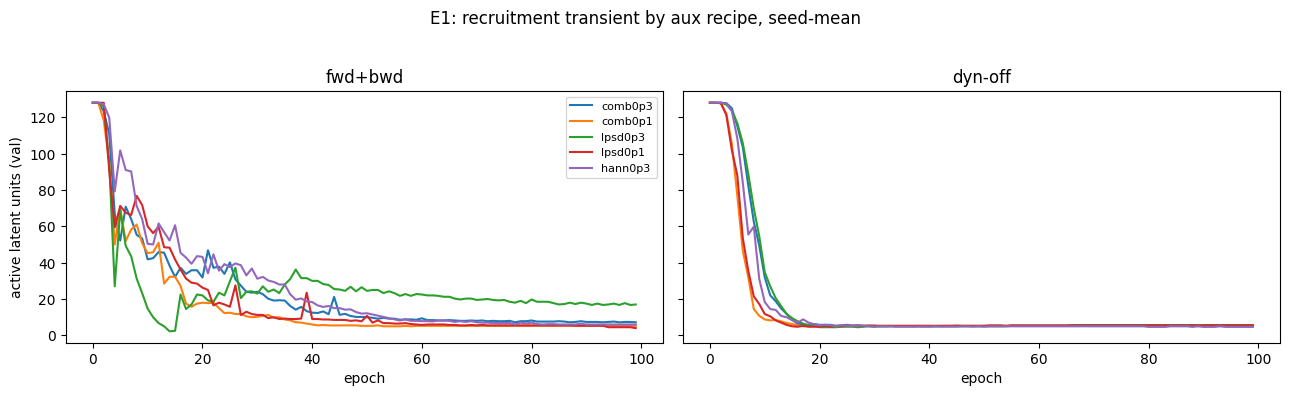

In [23]:
# E1 - active-unit trajectories: does the recruitment transient depend on the aux configuration?
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, arm in zip(axes, ["fbwd", "off"]):
    for recipe in RECIPES:
        stack = []
        for seed in seeds_of(recipe):
            cur = load_curve(cell_name(recipe, arm), seed)
            stack.append(cur.set_index("epoch")["val/n_active_units"])  # align on epoch, not position:
        merged = pd.concat(stack, axis=1)                               # two runs' curves start mid-training
        ax.plot(merged.index, merged.mean(axis=1), label=recipe)
    ax.set_xlabel("epoch"); ax.set_title(ARMS[arm])
axes[0].set_ylabel("active latent units (val)"); axes[0].legend(fontsize=8)
fig.suptitle("E1: recruitment transient by aux recipe, seed-mean", y=1.03)
plt.tight_layout(); plt.show()

#### Plain-English read of E1

The recruitment transient exp06 identified is aux-configuration dependent. On the dynamics-on arm every
recipe re-expands during the middle epochs and then re-collapses before selection, but the height of the
bump is not the same across recipes, and `lpsd0p3` keeps materially more units than the rest. The dyn-off
arm is flat near the collapsed floor except for the two weight-0.1 cells, which never leave 128 units
because their curves are dominated by the pre-warmup state (A6).

In [24]:
# E2 - active units at the SELECTED checkpoint, which is what the probe actually reads
rows = []
for recipe, arm, seed in ALL_RUNS:
    cur = load_curve(cell_name(recipe, arm), seed)
    best_i = cur["val/monitor_recon_aux"].idxmin()
    rows.append({"recipe": recipe, "arm": arm, "seed": seed,
                 "n_active": float(cur.loc[best_i, "val/n_active_units"]),
                 "mu_var": float(cur.loc[best_i, "val/mu_var"])})
latent = pd.DataFrame(rows)
latent.groupby(["recipe", "arm"]).agg(n_active_mean=("n_active", "mean"), n_active_sd=("n_active", "std"),
                                      mu_var=("mu_var", "mean")).round(3)

n_active_mean  n_active_sd  mu_var
recipe  arm                                     
comb0p1 fbwd          5.250        0.500   0.019
        off         128.000        0.000  21.994
comb0p3 fbwd          8.167        2.927   0.022
        off           5.167        0.408   0.017
hann0p3 fbwd          5.833        1.722   0.022
        off           5.000        0.894   0.018
lpsd0p1 fbwd          5.500        1.291   0.020
        off         128.000        0.000  24.299
lpsd0p3 fbwd         18.250       12.500   0.024
        off           5.500        0.577   0.017

#### Plain-English read of E2

**At the checkpoint the probe actually reads, the latent is collapsed to a handful of dimensions under
every properly selected recipe**: 5.0 to 8.2 active units of 128, with `mu_var` around 0.02. Dynamics-on
recruits a little (`comb0p3` 8.2 against 5.2 off, `hann0p3` 5.8 against 5.0) but the effect is small next
to the seed spread, and `lpsd0p3_fbwd`'s 18.3 +/- 12.5 is one runaway seed rather than a cell property. The
two 128-unit rows are the epoch-0 selections of A6 and should not be read as healthy latents; they are
uncollapsed because they are untrained.

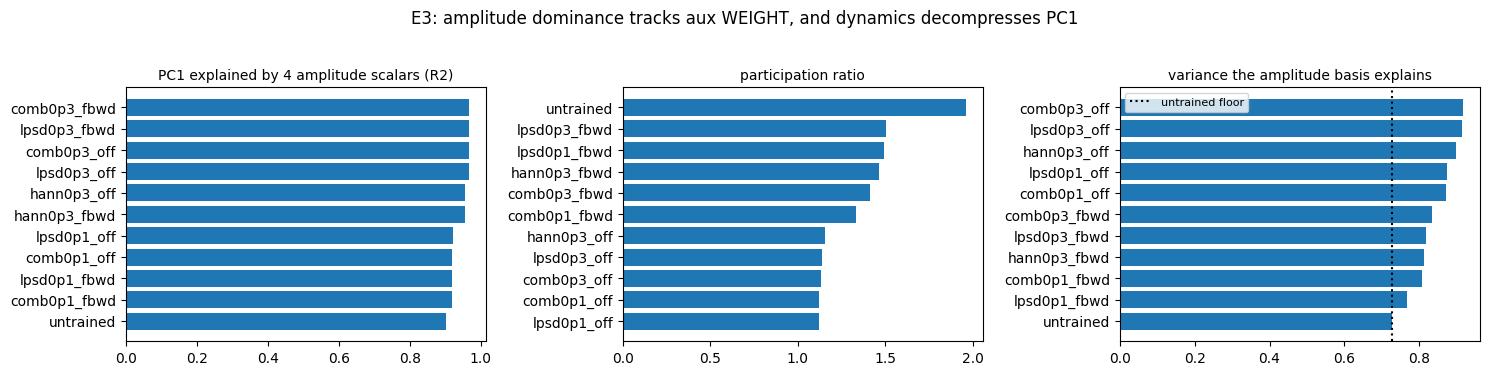

evr_pc1  participation_ratio  r2_amp_pc1  amp_var_frac
recipe aux_weight arm                                                         
comb   0.1        fbwd    0.866                1.331       0.919         0.807
                  off     0.943                1.123       0.920         0.872
       0.3        fbwd    0.832                1.439       0.962         0.823
                  off     0.934                1.145       0.961         0.907
lpsd   0.1        fbwd    0.816                1.495       0.919         0.767
                  off     0.943                1.123       0.923         0.874
       0.3        fbwd    0.812                1.506       0.967         0.817
                  off     0.937                1.138       0.966         0.914

In [25]:
# E3 - P5 amplitude dominance: is PC1 just the star's amplitude? (report-only, per the manifest)
amp_t = amp[amp["footing"] == "pooled"].copy()
amp_t["arm"] = np.where(amp_t["dyn_on"], "fbwd", "off")
amp_t.loc[amp_t["recipe"] == "untrained", "arm"] = "untrained"
amp_t["label"] = amp_t["cell"].str.replace("exp07_", "")
untrained_floor = float(amp_t[amp_t["recipe"] == "untrained"]["amp_var_frac"].mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, col, title in [(axes[0], "r2_amp_pc1", "PC1 explained by 4 amplitude scalars (R2)"),
                       (axes[1], "participation_ratio", "participation ratio"),
                       (axes[2], "amp_var_frac", "variance the amplitude basis explains")]:
    grouped = amp_t.groupby("label")[col].mean().sort_values()
    ax.barh(grouped.index, grouped.values)
    ax.set_title(title, fontsize=10)
axes[2].axvline(untrained_floor, color="k", ls=":", label="untrained floor")
axes[2].legend(fontsize=8)
fig.suptitle("E3: amplitude dominance tracks aux WEIGHT, and dynamics decompresses PC1", y=1.03)
plt.tight_layout(); plt.show()
amp_t.groupby(["recipe", "aux_weight", "arm"])[["evr_pc1", "participation_ratio", "r2_amp_pc1",
                                                "amp_var_frac"]].mean().round(3)

#### Plain-English read of E3

P5 replicates on the pooled footing: **amplitude dominance tracks the aux weight, not the aux form.** The
0.3 cells sit at PC1-on-amplitude R2 around 0.96 and the 0.1 cells around 0.92, with combined and log_psd
interleaved at matched weight, which is the same pressure story the edge told. Turning the dynamics term on
decompresses the leading direction in every recipe, and nothing falls below the untrained amplitude floor.
The `hann0p3` rows are indistinguishable from `comb0p3` at the same weight, so the taper does not change
what the leading latent direction encodes.

## F. Is hann's latent the same latent?
The taper was introduced to remove a reconstruction artifact, not to change the representation. Whether it did anything more is a question about subspaces, not coordinates: two encoders put their informationin unrelated bases, so the comparable object is what each spans over the same stars. F1 reports held-outcanonical correlations between hann and comb, with same-recipe seed pairs as the null. F2 asks thesharper version: project comb's shared content out of hann's mu and probe what survives.

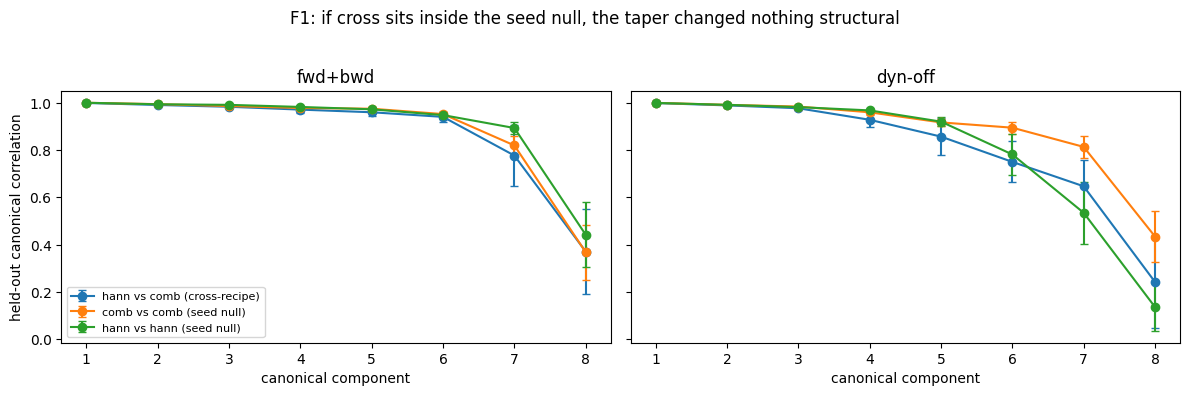

k                  4      8      16
arm  pair                          
fbwd cross      0.846  0.874  0.875
     null_comb  0.919  0.884  0.884
     null_hann  0.891  0.903  0.910
off  cross      0.947  0.799  0.793
     null_comb  0.971  0.874  0.827
     null_hann  0.966  0.789  0.814

In [26]:
# F1 - held-out canonical correlations, cross-recipe against the seed-pair null (k = 8 primary)
cca = pd.read_csv(EXPS / "exp07_diag_cca.csv")
prim = cca[cca["k"] == 8]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
labels = {"cross": "hann vs comb (cross-recipe)", "null_comb": "comb vs comb (seed null)",
          "null_hann": "hann vs hann (seed null)"}
for ax, arm in zip(axes, ["fbwd", "off"]):
    for kind, label in labels.items():
        sub = prim[(prim["arm"] == arm) & (prim["pair"] == kind)]
        stat = sub.groupby("component")["cancorr_test"].agg(["mean", "sem"])
        ax.errorbar(stat.index, stat["mean"], yerr=2 * stat["sem"], marker="o", capsize=3, label=label)
    ax.set_xlabel("canonical component"); ax.set_title(ARMS[arm])
axes[0].set_ylabel("held-out canonical correlation"); axes[0].legend(fontsize=8)
fig.suptitle("F1: if cross sits inside the seed null, the taper changed nothing structural", y=1.03)
plt.tight_layout(); plt.show()
cca.groupby(["arm", "pair", "k"])["cancorr_test"].mean().unstack().round(3)

#### Plain-English read of F1

**The taper did not change the latent.** On the dynamics-on arm the cross-recipe canonical correlations
(0.999, 0.990, 0.983, 0.971, 0.960, 0.940 for the first six components) sit inside the band traced by
same-recipe seed pairs (comb-vs-comb 1.000, 0.994, 0.986, 0.978, 0.975, 0.952; hann-vs-hann similar), so
hann and comb differ from each other no more than two seeds of one recipe differ. Counting components
above 0.9 gives 5.8 for the cross pairs against 6.1 and 6.5 for the two nulls, again a difference smaller
than the null's own spread. The dyn-off arm is noisier and the cross pairs fall off a little faster from
component 4, but the same conclusion holds within the seed spread. This answers the handoff's question
directly: the Hann taper is an edge fix, not a representational change.

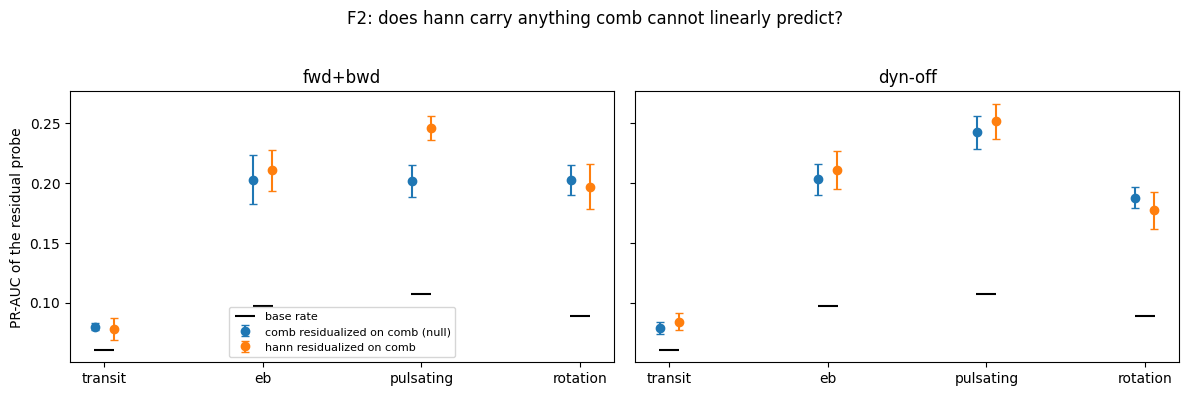

pr_auc_full  pr_auc_residual  \
arm  kind                             task                                      
fbwd comb residualized on comb (null) eb               0.775            0.203   
                                      pulsating        0.785            0.202   
                                      rotation         0.563            0.203   
                                      transit          0.147            0.080   
     hann residualized on comb        eb               0.771            0.211   
                                      pulsating        0.805            0.246   
                                      rotation         0.559            0.197   
                                      transit          0.144            0.078   
off  comb residualized on comb (null) eb               0.736            0.203   
                                      pulsating        0.785            0.242   
                                      rotation         0.539            0.188   
                                      transit          0.119            0.079   
     hann residualized on comb        eb               0.738            0.211   
                                      pulsating        0.811            0.252   
                                      rotation         0.536            0.177   
                                      transit          0.135            0.084   

                                                 resid_var_frac  
arm  kind                             task                       
fbwd comb residualized on comb (null) eb                  0.005  
                                      pulsating           0.005  
                                      rotation            0.005  
                                      transit             0.005  
     hann residualized on comb        eb                  0.007  
                                      pulsating           0.007  
                                      rotation            0.007  
                                      transit             0.007  
off  comb residualized on comb (null) eb                  0.003  
                                      pulsating           0.003  
                                      rotation            0.003  
                                      transit             0.003  
     hann residualized on comb        eb                  0.005  
                                      pulsating           0.005  
                                      rotation            0.005  
                                      transit             0.005

In [27]:
# F2 - the hann-unique residual: what survives projecting comb's shared content out of hann's mu
resid = pd.read_csv(EXPS / "exp07_diag_residual_probe.csv")
resid["kind"] = np.where(resid["pair"] == "cross", "hann residualized on comb", "comb residualized on comb (null)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
base_rate = {}
for task in TASKS:
    base_rate[task] = float(subset[subset["split"] == "test"][task].mean())
for ax, arm in zip(axes, ["fbwd", "off"]):
    sub = resid[resid["arm"] == arm]
    stat = sub.groupby(["kind", "task"])["pr_auc_residual"].agg(["mean", "sem"]).reset_index()
    for i, (kind, grp) in enumerate(stat.groupby("kind")):
        grp = grp.set_index("task").reindex(TASKS)
        ax.errorbar(np.arange(len(TASKS)) + 0.12 * (i - 0.5), grp["mean"], yerr=2 * grp["sem"],
                    fmt="o", capsize=3, label=kind)
    ax.scatter(np.arange(len(TASKS)), [base_rate[t] for t in TASKS], marker="_", s=200, color="k",
               label="base rate")
    ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS); ax.set_title(ARMS[arm])
axes[0].set_ylabel("PR-AUC of the residual probe"); axes[0].legend(fontsize=8)
fig.suptitle("F2: does hann carry anything comb cannot linearly predict?", y=1.03)
plt.tight_layout(); plt.show()
resid.groupby(["arm", "kind", "task"])[["pr_auc_full", "pr_auc_residual", "resid_var_frac"]].mean().round(3)

#### Plain-English read of F2

**There is no hann-unique information.** A linear map from comb's mu predicts 99.3-99.5% of the variance
of hann's mu, and probing the remaining residual scores 0.21 on eb and 0.25 on pulsating, against base
rates of 0.097 and 0.107 and full-mu scores of 0.77 and 0.81. Crucially the same operation between two
seeds of the *same* recipe leaves an equally informative residual (0.20 eb, 0.20-0.24 pulsating), so what
the residual carries is seed-to-seed variation, not anything the taper added. Taken with F1 and with G
below, the pulsating gain is not delivered by new content in the representation; it is a small
reweighting of content both recipes already share.

## G. Where the pulsating win lives
hann0p3's one significant probe gain is pulsating (+0.018 on mean, +0.025 on mean_std over 6 seeds), and it is aux-driven rather than dynamics-driven: the dyn-off arm scores the same as fwd+bwd. If the taper isthe cause, the gain should be predictable from spectral leakage. Leakage under a rectangular window iszero when a signal completes a whole number of cycles inside the window and worst at half-bin offset, sothe mechanism-specific prediction is that hann's per-star advantage peaks at offset 0.5 and vanishes at0. PR-AUC cannot be binned, so this uses per-star score ranks.

In [28]:
# G0 - decompose the pulsating gate into per-star contributions
# A star's rank is the wrong currency: PR-AUC is dominated by the top of the ranking, so hann can gain
# +0.018 while the MEAN rank of positives does not move. Average precision decomposes exactly, though:
# AP = sum over positives of (precision at that positive's rank) / n_pos, so each positive owns a share
# of the score and those shares sum back to the number the gate was decided on.
stars = pd.read_parquet(EXPS / "exp07_diag_star_scores.parquet")
stars = stars[stars["cell"].isin([cell_name(WINNER, "fbwd"), cell_name(BASELINE, "fbwd")])]


def ap_contribution(g):
    """Each positive's share of average precision, in the order the probe ranked the test stars."""
    g = g.sort_values("score", ascending=False)
    y = g["y"].to_numpy()
    precision = np.cumsum(y) / np.arange(1, len(y) + 1)
    return pd.Series(np.where(y == 1, precision / y.sum(), 0.0), index=g.index)


stars["contrib"] = stars.groupby(["cell", "seed", "pooling", "task"], group_keys=False).apply(ap_contribution)
wide = stars[stars["y"] == 1].pivot_table(index=["pooling", "task", "seed", "tic_id"], columns="cell",
                                          values="contrib").reset_index()
wide["delta"] = wide[cell_name(WINNER, "fbwd")] - wide[cell_name(BASELINE, "fbwd")]
per_star = wide.groupby(["pooling", "task", "tic_id"])["delta"].mean().reset_index()

recovered = per_star.groupby(["pooling", "task"])["delta"].sum()
for pooling, task, claim in [("mean", "pulsating", 0.0179), ("mean_std", "pulsating", 0.0247),
                             ("mean_resid", "pulsating", 0.0106), ("mean", "eb", -0.0087)]:
    assert abs(recovered.loc[(pooling, task)] - claim) < 5e-4, (pooling, task, recovered.loc[(pooling, task)])
print("per-star contributions sum back to the paired gate deltas")

labels = pd.read_csv(root / "labels" / "variability_labels_star.csv",
                     usecols=["tic_id", "pulsating_period", "pulsating_subtype"])
window_hours = WINDOW * 2 / 60
puls = per_star[per_star["task"] == "pulsating"].merge(labels, on="tic_id")
puls["cycles"] = window_hours / (puls["pulsating_period"] * 24)
frac = puls["cycles"] % 1
puls["bin_offset"] = np.minimum(frac, 1 - frac)
print(f"{int(len(puls) / puls['pooling'].nunique())} pulsating test positives, all with catalogued periods: "
      f"{puls['pulsating_period'].notna().all()}")
recovered.round(4)

per-star contributions sum back to the paired gate deltas
216 pulsating test positives, all with catalogued periods: True


pooling     task     
mean        eb          -0.0087
            pulsating    0.0179
mean_resid  eb          -0.0070
            pulsating    0.0106
mean_std    eb           0.0085
            pulsating    0.0247
Name: delta, dtype: float64

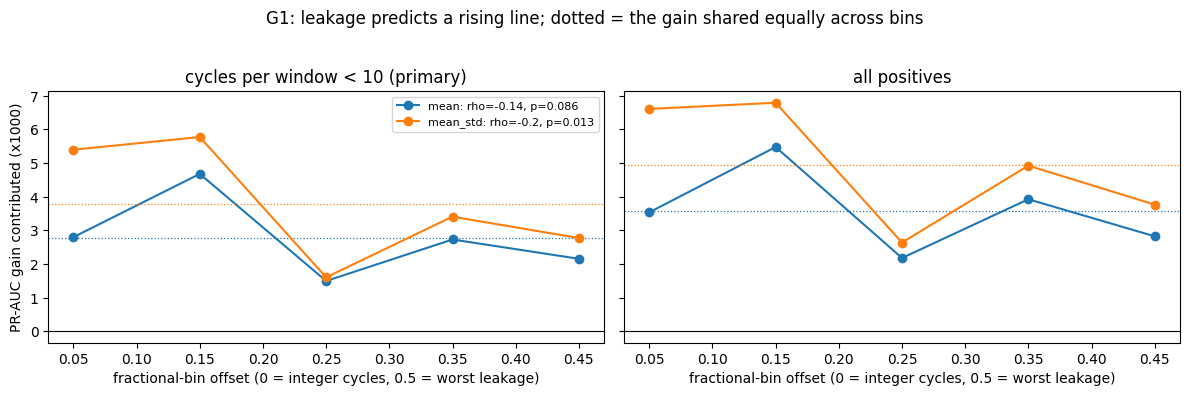

In [29]:
# G1 - the leakage test: where along the leakage coordinate does the gain actually sit?
# Catalogued period precision degrades the offset once a star fits many cycles in a window (a 1% period
# error moves the offset by 0.22 at 22 cycles), so the primary cut keeps stars below 10 cycles and the
# full range is shown beside it. That precision loss biases toward the null, so a positive result would
# be conservative and a null is the weaker claim of the two.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
edges = np.linspace(0, 0.5, 6)
cuts = [("cycles per window < 10 (primary)", puls[puls["cycles"] < 10]), ("all positives", puls)]
for ax, (title, sub) in zip(axes, cuts):
    for pooling in ["mean", "mean_std"]:
        d = sub[sub["pooling"] == pooling].copy()
        d["offset_bin"] = pd.cut(d["bin_offset"], edges)
        stat = d.groupby("offset_bin", observed=True)["delta"].sum()
        centres = [iv.mid for iv in stat.index]
        rho, p = spearmanr(d["bin_offset"], d["delta"])
        line, = ax.plot(centres, 1000 * stat.values, "o-",
                        label=f"{pooling}: rho={round(rho, 2)}, p={round(p, 3)}")
        # flat reference: the same total gain shared equally between the five bins
        ax.axhline(1000 * stat.sum() / len(stat), color=line.get_color(), ls=":", lw=0.9)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("fractional-bin offset (0 = integer cycles, 0.5 = worst leakage)")
    ax.set_title(title)
axes[0].set_ylabel("PR-AUC gain contributed (x1000)"); axes[0].legend(fontsize=8)
fig.suptitle("G1: leakage predicts a rising line; dotted = the gain shared equally across bins", y=1.03)
plt.tight_layout(); plt.show()

#### Plain-English read of G1

**The mechanism prediction fails, and fails with the wrong sign.** If the taper helped by suppressing
rectangular-window leakage, the gain would concentrate at half-bin offsets and vanish at integer cycles.
Instead the +0.018 is spread across every offset bin, and the rank correlation is mildly *negative*
(mean_std rho = -0.20, p = 0.013; mean rho = -0.14, p = 0.086 on the primary cut), meaning the gain is if
anything slightly larger for stars whose pulsation fits a whole number of cycles into the window, which is
where leakage is zero. The catalog-precision caveat cannot rescue the prediction, since it biases toward
a null rather than toward a reversal.

Read together with D2 this is the section's real result: `hann0p3` reconstructs the 65-260 uHz band 13%
*worse* than the baseline under a neutral referee, and still scores +0.018 better on the pulsating probe.
Spectral fidelity in a task's own frequency band does not predict that task's probe score, so whatever the
taper bought pulsating, it did not buy it by reconstructing pulsations better.

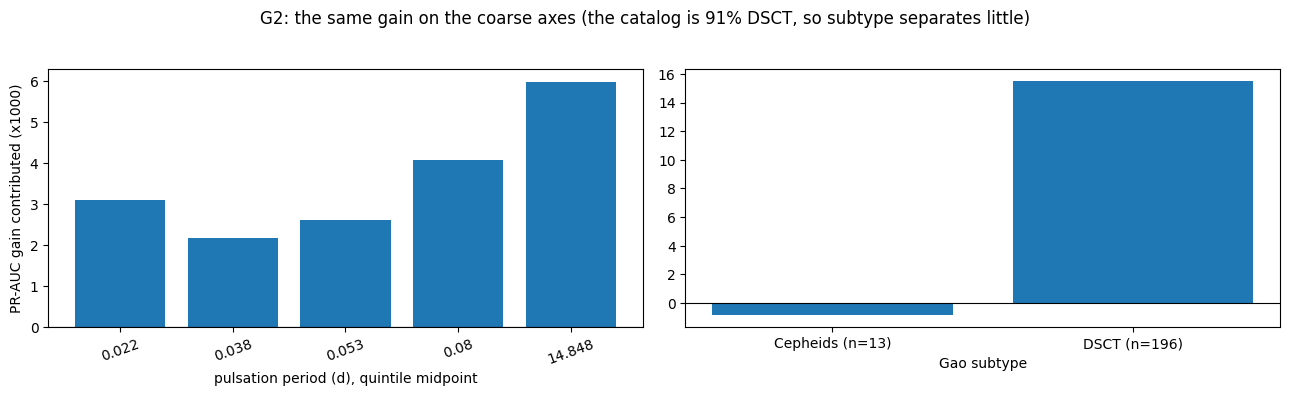

,sum,size
period_bin,,
"(0.0149, 0.0295]",0.0031,44
"(0.0295, 0.0466]",0.0022,43
"(0.0466, 0.0584]",0.0026,43
"(0.0584, 0.102]",0.0041,43
"(0.102, 29.594]",0.0060,43


In [30]:
# G2 - the coarse axes the same gain could be read on: pulsation period and subtype
d = puls[puls["pooling"] == "mean"].copy()
d["period_bin"] = pd.qcut(d["pulsating_period"], 5)
by_period = d.groupby("period_bin", observed=True)["delta"].agg(["sum", "size"])
counts = d["pulsating_subtype"].value_counts()
by_subtype = d[d["pulsating_subtype"].isin(counts[counts >= 5].index)].groupby(
    "pulsating_subtype")["delta"].agg(["sum", "size"])

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(range(len(by_period)), 1000 * by_period["sum"])
axes[0].set_xticks(range(len(by_period)))
axes[0].set_xticklabels([f"{round(iv.mid, 3)}" for iv in by_period.index], rotation=20)
axes[0].axhline(0, color="k", lw=0.8); axes[0].set_xlabel("pulsation period (d), quintile midpoint")
axes[0].set_ylabel("PR-AUC gain contributed (x1000)")
axes[1].bar(range(len(by_subtype)), 1000 * by_subtype["sum"])
axes[1].set_xticks(range(len(by_subtype)))
axes[1].set_xticklabels([f"{i} (n={int(n)})" for i, n in zip(by_subtype.index, by_subtype["size"])])
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_xlabel("Gao subtype")
fig.suptitle("G2: the same gain on the coarse axes (the catalog is 91% DSCT, so subtype separates little)",
             y=1.03)
plt.tight_layout(); plt.show()
by_period.round(4)

#### Plain-English read of G2

The coarse axes agree with G1 and add nothing that rescues a leakage story: the gain is distributed across
all five period quintiles rather than concentrating in the short-period bins where a resolution or leakage
effect would live. The subtype panel is reported for completeness only, since the Gao cross-match is 91%
delta Scuti in this test split and the remaining classes have single-digit counts, so it cannot separate
anything.

## H. mu-ACF: did the frozen recipe re-open the rollout axis?
exp06 closed rollout evaluation at 256x16 (lag-1 mu-trajectory ACF -0.006 on periodic stars against a0.3 re-opening threshold, growing more negative at longer windows). The exp07 artifacts carry the samepre-gate for all ten cells, so this is a cheap confirmation that the aux axis did not quietly move it.

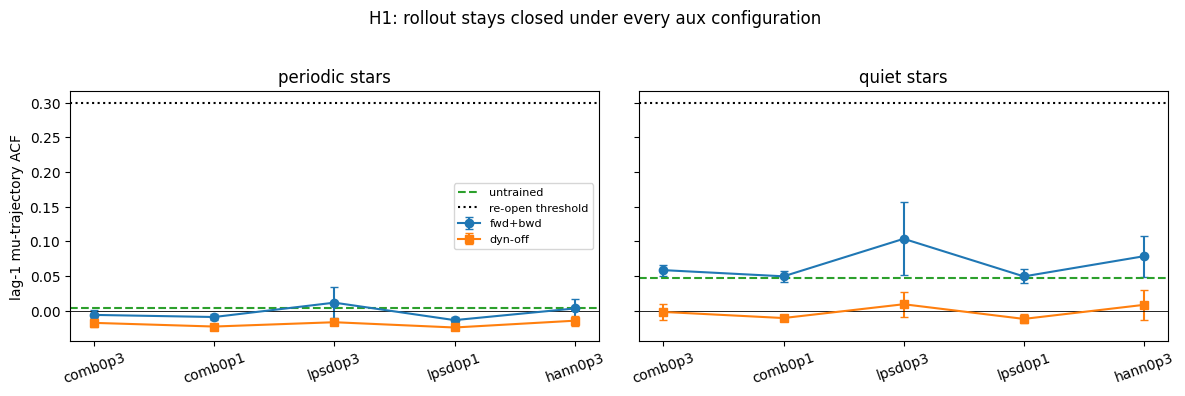

In [31]:
# H1 - lag-1 mu-trajectory ACF per recipe and arm, against the 0.3 re-opening threshold
a1 = acf4[acf4["lag"] == 1].copy()
a1["recipe"] = a1["cell"].str.replace("exp07_", "").str.rsplit("_", n=1).str[0]
a1["arm"] = a1["cell"].str.rsplit("_", n=1).str[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, cls in zip(axes, ["periodic", "quiet"]):
    for arm, marker in [("fbwd", "o"), ("off", "s")]:
        sub = a1[(a1["cls"] == cls) & (a1["arm"] == arm)]
        stat = sub.groupby("recipe")["acf"].agg(["mean", "sem"]).reindex(RECIPES)
        ax.errorbar(range(len(RECIPES)), stat["mean"], yerr=2 * stat["sem"], marker=marker,
                    capsize=3, label=ARMS[arm])
    unt = a1[(a1["cls"] == cls) & (a1["cell"] == "untrained_w256")]["acf"].mean()
    ax.axhline(unt, color="tab:green", ls="--", label="untrained")
    ax.axhline(0.3, color="k", ls=":", label="re-open threshold")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xticks(range(len(RECIPES))); ax.set_xticklabels(RECIPES, rotation=20)
    ax.set_title(f"{cls} stars")
axes[0].set_ylabel("lag-1 mu-trajectory ACF"); axes[0].legend(fontsize=8)
fig.suptitle("H1: rollout stays closed under every aux configuration", y=1.03)
plt.tight_layout(); plt.show()

#### Plain-English read of H1

**Rollout stays closed under every aux configuration.** Lag-1 mu-trajectory autocorrelation on periodic
stars runs -0.014 to +0.012 across the five recipes against a re-opening threshold of 0.3, with the
untrained reference at +0.004; no recipe moves the number by anything meaningful, so the exp06 verdict at
this geometry is unchanged and the aux axis was never a route back to the rollout question. The inversion
exp05 flagged is still there and is if anything clearer: quiet stars hold more trajectory correlation
(+0.05 to +0.10 on the dynamics-on arm) than periodic ones, which remains the wrong ordering for a model
that has learned oscillatory physics.

## I. Live light-curve inspection

The gates above are aggregates. This section puts the frozen recipe in front of individual stars: fit
each downstream probe on the winner's frozen mu, pick a star from each confusion quadrant, and draw
what `hann0p3` and `comb0p3` actually reconstruct for it. Every panel draws a fresh random star on each
re-run, so re-execute a cell to see another example.

Two probe pools, as everywhere else in the project. The **v1 subset** (9,428 train / 2,021 test stars)
carries `transit`, `eb`, `pulsating`, `rotation`, `flare`, `ijspeert` and `rotation_period`; the
separate **new-task pool** carries `osc_giant`, `solar_like_osc`, `rgb_vs_heb` and `numax_hon`. Each
task is scored only on the population its catalogue defines, so the panels below never compare a star
against a label that does not exist for it. `dnu_hatt`, `numax_hatt` and `prot_kounkel` are outside the
7-probe menu (ADR-0010) and are not fitted here.

These are display panels on the winner's seed-0 checkpoint, not a scorecard: the PR-AUCs are one-seed
readings on one pooling and carry no untrained reference, so read them for *which stars* the probe gets
right, not for how well it does. The headline numbers live in section B.

In [32]:
# I0 - the two panel encoders, the corpus light-curve index, and the probe label sources
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, confusion_matrix
from swm.eval.new_task_scorecard import label_frame

PANEL_RECIPES = [WINNER, BASELINE]        # hann0p3 first, comb0p3 second, both fwd_bwd, same seed
panel_models = {}
for recipe in PANEL_RECIPES:
    panel_models[recipe] = load_model(cell_name(recipe, "fbwd"), PANEL_SEED)[0]

# One scandir pass over the corpus: the first stored segment of every star, keyed by TIC.
sequences_dir = root / "processed" / "sequences"
first_file_by_tic = {}
for name in os.listdir(sequences_dir):
    if not name.endswith(".npz"):
        continue
    tic = int(name[3:13])
    current = first_file_by_tic.get(tic)
    if current is None or name < current:
        first_file_by_tic[tic] = name
available = set(first_file_by_tic)

# --- labels ---
canon = pd.read_csv(root / "labels" / "variability_labels_star.csv")
canon["tic_id"] = canon["tic_id"].astype(int)
canon = canon.set_index("tic_id")
ijspeert_tics = set(pd.read_csv(root / "labels" / "external" / "ijspeert2024_bright.csv")["TIC"].astype(int))

v1_labels = subset.set_index("tic_id").copy()
v1_labels["flare"] = pd.to_numeric(canon["flare_ever"].reindex(v1_labels.index),
                                   errors="coerce").fillna(0).astype(int)
v1_labels["ijspeert"] = v1_labels.index.map(lambda t: int(int(t) in ijspeert_tics))
# rotation_period is scope-limited to P_rot <= 5 d on catalogued rotators (ADR-0010); everything else NaN.
prot = pd.to_numeric(canon["rotation_period"], errors="coerce")
rotator = pd.to_numeric(canon["rotation"], errors="coerce") == 1
v1_labels["rotation_period"] = prot.where(rotator & (prot <= 5)).reindex(v1_labels.index)

LABELS = {"v1": v1_labels, "new": label_frame()}

# --- frozen mu, star-level mean pooling, winner checkpoint only ---
V1_MU = EXPS / "exp07_forensics" / "mu_cache" / f"exp07_{WINNER}_fbwd_seed{PANEL_SEED}.npz"
NEW_MU = EXPS / "exp07_forensics" / "new_task_mu_cache" / f"{WINNER}_fbwd_s{PANEL_SEED}.npz"
assert V1_MU.exists() and NEW_MU.exists(), f"missing panel mu cache: {V1_MU if not V1_MU.exists() else NEW_MU}"


def pooled_mu(pool):
    """Star-level mean-pooled mu for one probe pool as {split: (tics, X)}.

    The v1 cache (written by analyze_exp07_diagnostics.py) already stores the per-star mean; the
    new-task cache stores concatenated window mu plus per-star counts, so it is pooled here.
    """
    if pool == "v1":
        payload = np.load(V1_MU, allow_pickle=False)
        return {s: (payload[f"tics_{s}"].astype(int), payload[f"mean_{s}"]) for s in ["train", "test"]}
    payload = np.load(NEW_MU, allow_pickle=False)
    out = {}
    for split in ["train", "test"]:
        flat, counts = payload[f"{split}_mu"], payload[f"{split}_counts"]
        means, start = [], 0
        for n_win in counts:
            means.append(flat[start:start + int(n_win)].mean(axis=0))
            start += int(n_win)
        out[split] = (payload[f"{split}_tics"].astype(int), np.vstack(means))
    return out


MU = {pool: pooled_mu(pool) for pool in ["v1", "new"]}
print("stars with light curves on disk:", len(available),
      "| v1 test", len(MU["v1"]["test"][0]), "| new-task test", len(MU["new"]["test"][0]))

stars with light curves on disk: 119754 | v1 test 2021 | new-task test 3429


The two loaders every panel below uses. The corpus stores each segment as 1024-cadence windows, so a
segment is flattened back into one continuous strip for display and then fed to the model cut into the
256-cadence windows it was trained on. Each window is reconstructed independently and the pieces are
laid back end to end, which is exactly why the window-edge defect of section C is visible in these
strips at all.

In [33]:
# I1 - segment loader and per-recipe reconstruction
def load_segment(tic):
    """
    Load one stored segment of a star's light curve straight from the corpus.
    Flux is MAD-normalised per segment by the build pipeline, so the vertical scale is in units of
    that star's own scatter. Returns flux and time in days measured from the segment start.
    """
    payload = np.load(sequences_dir / first_file_by_tic[tic])
    flux = payload["windows"].reshape(-1)
    times = payload["times"].reshape(-1)
    return flux, times - times[0]


def reconstruct(flux, model):
    """
    Encode and decode a flux strip in 256-cadence windows, the geometry every exp07 cell was trained on.
    Each window is reconstructed independently, then the windows are laid back end to end.
    """
    usable = (len(flux) // WINDOW) * WINDOW
    windows = np.ascontiguousarray(flux[:usable].reshape(-1, WINDOW, 1))  # (n_win, 256, 1)
    x = torch.from_numpy(windows).to(device)
    with torch.no_grad():  # disable gradient tracking, not needed at eval time
        mu, _ = model.encoder(x)
        recon = model.decoder(mu)  # (n_win, 256, 1)
    return recon[:, :, 0].cpu().numpy().reshape(-1)

The nine detection probes of the panel menu, fitted with the same frozen readout used everywhere in
this project: logistic regression on mean-pooled mu, no fine-tuning. The operating point is the
F1-optimal cut on out-of-fold *train* predictions, because `class_weight="balanced"` calibrates the
probe to a 50/50 world while real prevalence is a few percent -- a fixed 0.5 cut would over-flag by
construction and the panels would be showing that, not the model.

In [34]:
# I2 - fit the panel probes on the winner's frozen mu
PANEL_PROBES = {"transit": ("v1", "detection"), "eb": ("v1", "detection"),
                "pulsating": ("v1", "detection"), "rotation": ("v1", "detection"),
                "flare": ("v1", "detection"), "ijspeert": ("v1", "detection"),
                "osc_giant": ("new", "detection"), "solar_like_osc": ("new", "detection"),
                "rgb_vs_heb": ("new", "detection"),
                "rotation_period": ("v1", "regression"), "numax_hon": ("new", "regression")}
DETECTION_PROBES = [t for t, (_, kind) in PANEL_PROBES.items() if kind == "detection"]


def fit_probe(task):
    """
    Fit one detection probe and choose the operating point the confusion panels are drawn at.
    Returns per-star test predictions, the test PR-AUC, and the chosen threshold.
    """
    pool, _ = PANEL_PROBES[task]
    labels = LABELS[pool]
    prepared = {}
    for split in ["train", "test"]:
        ids, x = MU[pool][split]
        y = pd.to_numeric(labels[task].reindex(ids), errors="coerce").to_numpy()
        defined = ~np.isnan(y)  # a probe scores only the population its catalogue covers
        prepared[split] = (ids[defined], x[defined], y[defined].astype(int))

    ids_tr, x_tr, y_tr = prepared["train"]
    ids_te, x_te, y_te = prepared["test"]
    scaler = StandardScaler().fit(x_tr)  # mean/std from training stars only (no leakage)
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(scaler.transform(x_tr), y_tr)
    prob = clf.predict_proba(scaler.transform(x_te))[:, 1]

    oof = cross_val_predict(LogisticRegression(class_weight="balanced", max_iter=2000),
                            scaler.transform(x_tr), y_tr,
                            cv=StratifiedKFold(5, shuffle=True, random_state=0),
                            method="predict_proba")[:, 1]  # each star scored by a model that never saw it
    order = np.argsort(-oof, kind="mergesort")
    y_sorted = y_tr[order]
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    fn = y_sorted.sum() - tp
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / (2 * tp + fp + fn), 0.0)
    threshold = float(oof[order][int(np.argmax(f1))])

    preds = pd.DataFrame({"tic_id": ids_te, "label": y_te, "prob": prob,
                          "pred": (prob >= threshold).astype(int)})
    return preds, float(average_precision_score(y_te, prob)), threshold


probe_preds, probe_rows = {}, []
for task in DETECTION_PROBES:
    preds, pr_auc, threshold = fit_probe(task)
    probe_preds[task] = preds
    probe_rows.append({"task": task, "pool": PANEL_PROBES[task][0], "n_test": len(preds),
                       "n_test_pos": int(preds["label"].sum()), "base_rate": float(preds["label"].mean()),
                       "pr_auc": pr_auc, "threshold": threshold})
probe_table = pd.DataFrame(probe_rows).set_index("task")
display(probe_table.round(3))

,pool,n_test,n_test_pos,base_rate,pr_auc,threshold
task,,,,,,
transit,v1,2021,122,0.060,0.138,0.641
eb,v1,2021,196,0.097,0.769,0.764
pulsating,v1,2021,216,0.107,0.808,0.637
rotation,v1,2021,180,0.089,0.577,0.790
flare,v1,2021,22,0.011,0.088,0.920
ijspeert,v1,2021,93,0.046,0.444,0.818
osc_giant,new,3429,1313,0.383,0.858,0.469
solar_like_osc,new,3429,417,0.122,0.333,0.575
rgb_vs_heb,new,161,113,0.702,0.838,0.086


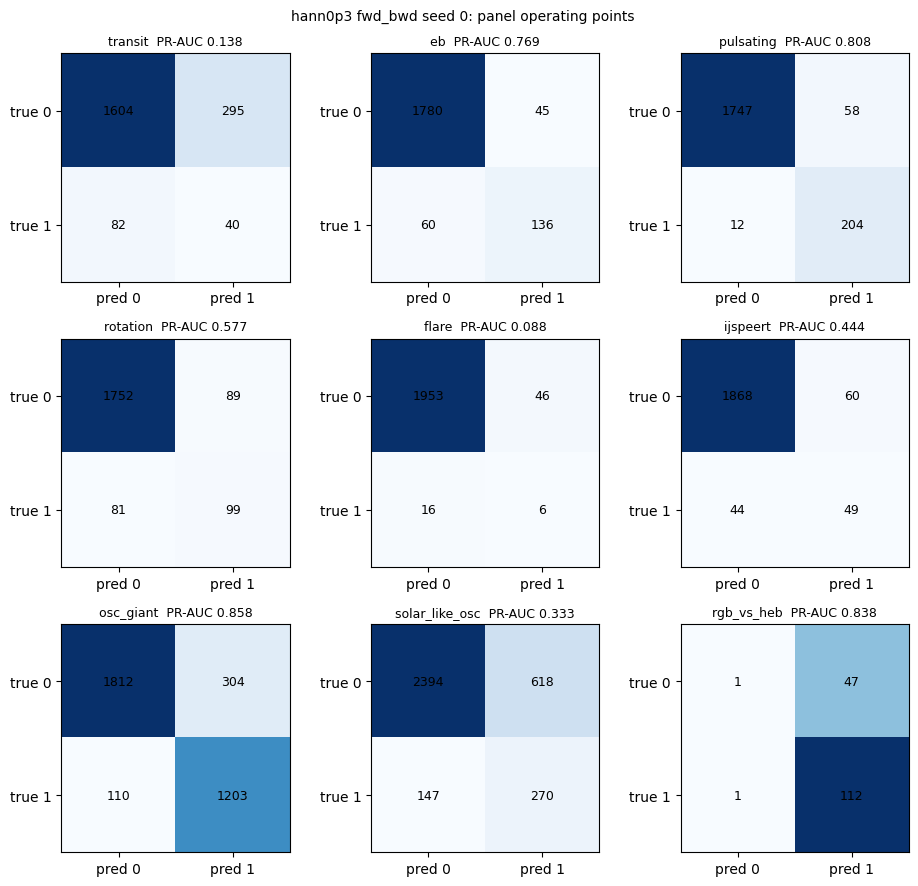

In [35]:
# I3 - confusion matrices at those operating points
fig, axes = plt.subplots(3, 3, figsize=(9.5, 9))
for ax, task in zip(axes.ravel(), DETECTION_PROBES):
    p = probe_preds[task]
    cm = confusion_matrix(p["label"], p["pred"], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for a in range(2):
        for b in range(2):
            ax.text(b, a, cm[a, b], ha="center", va="center", fontsize=9)
    ax.set_xticks([0, 1], ["pred 0", "pred 1"])
    ax.set_yticks([0, 1], ["true 0", "true 1"])
    ax.set_title(f"{task}  PR-AUC {probe_table.loc[task, 'pr_auc']:.3f}", fontsize=9)
plt.suptitle(f"{WINNER} fwd_bwd seed {PANEL_SEED}: panel operating points", fontsize=10)
plt.tight_layout()
plt.show()

### I4. Confusion quadrants with both recipes' reconstructions

One randomly chosen star per confusion quadrant of the chosen probe, in columns; one row per recipe,
each showing that recipe's reconstruction (coloured) laid over the same input flux (grey). The star and
the quadrant are decided by the **winner's** probe, so a column compares two decoders on one star, not
two probes.

Change the task in the call to look at any other detection probe -- add a cell below with
`show_quadrants("pulsating")`, `"transit"`, `"rotation"`, `"flare"`, `"ijspeert"`, `"osc_giant"`,
`"solar_like_osc"` or `"rgb_vs_heb"`. Re-running a cell draws different stars.

Both rows of a column share one y-scale, set by the input flux, so the reconstructions are
directly comparable; `comb0p3`'s window-edge spikes are frequently larger than the star's whole
range and simply run off the panel, which is the section-C defect seen in flux rather than in an
averaged error profile.


In [36]:
# I4 - one star per confusion quadrant, reconstructed by both recipes
def show_quadrants(task):
    """
    Draw one randomly chosen star from each confusion quadrant of `task`, with each panel recipe's
    reconstruction overlaid on the input. Columns are quadrants, rows are recipes, and the star in a
    column is shared, so the row difference is the decoder alone.
    A different star is drawn on every re-run, so re-execute the cell to see another example.
    """
    assert PANEL_PROBES[task][1] == "detection", f"{task} is a regression probe; use show_positive_negative"
    rng = np.random.default_rng()
    # rng = np.random.default_rng(0) # uncomment for a reproducible sample
    p = probe_preds[task]
    p = p[p["tic_id"].isin(available)]
    quadrants = {"TP": (1, 1), "FP": (0, 1), "FN": (1, 0), "TN": (0, 0)}
    colours = {WINNER: "tab:red", BASELINE: "tab:blue"}

    fig, axes = plt.subplots(len(PANEL_RECIPES), 4, figsize=(18, 3.2 * len(PANEL_RECIPES)), squeeze=False)
    for col, (name, (label, pred)) in enumerate(quadrants.items()):
        candidates = p[(p["label"] == label) & (p["pred"] == pred)]
        if candidates.empty:
            for row in range(len(PANEL_RECIPES)):
                axes[row][col].set_title(f"{name}: no stars", fontsize=9)
                axes[row][col].axis("off")
            continue
        tic = int(rng.choice(candidates["tic_id"].to_numpy()))
        prob = float(candidates.loc[candidates["tic_id"] == tic, "prob"].iloc[0])
        flux, days = load_segment(tic)
        span = (len(flux) // WINDOW) * WINDOW
        # One y-scale per column, set by the input, so the two rows are directly comparable; an edge
        # spike larger than the star's own range then runs off the panel instead of squashing the signal.
        lo, hi = float(np.min(flux[:span])), float(np.max(flux[:span]))
        pad = 0.08 * (hi - lo)
        for row, recipe in enumerate(PANEL_RECIPES):
            recon = reconstruct(flux, panel_models[recipe])
            ax = axes[row][col]
            ax.plot(days[:span], flux[:span], color="0.55", lw=0.7, label="input")
            ax.plot(days[:span], recon, color=colours[recipe], lw=0.7, label=f"{recipe} recon")
            ax.set_ylim(lo - pad, hi + pad)
            ax.legend(fontsize=6, loc="upper right")
            if row == 0:
                ax.set_title(f"{name}  TIC {tic}  p={prob:.2f}  (n={len(candidates)})", fontsize=9)
            if col == 0:
                ax.set_ylabel(f"{recipe}\nflux (MAD units)", fontsize=8)
            if row == len(PANEL_RECIPES) - 1:
                ax.set_xlabel("days from segment start", fontsize=8)
    plt.suptitle(f"{task}: confusion quadrants of the {WINNER} probe, both recipes' reconstructions",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

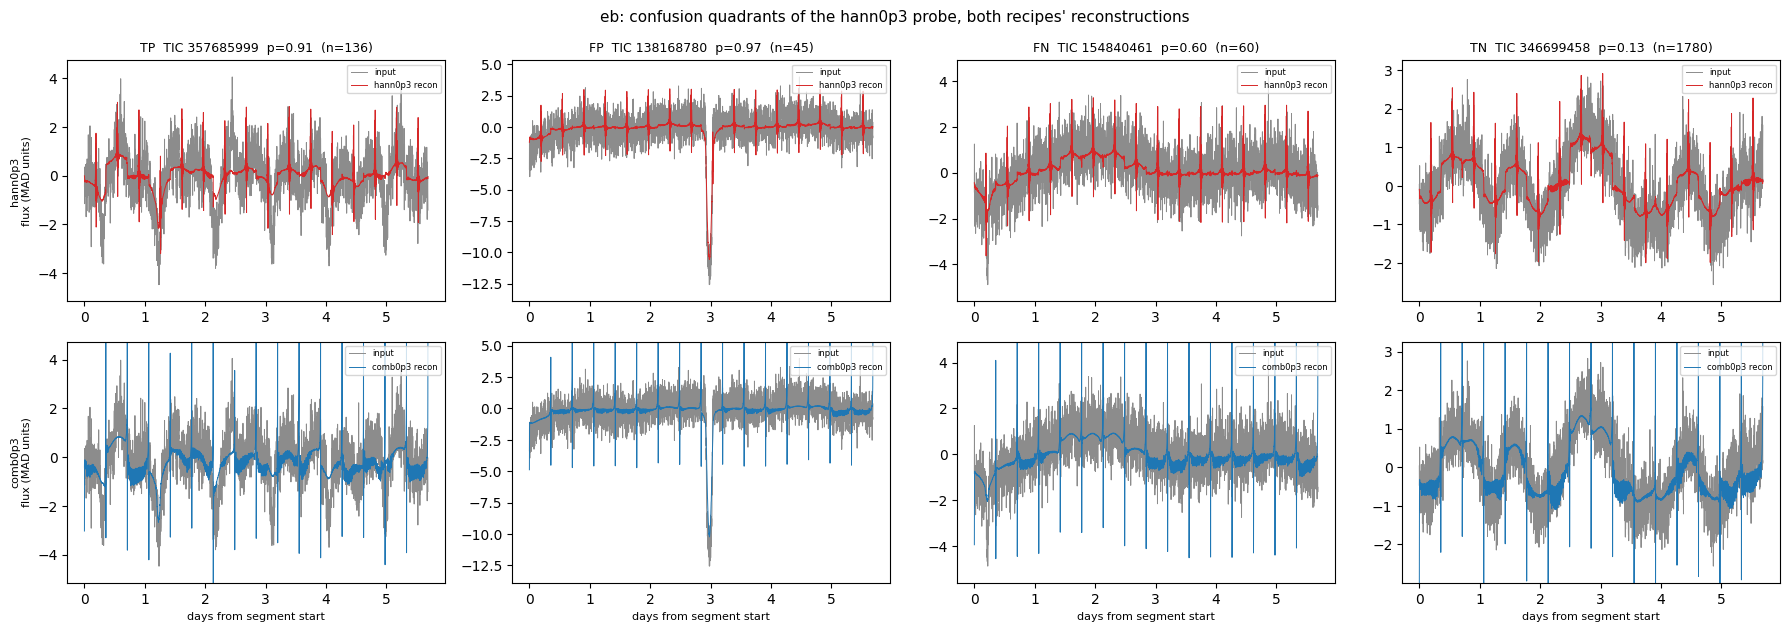

In [37]:
show_quadrants("eb")

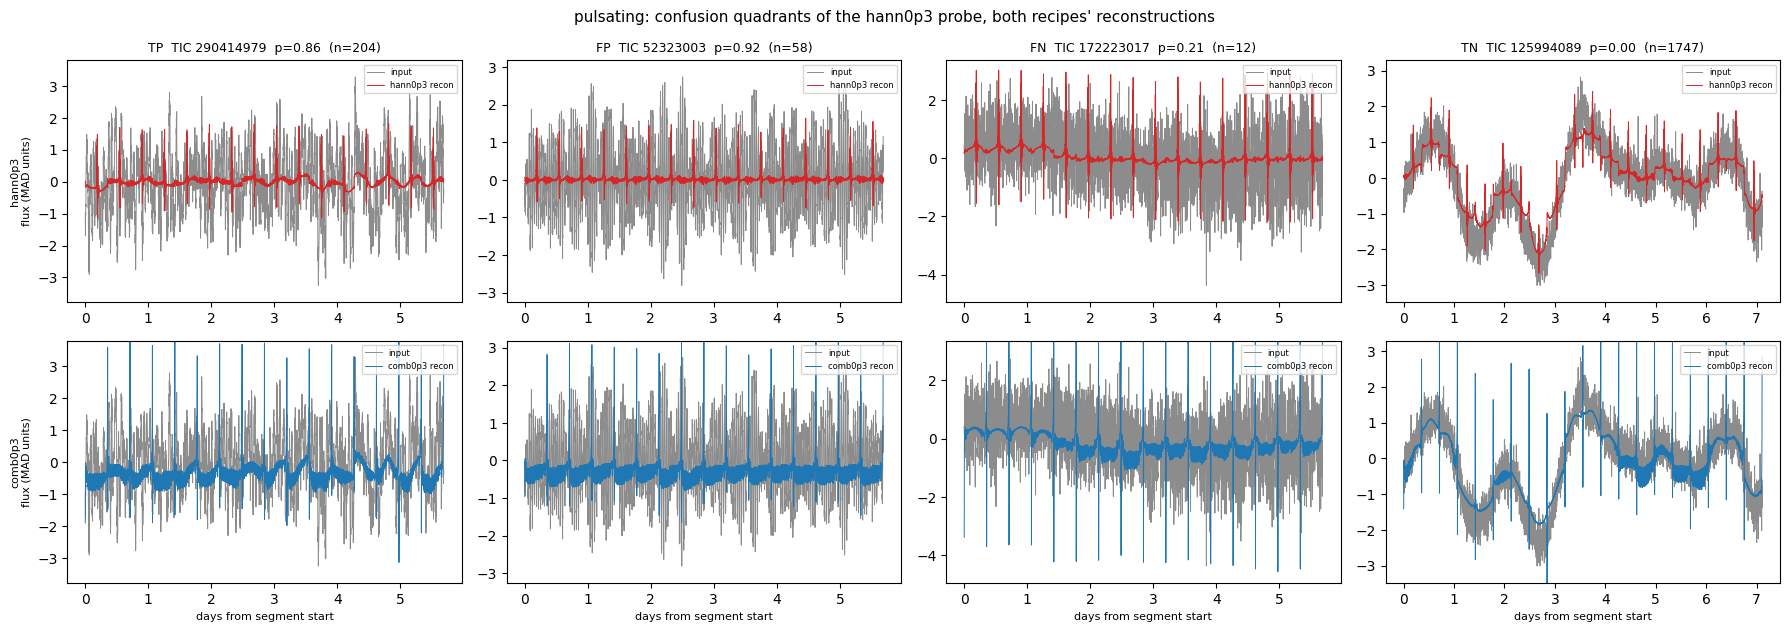

In [38]:
show_quadrants("pulsating")

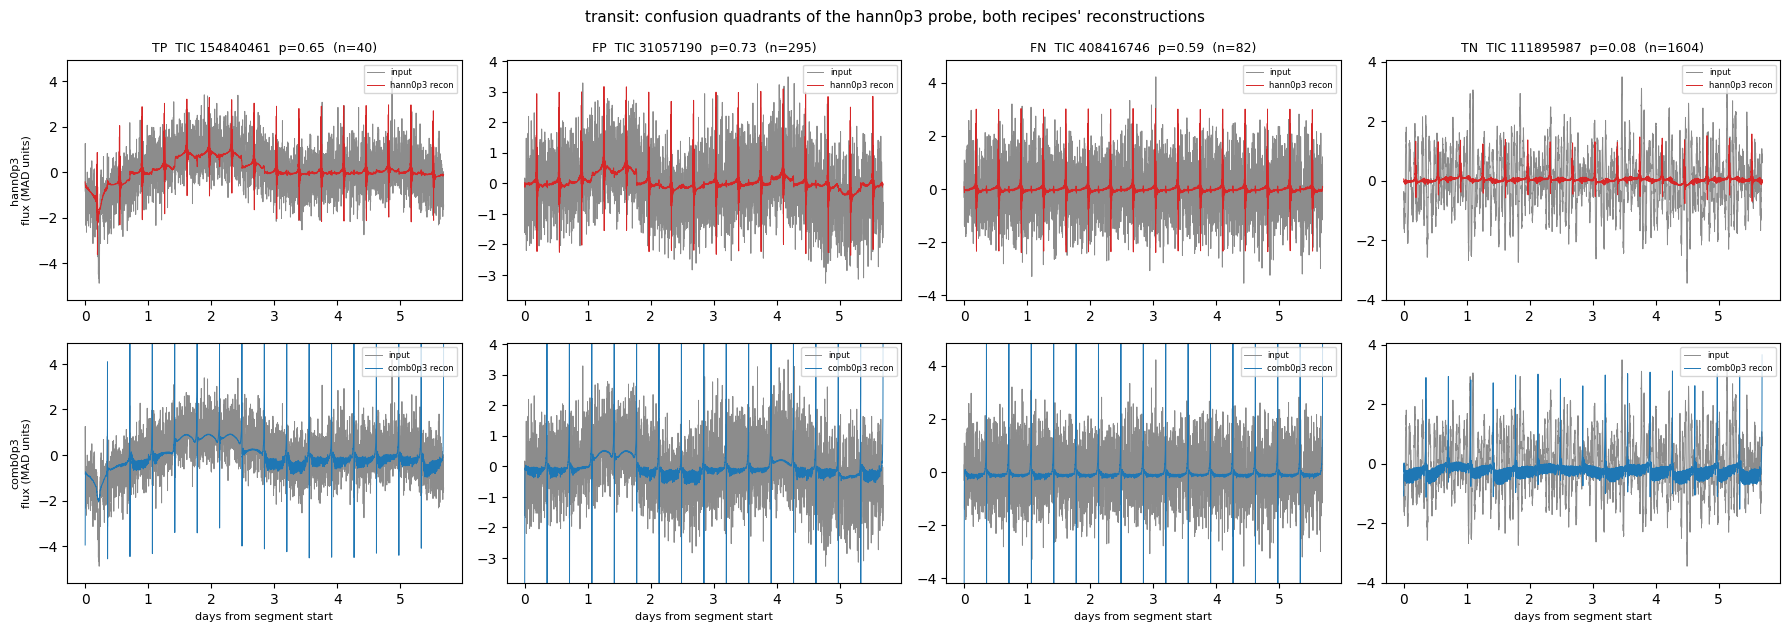

In [39]:
show_quadrants("transit")

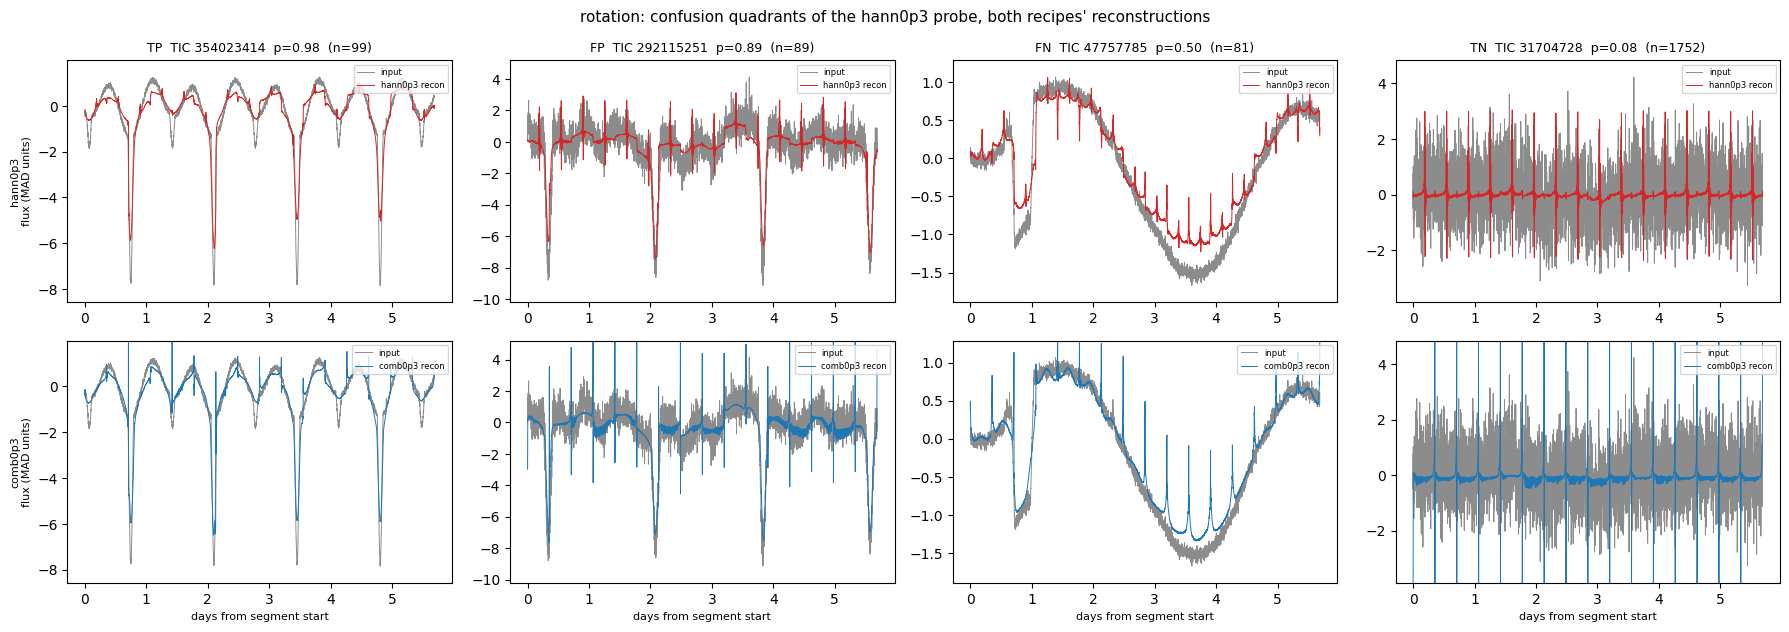

In [40]:
show_quadrants("rotation")

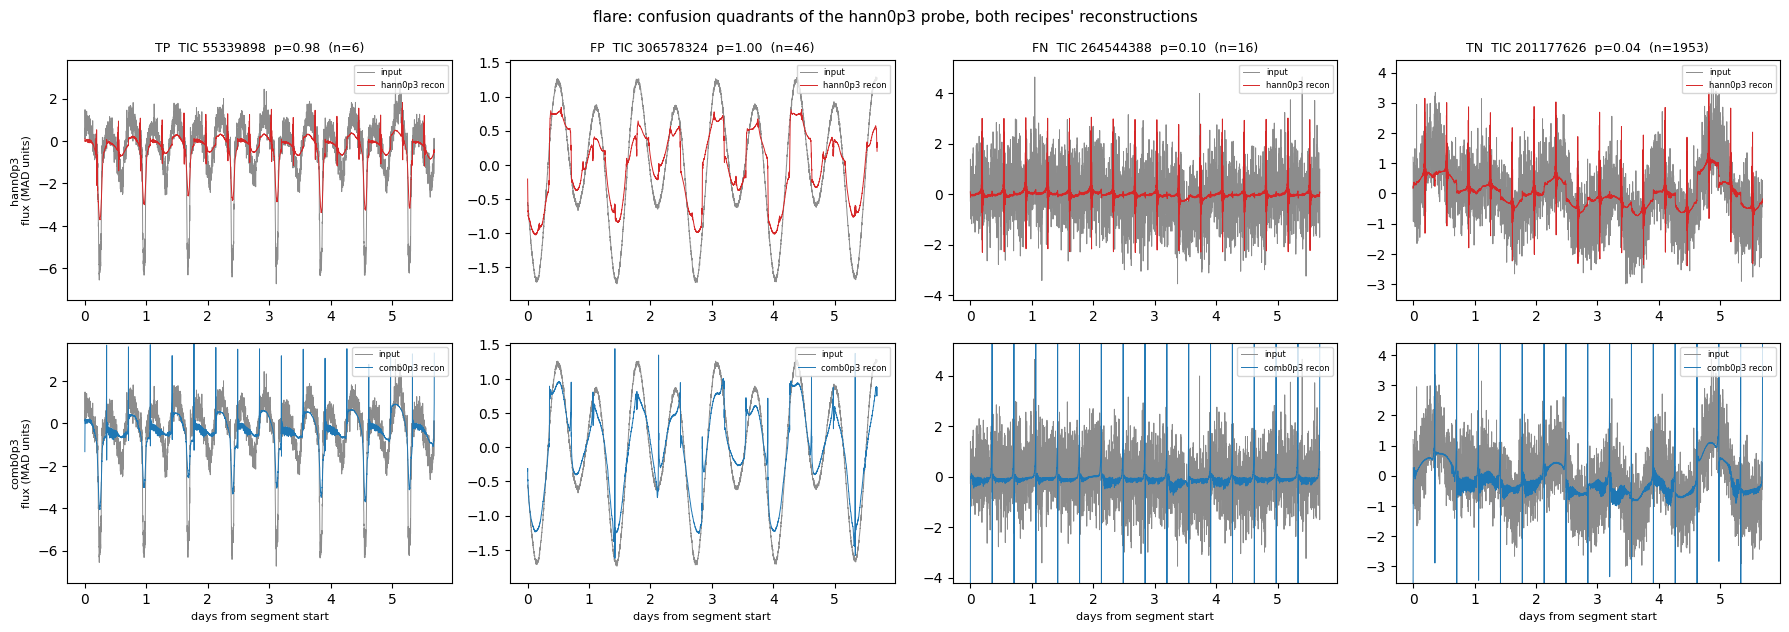

In [41]:
show_quadrants("flare")

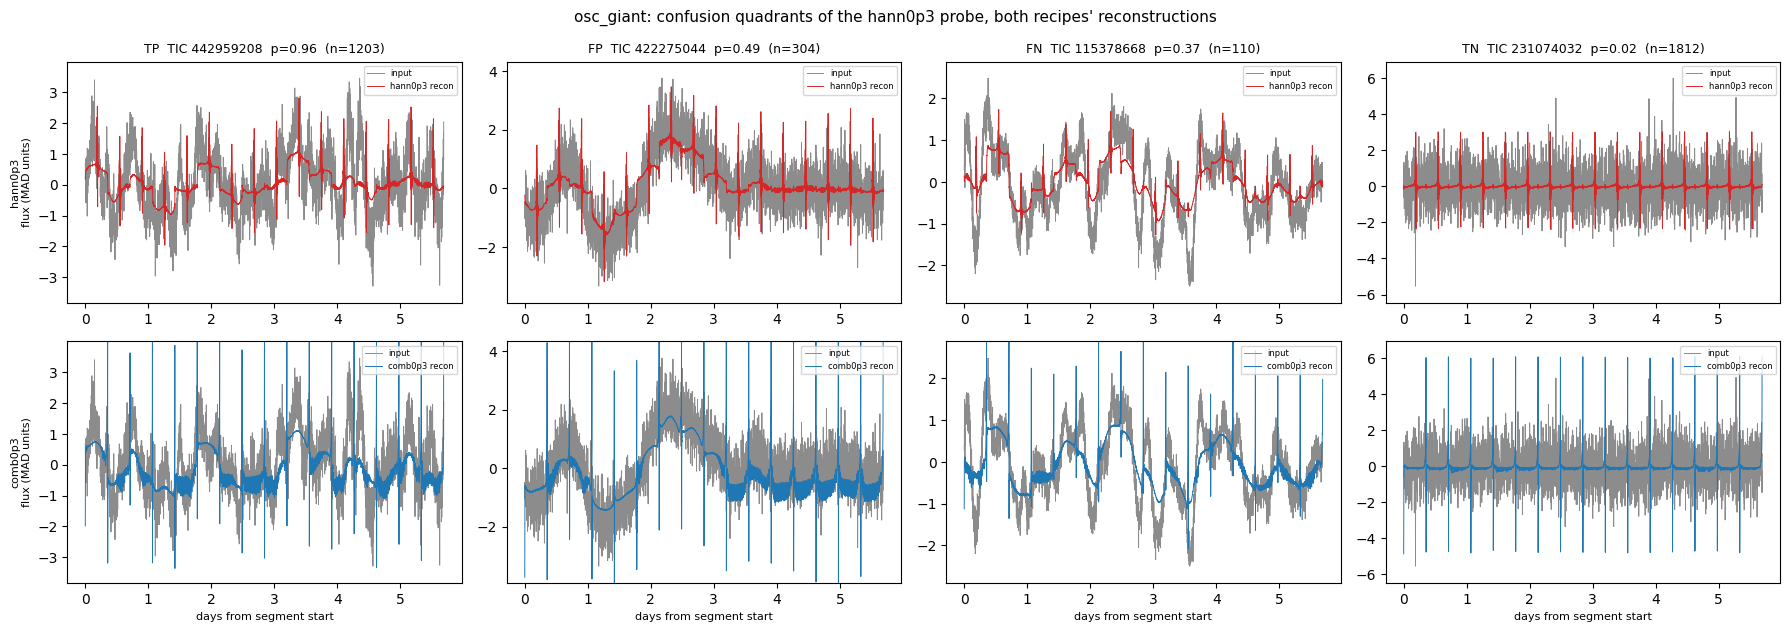

In [42]:
show_quadrants("osc_giant")

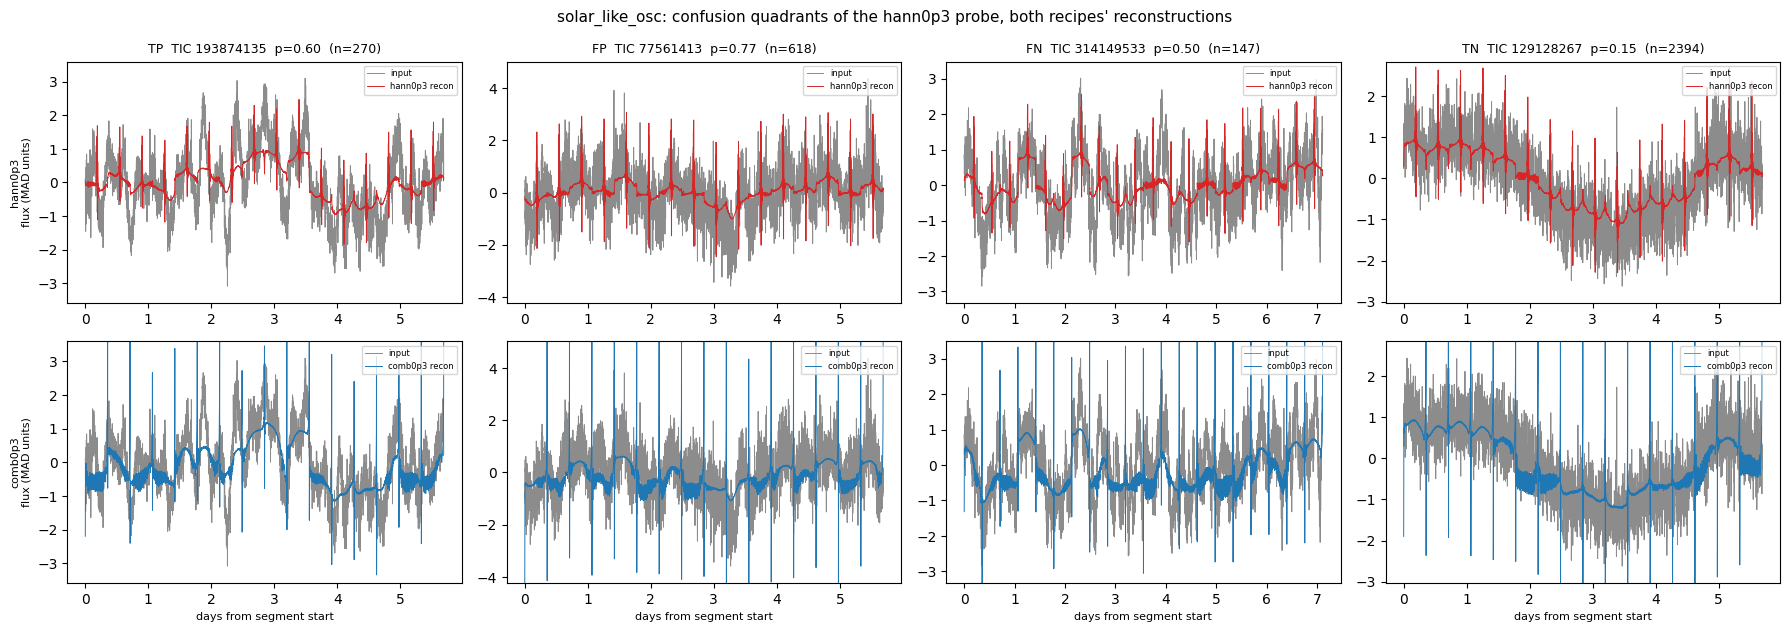

In [43]:
show_quadrants("solar_like_osc")

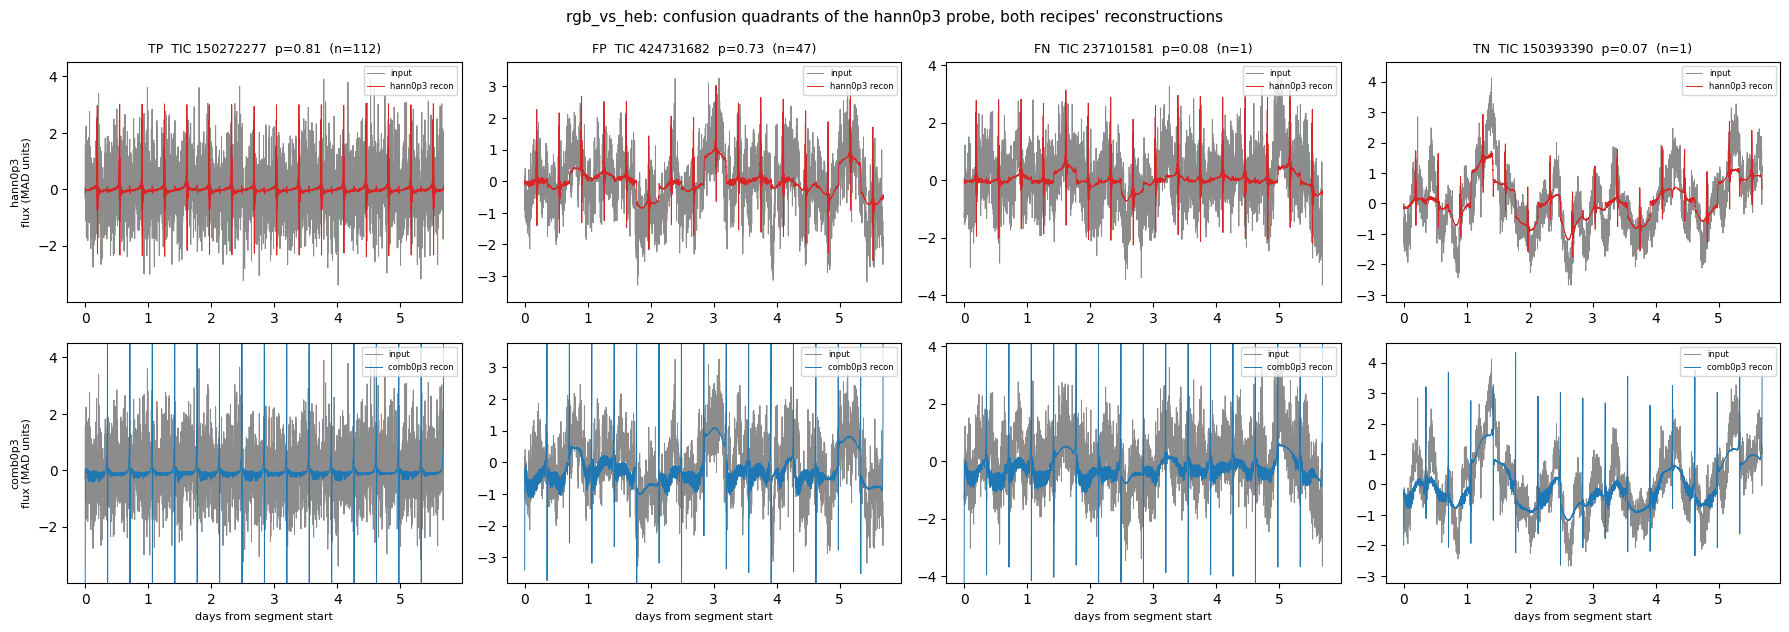

In [44]:
show_quadrants("rgb_vs_heb")

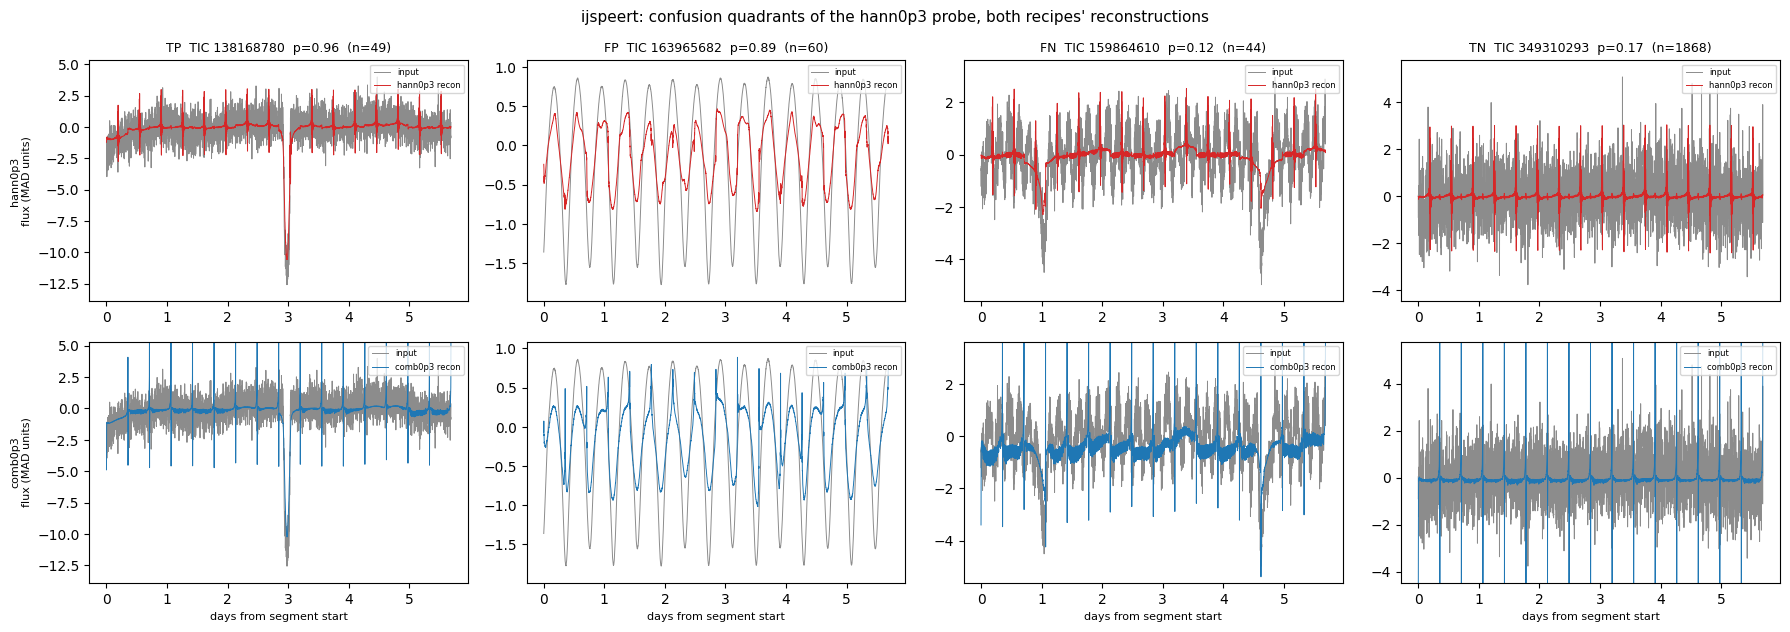

In [45]:
show_quadrants("ijspeert")

### I5. What each class looks like in the raw data

One catalogued positive against one catalogued negative for any probe in the menu, raw flux only with
no reconstruction, so this is the data before any modelling enters. For the two regression probes there
is no positive class, so the pair is drawn from the top and bottom decile of the target instead. Flux is
in units of each star's own scatter, because the pipeline MAD-normalises every segment.

Same idea as above: add a cell with `show_positive_negative("<task>")` for any of the eleven names in
`PANEL_PROBES`.

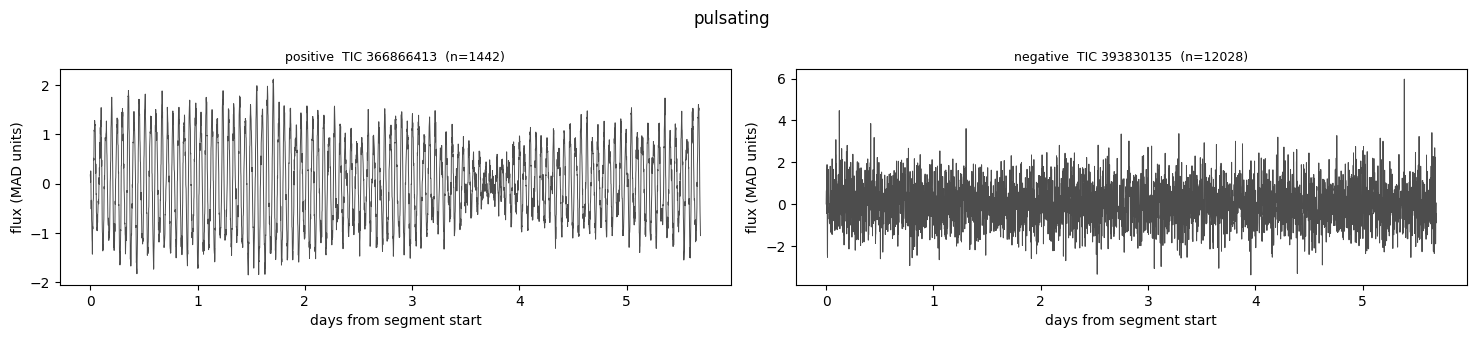

In [46]:
# I5 - one catalogued positive against one catalogued negative, raw flux
def show_positive_negative(task):
    """
    Show one positive and one negative example of a task side by side, raw flux only.
    For a regression target there is no positive class, so the pair is drawn from the top and bottom
    decile of the catalogued value, which is the closest visual equivalent.
    A different pair is drawn on every re-run, so re-execute the cell to see another example.
    """
    rng = np.random.default_rng()
    # rng = np.random.default_rng(0) # uncomment for a reproducible sample
    pool, kind = PANEL_PROBES[task]
    values = pd.to_numeric(LABELS[pool][task], errors="coerce").dropna()
    values = values[values.index.isin(available)]

    if kind == "detection":
        groups = [("positive", values[values == 1]), ("negative", values[values == 0])]
    else:
        groups = [(f"high {task}", values[values >= values.quantile(0.9)]),
                  (f"low {task}", values[values <= values.quantile(0.1)])]

    plt.figure(figsize=(15, 3.4))
    for i, (name, members) in enumerate(groups):
        plt.subplot(1, 2, i + 1)
        if members.empty:
            plt.title(f"{name}: no stars")
            plt.axis("off")
            continue
        tic = int(rng.choice(members.index.to_numpy()))
        flux, days = load_segment(tic)
        plt.plot(days, flux, color="0.3", lw=0.7)
        if kind == "detection":
            title = f"{name}  TIC {tic}  (n={len(members)})"
        else:
            title = f"{name}={float(members.loc[tic]):.2f}  TIC {tic}"
        plt.title(title, fontsize=9)
        plt.xlabel("days from segment start")
        plt.ylabel("flux (MAD units)")
    plt.suptitle(task)
    plt.tight_layout()
    plt.show()


show_positive_negative("pulsating")

## K. Cross-experiment curve forensics (exp05 / exp06 / exp07)

Section I of the exp06 notebook asked what the training curves said about exp07 and returned three rules:
never rank cells by a validation metric, calibrate lambda on a steady-state dose, never select a seed on
anything the curves show. exp07 was designed under those rules, so this section asks the next question:
now that a recipe is frozen, what do the curves of all three experiments say about **exp08**?

Two axes run through it. The first is the user-facing one: the cells that win **downstream** against the
cells that are cheapest in **loss** - both the reconstruction loss itself and the *contribution* the
dynamics term makes to it. The second is comparability, which decides what may be plotted against what.

**What is comparable across cells.** `val/recon` is the same function of the same data at a fixed window,
so it may be ranked across every cell of a geometry regardless of the aux configuration. `val/aux` and
`val/monitor_recon_aux` are **not**: exp07 varies the aux type *and* its weight, and the Hann cell changes
the aux integrand itself, so those numbers live on per-recipe scales and are only ordered inside a recipe.
Ratios to recon (`lambda*dyn/recon`, `w*aux/recon`) are dimensionless and travel further, which is why the
dose gate is written that way. Across geometries only the ratios and the shape metrics survive, because a
2048-cadence window is a different reconstruction problem from a 256-cadence one.

In [47]:
# K0 - the cross-experiment curve corpus: exp05 (ep60, 4 seeds), exp06 (ep100, 6), exp07 (ep100, 4-6)
from scipy.stats import spearmanr

DUMPS = {e: EXPS / f"{e}_forensics" / f"curves_{e}" for e in ("exp05", "exp06", "exp07")}
# One part file per encoder cell: swm.eval.mil_sweep writes only at the end, so a per-cell --out means
# an interrupted sweep loses one cell rather than all of them (experiments/run_exp07_mil_sweep.ps1).
MIL_PARTS = sorted((EXPS / "mil_pooling").glob("mil_sweep_exp07_*.csv"))
MIL_EXP05 = EXPS / "mil_pooling" / "mil_sweep.csv"         # the 2026-07-25 MIL study (exp05 encoders)
missing_k = [str(p) for p in list(DUMPS.values()) + [MIL_EXP05] if not p.exists()]
assert not missing_k, f"missing artifacts for section K: {missing_k}"
assert len(MIL_PARTS) == 4, f"expected 4 exp07 MIL part files, found {[p.name for p in MIL_PARTS]}"

WARMUP = 10          # beta_warmup_epochs in all three experiments; the argmin is restricted to epoch >= this
TAIL_FRAC = 0.7      # "steady state" = the last 30% of the run, the window the dose gate is read on

# One row per trained cell. lambda / aux / free_bits are the manifest constants, not re-derived here:
# exp06 and exp07 cells carry them in src/swm/configs/experiment/exp0{6,7}/*.yaml; the exp05 cells set
# lambda on the CLI from experiments/run_exp05_train_sweep.ps1 (the values section I of exp06 used).
CELLS = {}


def _add(cell, exp, aux, w, lam, dyn, window, fb, n_seeds):
    CELLS[cell] = dict(exp=exp, aux=aux, w=w, lam=lam, dyn=dyn, window=window, fb=fb, n_seeds=n_seeds)


for _c, _lam, _dyn in [("exp05_comb_off", 0, "off"), ("exp05_comb_fwd_c0p1", 13, "fwd"),
                       ("exp05_comb_fwd_c0p3", 40, "fwd"), ("exp05_comb_fwd_c1p0", 130, "fwd"),
                       ("exp05_comb_fbwd_c0p1", 7, "fbwd"), ("exp05_comb_fbwd_c0p3", 20, "fbwd"),
                       ("exp05_comb_fbwd_c1p0", 66, "fbwd"), ("exp05_comb_multi_c0p1", 5, "multi"),
                       ("exp05_comb_multi_c0p3", 14, "multi"), ("exp05_comb_multi_c1p0", 48, "multi")]:
    _add(_c, "exp05", "combined", 0.3, _lam, _dyn, 256, 0.0, 4)
_add("exp05_lpsd_off", "exp05", "log_psd", 0.1, 0, "off", 256, 0.02, 4)
_add("exp05_lpsd_multi_c1p0", "exp05", "log_psd", 0.1, 32, "multi", 256, 0.02, 4)
for _w, _lam in [(256, 66), (512, 18), (1024, 18)]:
    _add(f"exp06_w{_w}_fbwd", "exp06", "combined", 0.3, _lam, "fbwd", _w, 0.0, 6)
for _w in (256, 512, 1024, 2048):
    _add(f"exp06_w{_w}_off", "exp06", "combined", 0.3, 0, "off", _w, 0.0, 6)
for _rec, _aux, _w, _lam in [("comb0p3", "combined", 0.3, 60), ("comb0p1", "combined", 0.1, 60),
                             ("lpsd0p3", "log_psd", 0.3, 60), ("lpsd0p1", "log_psd", 0.1, 75),
                             ("hann0p3", "combined+hann", 0.3, 60)]:
    for _arm, _l in (("fbwd", _lam), ("off", 0)):
        _add(f"exp07_{_rec}_{_arm}", "exp07", _aux, _w, _l, _arm, 256, 0.0, len(seeds_of(_rec)))


def xcurve(cell, seed):
    """Per-epoch history for any cell of the three experiments, stitching a killed run's prefix.

    Two exp06 runs were killed and resumed by the sweep runner's retry policy and their earlier epochs
    live alongside as *.killedprefix.csv; no exp05 or exp07 run needed it, but the rule is applied
    uniformly so a future dump with a stitched run cannot silently lose its first epochs.
    """
    d = DUMPS[CELLS[cell]["exp"]]
    main = pd.read_csv(d / f"{cell}_B_seed{seed}.csv")
    prefix_path = d / f"{cell}_B_seed{seed}.killedprefix.csv"
    if prefix_path.exists():
        prefix = pd.read_csv(prefix_path)
        prefix = prefix[prefix["epoch"] < main["epoch"].min()]
        main = pd.concat([prefix, main], ignore_index=True).sort_values("epoch").reset_index(drop=True)
    return main


rows_k = []
for cell_k, meta_k in CELLS.items():
    for seed_k in range(meta_k["n_seeds"]):
        cur = xcurve(cell_k, seed_k)
        post = cur[cur["epoch"] >= WARMUP]
        sel = int(post.loc[post["val/monitor_recon_aux"].idxmin(), "epoch"])
        at = cur[cur["epoch"] == sel].iloc[0]
        tail = cur[cur["epoch"] >= TAIL_FRAC * cur["epoch"].max()]
        rows_k.append({"cell": cell_k, "seed": seed_k, **{k: meta_k[k] for k in
                       ("exp", "aux", "w", "lam", "dyn", "window", "fb")},
                       "n_ep": int(cur["epoch"].max()) + 1, "sel_epoch": sel,
                       "recon_sel": at["val/recon"], "aux_sel": at["val/aux"], "mra_sel": at["val/monitor_recon_aux"],
                       "kl_sel": at["val/kl_total"], "nact_sel": at["val/n_active_units"],
                       "nact_peak": cur[cur["epoch"] >= 5]["val/n_active_units"].max(),
                       "nact_end": cur["val/n_active_units"].iloc[-1],
                       "recon_tail": float(np.median(tail["val/recon"])),
                       "dose_tail": float(np.median(meta_k["lam"] * tail["val/dyn"] / tail["val/recon"])),
                       "auxshare_tail": float(np.median(meta_k["w"] * tail["val/aux"] / tail["val/recon"])),
                       "tv_gap_tail": float(np.median(tail["val/recon"] - tail["train/recon"])),
                       # travel still left: how far val/recon moved over the last ten epochs, signed
                       "recon_slope10": float(np.polyfit(cur["epoch"].tail(10), cur["val/recon"].tail(10), 1)[0])})
XS = pd.DataFrame(rows_k)

# Downstream scores on the same footing as everywhere else in this notebook: trained arm, mean_resid.
probe_k = (gap4[(gap4["arm"] == "trained") & (gap4["pooling"] == "mean_resid")]
           .pivot_table(index=["cell", "seed"], columns="task", values="pr_auc"))
probe_k["probe_mean"] = probe_k[TASKS].mean(axis=1)
XS = XS.merge(probe_k.reset_index(), on=["cell", "seed"], how="left")
print(f"{len(XS)} runs summarised across {XS['cell'].nunique()} cells "
      f"({', '.join(f'{e}:{n}' for e, n in XS.groupby('exp')['cell'].nunique().items())})")

138 runs summarised across 29 cells (exp05:12, exp06:7, exp07:10)


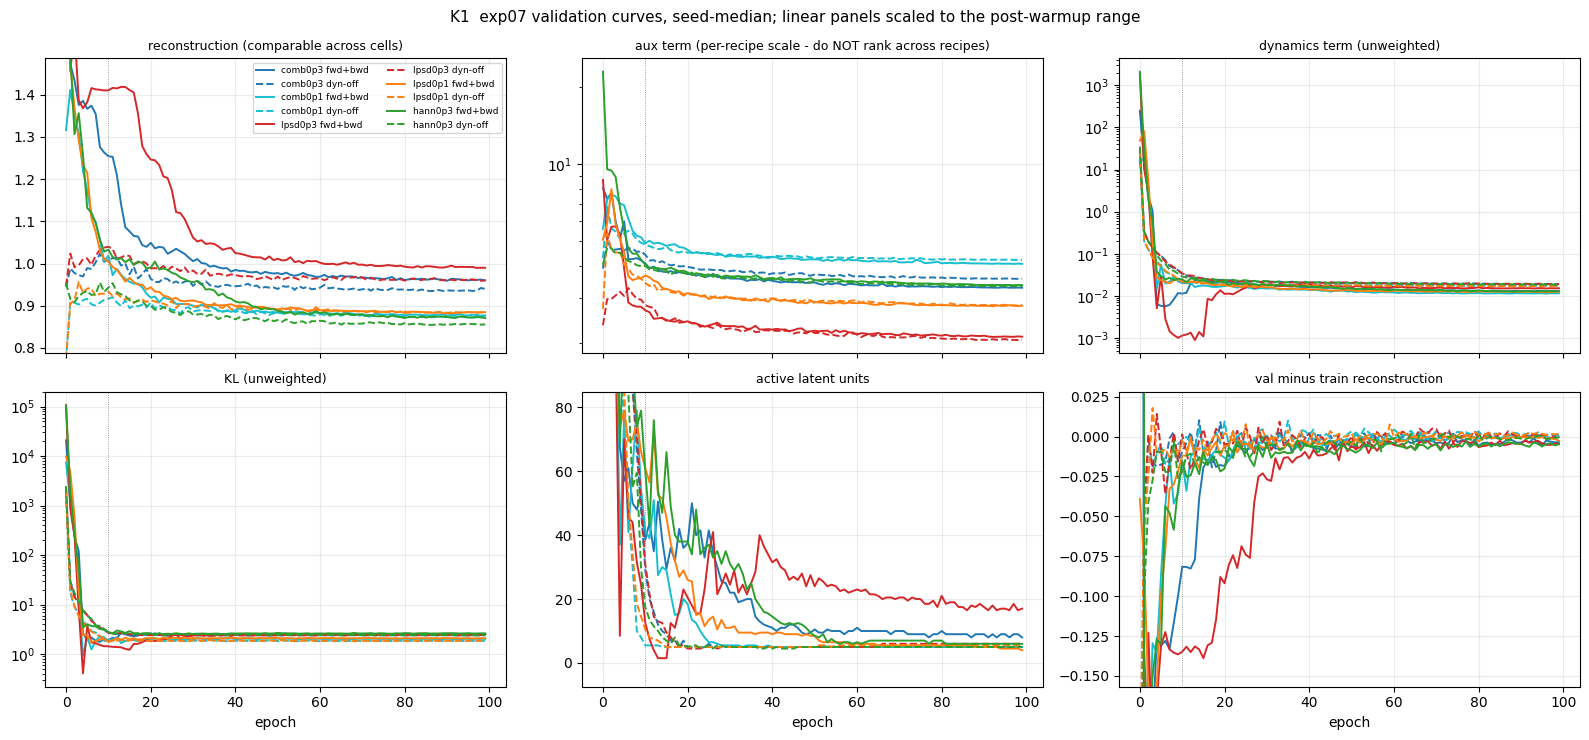

                    recon_tail  aux_sel   dose  auxshare  nact_sel  nact_peak  sel_ep  tv_gap  probe
cell                                                                                                
exp07_hann0p3_fbwd       0.876    3.384  0.931     1.166     5.833     90.167    95.5  -0.006  0.498
exp07_comb0p3_fbwd       0.965    3.299  0.843     1.033     8.167     83.167    94.5  -0.004  0.498
exp07_lpsd0p1_fbwd       0.885    2.786  1.070     0.317     5.500     97.000    81.5  -0.001  0.496
exp07_comb0p1_fbwd       0.878    4.071  0.786     0.466     5.250     81.500    95.5  -0.000  0.494
exp07_lpsd0p3_fbwd       0.994    2.122  0.910     0.645    18.250     83.500    97.0  -0.005  0.491
exp07_hann0p3_off        0.863    3.392  0.000     1.193     5.000    108.333    71.0  -0.003  0.459
exp07_lpsd0p3_off        0.961    2.086  0.000     0.657     5.500    116.750    92.5  -0.001  0.451
exp07_comb0p3_off        0.939    3.475  0.000     1.116     5.167     96.833    93.5   0.0

In [48]:
# K1 - the exp07 atlas: every logged component, seed-median, dyn-off dashed against fwd+bwd solid
FAM_COLOR = {"comb0p3": "tab:blue", "comb0p1": "tab:cyan", "lpsd0p3": "tab:red",
             "lpsd0p1": "tab:orange", "hann0p3": "tab:green"}
PANELS = [("val/recon", "reconstruction (comparable across cells)"),
          ("val/aux", "aux term (per-recipe scale - do NOT rank across recipes)"),
          ("val/dyn", "dynamics term (unweighted)"),
          ("val/kl_total", "KL (unweighted)"),
          ("val/n_active_units", "active latent units"),
          ("train_val_recon", "val minus train reconstruction")]

fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True)
for ax, (metric, title) in zip(axes.ravel(), PANELS):
    span = []   # post-warmup range, used to set the y-limits: epoch 0 is 15x the steady state and
                # would otherwise flatten every curve in the panel into one line
    for recipe in RECIPES:
        for arm, style in (("fbwd", "-"), ("off", "--")):
            cell = cell_name(recipe, arm)
            frames = [xcurve(cell, s).set_index("epoch") for s in seeds_of(recipe)]
            if metric == "train_val_recon":
                series = [f["val/recon"] - f["train/recon"] for f in frames]
            else:
                series = [f[metric] for f in frames]
            med = pd.concat(series, axis=1).median(axis=1)
            ax.plot(med.index, med.values, style, color=FAM_COLOR[recipe], lw=1.4,
                    label=f"{recipe} {ARMS[arm]}" if metric == "val/recon" else None)
            span.append(med[med.index >= WARMUP])
    ax.set_title(title, fontsize=9)
    ax.axvline(WARMUP, color="grey", lw=0.6, ls=":")
    ax.grid(alpha=0.25)
    if metric in ("val/aux", "val/dyn", "val/kl_total"):
        ax.set_yscale("log")
    else:
        lo, hi = min(s.min() for s in span), max(s.max() for s in span)
        pad = 0.12 * (hi - lo) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)
for ax in axes[1]:
    ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=6.5, ncol=2)
fig.suptitle("K1  exp07 validation curves, seed-median; linear panels scaled to the post-warmup range",
             fontsize=11)
fig.tight_layout(); plt.show()

sel_tab = (XS[XS.exp == "exp07"].groupby("cell")
           .agg(recon_tail=("recon_tail", "mean"), aux_sel=("aux_sel", "mean"),
                dose=("dose_tail", "mean"), auxshare=("auxshare_tail", "mean"),
                nact_sel=("nact_sel", "mean"), nact_peak=("nact_peak", "mean"),
                sel_ep=("sel_epoch", "median"), tv_gap=("tv_gap_tail", "mean"),
                probe=("probe_mean", "mean")).round(3))
print(sel_tab.sort_values("probe", ascending=False).to_string())

#### Plain-English read of K1

Four things the atlas settles before any ranking is attempted.

**The aux panel is on five different scales**, which is exactly why it may not be ranked across recipes:
the value at the selected checkpoint spans 2.1-4.2 and its ordering does not follow the weight
(`lpsd0p3` sits lowest at 2.1, `comb0p1` highest at 4.1), because the type sets the scale and the weight
only sets how hard it is pulled on. `hann0p3`'s integrand is a different function again. The reconstruction
panel, by contrast, is one function of one dataset for all ten cells, and it is the only loss axis this
section ranks on.

**Nothing overfits.** At steady state `val - train` reconstruction is between -0.006 and +0.002 for every
cell, with the dynamics-on cells slightly *below* zero - the dynamics term acting as a regulariser on the
encoder, not the classic overfit signature. The panel's only real structure is a transient: while the
latent is still pruning (roughly epochs 10-40) the dynamics-on cells run val **below** train by as much as
0.13, most strongly in `lpsd0p3_fbwd`, and it closes as the active set settles. A longer schedule would not
be stopped by generalisation at this geometry.

**Everything is flat by epoch 80.** The last-ten-epoch slope of `val/recon` is between -0.0003 and +0.0002
per epoch for all ten cells - three to four orders of magnitude below the between-cell spread. Whatever
exp08 needs, more epochs is not it.

**The active-unit panel is the one place the recipes genuinely separate**, and not in the direction the
exp05 mechanism story predicts: `lpsd0p3_fbwd` holds 18 units while the winner holds 6. That thread is
picked up in K6.

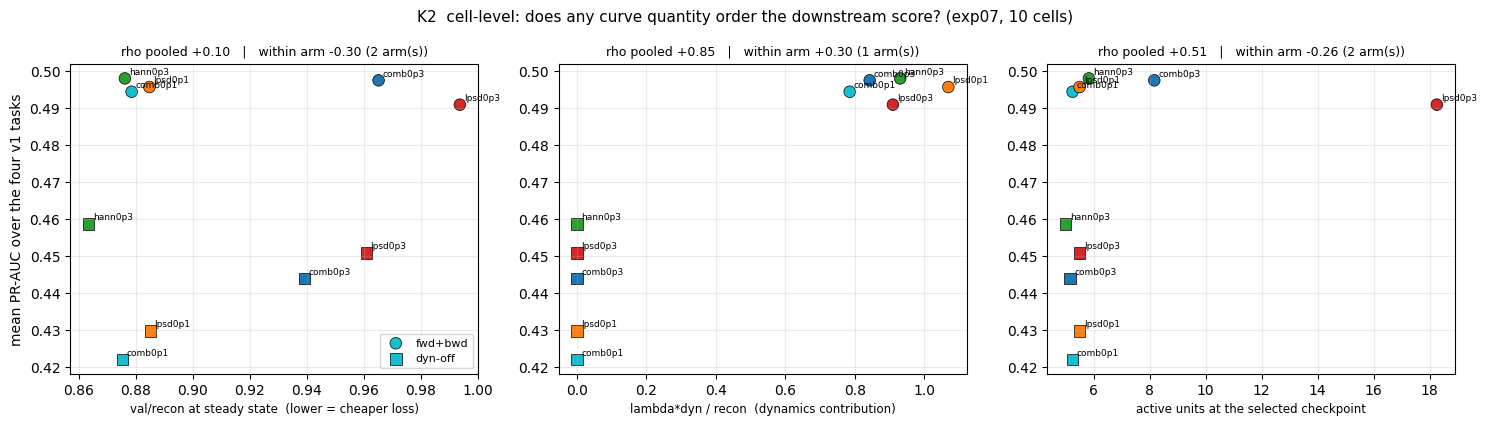

Spearman rho against PR-AUC: pooled over all 10 cells, and inside a dyn arm (5 cells each)
  recon     pooled tran +0.20 eb +0.32 puls -0.21 rota +0.38   | within-arm (2) tran -0.05 eb +0.30 puls -0.45 rota +0.40
  mra       pooled tran +0.35 eb +0.07 puls +0.01 rota +0.08   | within-arm (2) tran +0.70 eb +0.25 puls +0.15 rota +0.30
  dose      pooled tran +0.81 eb +0.68 puls +0.68 rota +0.90   | within-arm (1) tran +0.30 eb -1.00 puls -0.10 rota +0.70
  auxshare  pooled tran +0.35 eb -0.10 puls +0.12 rota -0.05   | within-arm (2) tran +0.85 eb +0.10 puls +0.35 rota +0.20
  nact      pooled tran +0.61 eb +0.54 puls +0.07 rota +0.62   | within-arm (2) tran +0.09 eb +0.05 puls -0.73 rota +0.08


In [49]:
# K2 - the two "cheapest loss" axes, and what they rank: reconstruction, and the dynamics contribution
e7 = XS[XS.exp == "exp07"].copy()
cell_lvl = e7.groupby("cell").agg(recon=("recon_tail", "mean"), dose=("dose_tail", "mean"),
                                  auxshare=("auxshare_tail", "mean"), nact=("nact_sel", "mean"),
                                  mra=("mra_sel", "mean"), probe=("probe_mean", "mean"),
                                  **{t: (t, "mean") for t in TASKS})
cell_lvl["arm"] = ["fbwd" if c.endswith("fbwd") else "off" for c in cell_lvl.index]


def rho_within(metric, target):
    """Spearman inside each dyn arm, averaged over the arms where the metric actually varies.

    The dose is identically zero on every dyn-off cell, so a pooled correlation with it is the dynamics
    arm in disguise (the F21 trap) and an off-arm correlation is undefined - such arms are skipped and
    the count of contributing arms is returned alongside.
    """
    vals = []
    for arm in ("fbwd", "off"):
        sub = cell_lvl[cell_lvl.arm == arm]
        if sub[metric].nunique() < 3:
            continue
        vals.append(spearmanr(sub[metric], sub[target]).statistic)
    return (float(np.mean(vals)) if vals else np.nan), len(vals)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (xcol, xlabel) in zip(axes, [("recon", "val/recon at steady state  (lower = cheaper loss)"),
                                     ("dose", "lambda*dyn / recon  (dynamics contribution)"),
                                     ("nact", "active units at the selected checkpoint")]):
    for arm, marker in (("fbwd", "o"), ("off", "s")):
        sub = cell_lvl[cell_lvl.arm == arm]
        ax.scatter(sub[xcol], sub["probe"], marker=marker, s=70,
                   c=[FAM_COLOR[c.split("_")[1]] for c in sub.index],
                   edgecolor="k", linewidth=0.5, label=ARMS[arm])
        for c, r in sub.iterrows():
            ax.annotate(c.split("_")[1], (r[xcol], r["probe"]), fontsize=6.5,
                        xytext=(3, 3), textcoords="offset points")
    rho_all = spearmanr(cell_lvl[xcol], cell_lvl["probe"]).statistic
    rho_in, n_arms = rho_within(xcol, "probe")
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_title(f"rho pooled {rho_all:+.2f}   |   within arm {rho_in:+.2f} ({n_arms} arm(s))", fontsize=9)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("mean PR-AUC over the four v1 tasks")
axes[0].legend(fontsize=8)
fig.suptitle("K2  cell-level: does any curve quantity order the downstream score? (exp07, 10 cells)", fontsize=11)
fig.tight_layout(); plt.show()

print("Spearman rho against PR-AUC: pooled over all 10 cells, and inside a dyn arm (5 cells each)")
for metric in ["recon", "mra", "dose", "auxshare", "nact"]:
    pooled = {t: spearmanr(cell_lvl[metric], cell_lvl[t]).statistic for t in TASKS}
    within = {t: rho_within(metric, t)[0] for t in TASKS}
    n_arms = rho_within(metric, TASKS[0])[1]
    print(f"  {metric:9s} pooled " + " ".join(f"{t[:4]} {pooled[t]:+.2f}" for t in TASKS) +
          f"   | within-arm ({n_arms}) " + " ".join(f"{t[:4]} {within[t]:+.2f}" for t in TASKS))

#### Plain-English read of K2

**The dynamics dose looks like a near-perfect predictor and is not one.** Pooled over all ten cells its
correlation with the probe score is +0.68 to +0.90 depending on the task - but the dose is exactly zero for
all five dyn-off cells and positive for all five fwd+bwd cells, so the pooled number is the dynamics arm
wearing a continuous disguise. It cannot even be computed inside the dyn-off arm, and inside the fwd+bwd
arm, where it genuinely varies (0.79-1.07), it is uninformative. This is the same pooled-versus-within trap
F21 caught on the edge axis, which is why the panel titles carry both numbers and the count of arms that
could contribute one.

**Reconstruction loss still does not pick winners, and on the two tasks with the largest dynamics gains it
anti-picks them.** Cheaper recon goes with *worse* eb (rho +0.32 pooled, +0.30 within arm) and *worse*
rotation (+0.38 / +0.40) - the sign that has held since exp05's rho -0.58...-0.84. Pulsating is the one
task that leans the other way (-0.21 pooled, -0.45 within arm), and it is also the one task the aux term
works on directly.

**Active units at selection are not the mechanism either.** `lpsd0p3_fbwd` holds 18.25 units, more than
three times the winner's 5.8, and scores mid-table; within an arm more units go with *worse* pulsating
(rho -0.73, five cells, carried by that one outlier). The exp05 reading - dynamics wins by reversing
collapse, 5 units to 25 - does not survive at ep100 in either direction: the winner recruits almost
nothing and wins anyway (K5).

**What is left standing is the arm itself.** Every fwd+bwd cell beats every dyn-off cell on the mean score
(0.491-0.498 against 0.422-0.459), with no overlap and no dependence on which aux term produced it. At this
geometry the dynamics term is a binary asset, not a dial: past the dose gate, how much of it you buy does
not matter.

Four encoders, three readouts and two loss axes (4 seeds each; untrained arm is the shared reference):
                    mil_test  mean_test   recon    dose    nact  mean_resid
cell                                                                       
exp07_hann0p3_fbwd    0.5921     0.5700  0.8761  0.9309  5.8333      0.4981
exp07_comb0p3_fbwd    0.5791     0.5691  0.9651  0.8432  8.1667      0.4975
exp07_hann0p3_off     0.5606     0.5548  0.8634  0.0000  5.0000      0.4587
exp07_comb0p3_off     0.5589     0.5430  0.9391  0.0000  5.1667      0.4440
untrained             0.5308     0.5230     NaN     NaN     NaN         NaN

rho(val/recon, MIL winner) = +0.00   rho(val/recon, mean pooling) = +0.00   rho(MIL, mean_resid) = +1.00

what the pooling operator buys over mean pooling, per task:
task                    eb  pulsating  rotation  transit     ALL
cell                                                            
exp07_comb0p3_fbwd -0.0097     0.0039   -0.0339   0.0797  0.0100
exp

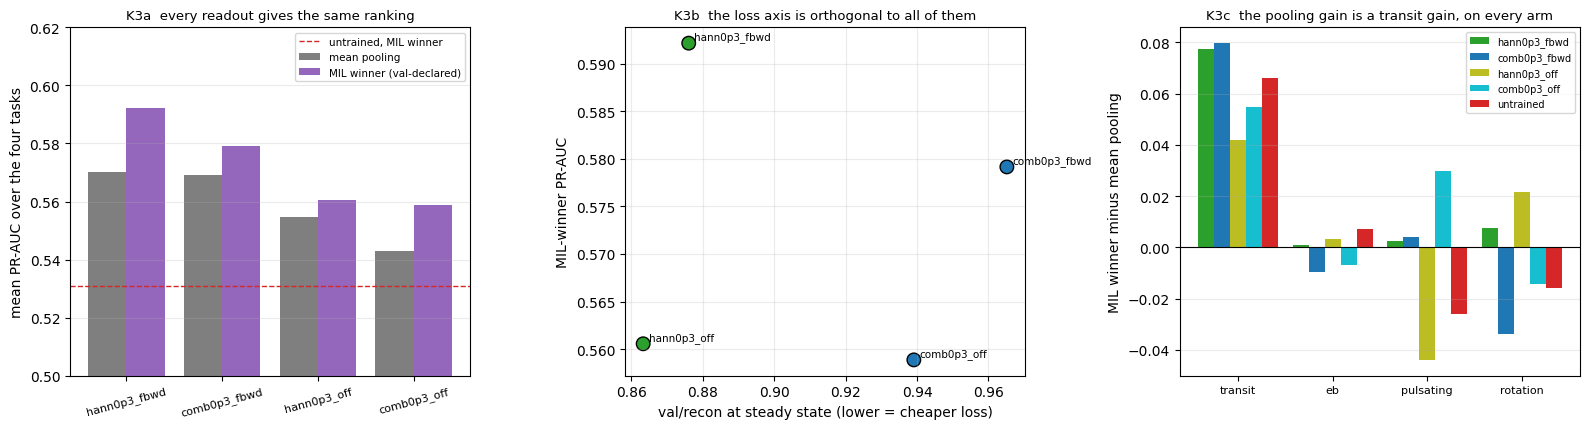

In [50]:
# K3 - the user's axis: the encoders that win under the winning MIL operator vs the ones cheapest in loss
# Every part file also carries the shared untrained arm; keep one copy of it.
mil7 = pd.concat([pd.read_csv(p) for p in MIL_PARTS], ignore_index=True)
mil7 = mil7.drop_duplicates(subset=["exp_name", "seed", "task", "pooling", "param", "kmatch_draw"])

mil_rows = []
for (cell_m, seed_m, task_m), sub in mil7.groupby(["exp_name", "seed", "task"]):
    # mil_sweep protocol: fit on train, DECLARE the operator on val, report test. Never pick on test.
    best = sub.loc[sub["pr_auc_val"].idxmax()]
    mil_rows.append({"cell": cell_m, "seed": int(seed_m), "task": task_m, "op": best["pooling"],
                     "mil_test": best["pr_auc_test"],
                     "mean_test": float(sub[sub["pooling"] == "mean"]["pr_auc_test"].max())})
MIL = pd.DataFrame(mil_rows)

mil_cell = MIL.groupby("cell")[["mil_test", "mean_test"]].mean()
mil_cell = mil_cell.join(XS.groupby("cell").agg(recon=("recon_tail", "mean"), dose=("dose_tail", "mean"),
                                                nact=("nact_sel", "mean"), mean_resid=("probe_mean", "mean")))
mil_cell = mil_cell.sort_values("mil_test", ascending=False)
print("Four encoders, three readouts and two loss axes (4 seeds each; untrained arm is the shared reference):")
print(mil_cell.round(4).to_string())
trained = mil_cell.drop("untrained")
print(f"\nrho(val/recon, MIL winner) = {spearmanr(trained['recon'], trained['mil_test']).statistic:+.2f}"
      f"   rho(val/recon, mean pooling) = {spearmanr(trained['recon'], trained['mean_test']).statistic:+.2f}"
      f"   rho(MIL, mean_resid) = {spearmanr(trained['mil_test'], trained['mean_resid']).statistic:+.2f}")

delta = (MIL.pivot_table(index="cell", columns="task", values="mil_test")
         - MIL.pivot_table(index="cell", columns="task", values="mean_test"))
delta["ALL"] = delta.mean(axis=1)
print("\nwhat the pooling operator buys over mean pooling, per task:")
print(delta.round(4).to_string())
print("\nhow many distinct operators win across the 4 seeds (val-declared):")
print(MIL.groupby(["cell", "task"])["op"].nunique().unstack().to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
order = [c for c in mil_cell.index if c != "untrained"]
x = np.arange(len(order))
axes[0].bar(x - 0.2, mil_cell.loc[order, "mean_test"], 0.4, label="mean pooling", color="tab:grey")
axes[0].bar(x + 0.2, mil_cell.loc[order, "mil_test"], 0.4, label="MIL winner (val-declared)", color="tab:purple")
axes[0].axhline(mil_cell.loc["untrained", "mil_test"], color="tab:red", ls="--", lw=1,
                label="untrained, MIL winner")
axes[0].set_xticks(x); axes[0].set_xticklabels([c.replace("exp07_", "") for c in order], rotation=15, fontsize=8)
axes[0].set_ylim(0.5, 0.62); axes[0].set_ylabel("mean PR-AUC over the four tasks")
axes[0].legend(fontsize=7.5); axes[0].grid(alpha=0.25, axis="y")
axes[0].set_title("K3a  every readout gives the same ranking", fontsize=9.5)

axes[1].scatter(trained["recon"], trained["mil_test"], s=95, marker="o", edgecolor="k",
                c=["tab:green" if "hann" in c else "tab:blue" for c in trained.index])
for c, r in trained.iterrows():
    axes[1].annotate(c.replace("exp07_", ""), (r["recon"], r["mil_test"]), fontsize=7.5,
                     xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("val/recon at steady state (lower = cheaper loss)")
axes[1].set_ylabel("MIL-winner PR-AUC")
axes[1].set_title("K3b  the loss axis is orthogonal to all of them", fontsize=9.5)
axes[1].grid(alpha=0.25)

tasks_x = np.arange(len(TASKS))
BAR_COLOR = {"exp07_hann0p3_fbwd": "tab:green", "exp07_comb0p3_fbwd": "tab:blue",
             "exp07_hann0p3_off": "tab:olive", "exp07_comb0p3_off": "tab:cyan",
             "untrained": "tab:red"}   # untrained must be unmistakable: it is the point of the panel
for i, cell_m in enumerate(order + ["untrained"]):
    axes[2].bar(tasks_x + (i - 2) * 0.17, delta.loc[cell_m, TASKS], 0.17,
                label=cell_m.replace("exp07_", ""), color=BAR_COLOR[cell_m])
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xticks(tasks_x); axes[2].set_xticklabels(TASKS, fontsize=8)
axes[2].set_ylabel("MIL winner minus mean pooling")
axes[2].set_title("K3c  the pooling gain is a transit gain, on every arm", fontsize=9.5)
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.25, axis="y")
fig.tight_layout(); plt.show()

#### Plain-English read of K3

This is the panel the section was requested for: the encoder that wins **under the winning MIL operator**
against the encoder that is **cheapest in loss**. Four exp07 encoders were given bag caches and put through
the full pooling sweep for it (`swm.eval.mil_cache` + `experiments/run_exp07_mil_sweep.ps1`), on the same
protocol as the 2026-07-25 study: fit on train, declare the operator on **val**, report test, and score the
capacity-matched untrained arm the same way.

**The answer to "are the winners very different in config?" is: they are not different at all, and the
loss axis is the thing that disagrees.** MIL-winner, mean-pooling and this notebook's `mean_resid` all
return the identical ranking - `hann0p3_fbwd` 0.592, `comb0p3_fbwd` 0.579, `hann0p3_off` 0.561,
`comb0p3_off` 0.559 - while `val/recon` ranks the same four cells 0.863 / 0.876 / 0.939 / 0.965, i.e. the
cheapest-loss cell third and the most expensive one second. Spearman between the loss and either readout is
exactly **0.00**. The one configuration difference every readout agrees on is the dynamics arm; the aux
form moves the ranking by less than the gap between the arms.

**What pooling buys is a transit effect, and it is mostly not the encoder's.** Averaged over the four
tasks the MIL winner beats mean pooling by only +0.006...+0.022, and the per-task decomposition shows why:
transit +0.042...+0.080 everywhere, eb ~0, rotation and pulsating scattered around zero and negative as
often as not. The **untrained** arm gains +0.066 on transit from the same operator - so most of the
localized-task gain is the operator finding a sparse signal in *any* window representation, which is
exactly the ADR-0008-lite framing (MIL for localized tasks only) and exactly why an operator must be
chosen on absolute score rather than on a trained-minus-untrained gap.

**"The winning MIL method" is not one method, and at this val size it is not even stable.** Across four
seeds of one cell the val-declared winner changes identity up to four times, and the winners span feature
space (`rff_meanmap`, `mean_std`, `gmm_prototype`) as well as score space (`ws_ppv_lspv`, `ws_topk`). Any
adoption decision (Q6) has to state a fixed operator per task rather than "the best one", or it will be
reporting val-selection noise.

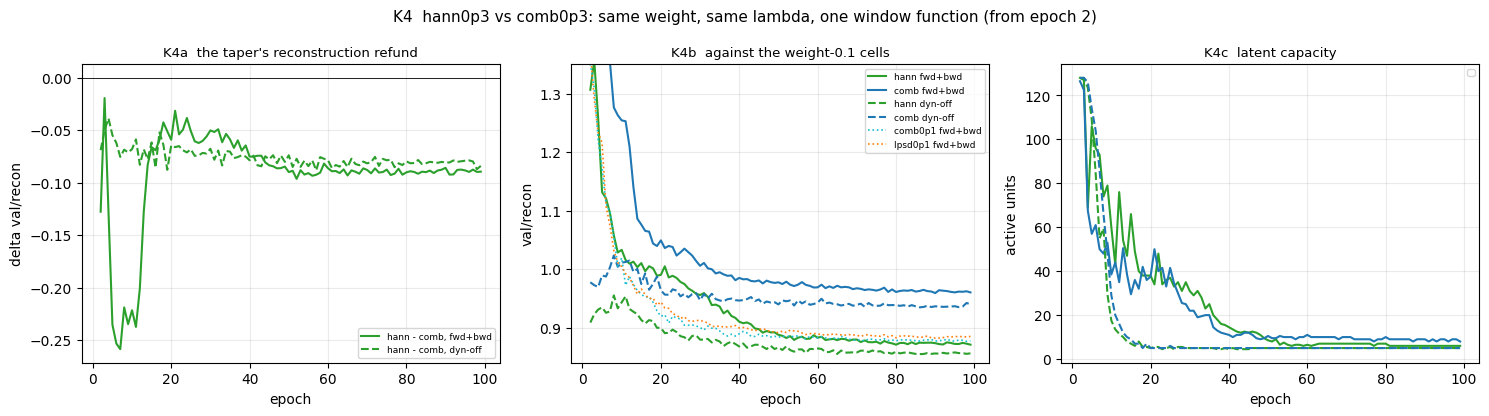

                     recon  recon_sd    nact  pulsating   probe
cell                                                           
exp07_hann0p3_fbwd  0.8761    0.0126  5.8333     0.8073  0.4981
exp07_hann0p3_off   0.8634    0.0074  5.0000     0.8016  0.4587
exp07_comb0p3_fbwd  0.9651    0.0091  8.1667     0.7887  0.4975
exp07_comb0p3_off   0.9391    0.0094  5.1667     0.7578  0.4440
exp07_comb0p1_fbwd  0.8785    0.0026  5.2500     0.8128  0.4945
exp07_comb0p1_off   0.8753    0.0045  5.2500     0.7048  0.4220
exp07_lpsd0p1_fbwd  0.8847    0.0042  5.5000     0.8025  0.4957
exp07_lpsd0p1_off   0.8851    0.0027  5.5000     0.7329  0.4297

taper refund on val/recon (fwd+bwd): +0.0890 (9.2% of comb0p3's reconstruction)


In [51]:
# K4 - hann against comb, epoch by epoch: what the taper actually changed in the loss
# Panels a/b start at epoch 2: the epoch-0/1 values are 8-16x the steady state (KL warmup) and hide
# the effect entirely. The transient itself is reported in A2, not here.
FROM_EP = 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for arm, style in (("fbwd", "-"), ("off", "--")):
    h = [xcurve(cell_name("hann0p3", arm), s).set_index("epoch") for s in seeds_of("hann0p3")]
    c = [xcurve(cell_name("comb0p3", arm), s).set_index("epoch") for s in seeds_of("comb0p3")]
    keys = ("val/recon", "val/n_active_units")
    hm = {k: pd.concat([f[k] for f in h], axis=1).median(axis=1).loc[FROM_EP:] for k in keys}
    cm = {k: pd.concat([f[k] for f in c], axis=1).median(axis=1).loc[FROM_EP:] for k in keys}
    axes[0].plot(hm["val/recon"].index, hm["val/recon"] - cm["val/recon"], style, color="tab:green",
                 label=f"hann - comb, {ARMS[arm]}")
    axes[1].plot(hm["val/recon"].index, hm["val/recon"], style, color="tab:green", label=f"hann {ARMS[arm]}")
    axes[1].plot(cm["val/recon"].index, cm["val/recon"], style, color="tab:blue", label=f"comb {ARMS[arm]}")
    axes[2].plot(hm["val/n_active_units"].index, hm["val/n_active_units"], style, color="tab:green")
    axes[2].plot(cm["val/n_active_units"].index, cm["val/n_active_units"], style, color="tab:blue")
# the weight-0.1 cells mark where "less aux pressure" alone would put the reconstruction
for rec, col in (("comb0p1", "tab:cyan"), ("lpsd0p1", "tab:orange")):
    ref = pd.concat([xcurve(cell_name(rec, "fbwd"), s).set_index("epoch")["val/recon"]
                     for s in seeds_of(rec)], axis=1).median(axis=1).loc[FROM_EP:]
    axes[1].plot(ref.index, ref.values, ":", color=col, lw=1.2, label=f"{rec} fwd+bwd")
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_ylabel("delta val/recon")
axes[0].set_title("K4a  the taper's reconstruction refund", fontsize=9.5)
axes[1].set_ylabel("val/recon"); axes[1].set_ylim(0.84, 1.35)
axes[1].set_title("K4b  against the weight-0.1 cells", fontsize=9.5)
axes[2].set_ylabel("active units"); axes[2].set_title("K4c  latent capacity", fontsize=9.5)
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25); ax.legend(fontsize=6.5)
fig.suptitle("K4  hann0p3 vs comb0p3: same weight, same lambda, one window function (from epoch 2)",
             fontsize=11)
fig.tight_layout(); plt.show()

comp = XS[XS.cell.str.startswith("exp07")].groupby("cell").agg(
    recon=("recon_tail", "mean"), recon_sd=("recon_tail", "std"), nact=("nact_sel", "mean"),
    pulsating=("pulsating", "mean"), probe=("probe_mean", "mean")).round(4)
print(comp.loc[[cell_name(r, a) for r in ("hann0p3", "comb0p3", "comb0p1", "lpsd0p1") for a in ("fbwd", "off")]].to_string())
d_recon = (comp.loc[cell_name("comb0p3", "fbwd"), "recon"] - comp.loc[cell_name("hann0p3", "fbwd"), "recon"])
print(f"\ntaper refund on val/recon (fwd+bwd): {d_recon:+.4f} "
      f"({100 * d_recon / comp.loc[cell_name('comb0p3', 'fbwd'), 'recon']:.1f}% of comb0p3's reconstruction)")

#### Plain-English read of K4

The premise this section was asked to check - *hann scores better downstream while its loss is worse* - is
half right, and the half that is wrong matters.

Its **spectral** score is worse, in one band: under a DPSS referee neither model trained on, `hann0p3` is
13% worse than the baseline at 65-260 uHz (D2). Its **reconstruction** is not worse, it is better, by
0.089 in val/recon at the steady state - a 9.2% refund on `comb0p3`'s reconstruction loss. The refund is
present in both arms (-0.084 in the dyn-off pair), opens by epoch 2, peaks near -0.26 around epochs 5-12
while the KL warmup is still ramping, and settles onto its steady value from about epoch 40. And its size
is the tell: it lands `hann0p3` at 0.876,
essentially on top of `comb0p1` (0.879) and `lpsd0p1` (0.885), the cells that bought their cheap
reconstruction by running the aux term at a third of the weight.

So the Hann window buys back the entire reconstruction cost of tripling the aux weight, while keeping the
full aux pressure - which is the loss-curve signature of exactly the mechanism C1-C3 identified: under the
plain rectangular window a large part of what the aux term "asked for" was edge power the decoder had to
pay reconstruction error to supply, and the taper makes that purchase unavailable rather than merely
unattractive. The refund is the price of a demand that was never about the star.

The capacity panel says the same thing from the other side: `hann0p3_fbwd` holds ~5.8 active units against
`comb0p3_fbwd`'s ~8.2, so the taper is not buying its probe parity with extra latent capacity either.

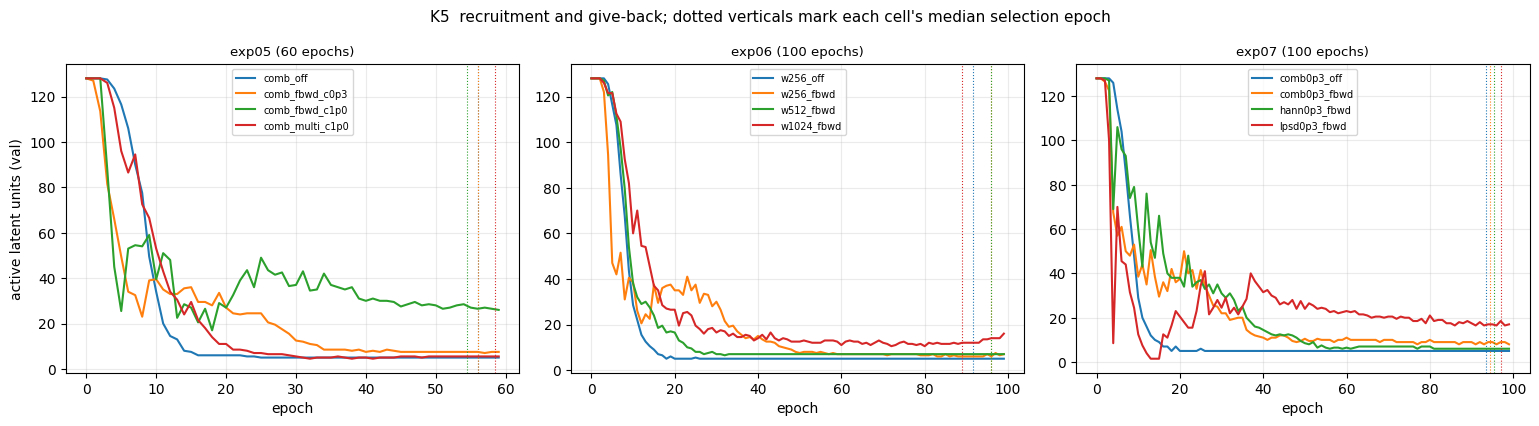

active units: peak after epoch 5, at the selected checkpoint, and at the final epoch
                      n_ep    peak  at_selection  at_end  sel_ep
cell                                                            
exp05_comb_fbwd_c1p0    60   86.00         27.50   25.50    54.5
exp05_comb_off          60  116.50          5.00    5.00    56.0
exp06_w256_fbwd        100   77.17          7.00    6.67    96.0
exp06_w256_off         100  116.33          5.17    5.17    91.5
exp07_comb0p3_fbwd     100   83.17          8.17    7.67    94.5
exp07_comb0p3_off      100   96.83          5.17    5.17    93.5
exp07_hann0p3_fbwd     100   90.17          5.83    5.67    95.5
exp07_lpsd0p3_fbwd     100   83.50         18.25   17.00    97.0


In [52]:
# K5 - the collapse-reversal story across all three experiments, on a common epoch axis
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
for ax, (exp, cells_e) in zip(axes, [
        ("exp05", ["exp05_comb_off", "exp05_comb_fbwd_c0p3", "exp05_comb_fbwd_c1p0", "exp05_comb_multi_c1p0"]),
        ("exp06", ["exp06_w256_off", "exp06_w256_fbwd", "exp06_w512_fbwd", "exp06_w1024_fbwd"]),
        ("exp07", ["exp07_comb0p3_off", "exp07_comb0p3_fbwd", "exp07_hann0p3_fbwd", "exp07_lpsd0p3_fbwd"])]):
    for cell in cells_e:
        n_seeds = CELLS[cell]["n_seeds"]
        med = pd.concat([xcurve(cell, s).set_index("epoch")["val/n_active_units"]
                         for s in range(n_seeds)], axis=1).median(axis=1)
        line, = ax.plot(med.index, med.values, lw=1.5, label=cell.replace(f"{exp}_", ""))
        sel = XS[(XS.cell == cell)]["sel_epoch"].median()
        ax.axvline(sel, color=line.get_color(), lw=0.8, ls=":")
    ax.set_title(f"{exp} ({int(XS[XS.cell == cells_e[0]]['n_ep'].iat[0])} epochs)", fontsize=9.5)
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25); ax.legend(fontsize=7)
axes[0].set_ylabel("active latent units (val)")
fig.suptitle("K5  recruitment and give-back; dotted verticals mark each cell's median selection epoch", fontsize=11)
fig.tight_layout(); plt.show()

print("active units: peak after epoch 5, at the selected checkpoint, and at the final epoch")
print(XS[XS.cell.isin(["exp05_comb_fbwd_c1p0", "exp06_w256_fbwd", "exp07_comb0p3_fbwd", "exp07_hann0p3_fbwd",
                       "exp07_lpsd0p3_fbwd", "exp05_comb_off", "exp06_w256_off", "exp07_comb0p3_off"])]
      .groupby("cell").agg(n_ep=("n_ep", "max"), peak=("nact_peak", "mean"), at_selection=("nact_sel", "mean"),
                           at_end=("nact_end", "mean"), sel_ep=("sel_epoch", "median")).round(2).to_string())

#### Plain-English read of K5

exp05 reported the dynamics win as **collapse reversal**: 5 active units off, ~25 on. On a common axis the
three experiments show what that number was. Every dynamics-on cell recruits to a peak of 77-96 units in
the first epochs and then prunes back; exp05 stops at 26 units, while the ep100 runs of the *same recipe*
continue down to 7-8 and select there.

The obvious explanation - exp05 simply stopped earlier - is **wrong**, and K6 shows why: at matched epoch
40 exp05 already holds 30 units against the ep100 runs' 11-15. The runs diverge long before exp05's budget
ends, because the cosine schedule is annealed over `max_epochs`: a 60-epoch run is at lr 7.7e-5 by epoch 40
while a 100-epoch run is still at 2.0e-4, and pruning stops when the rate collapses. **Latent capacity at
selection is set by the learning-rate horizon, not by the recipe and not by where selection landed.**

What survives is smaller and more interesting: at ep100 the dynamics arm holds one to three units more than
its own dyn-off arm, and it still wins every task - on a latent that is 95% collapsed either way. Capacity
is not what the dynamics term buys. `lpsd0p3_fbwd` is the control that makes this stick: it holds 18 units
at selection, three times the winner, and scores mid-table.

For exp08 this closes one candidate lever and opens another. Recruiting more units is not a route to a
better probe - it is available (`lpsd0p3` does it) and it does not pay. The open question is what the extra
one-to-three units *are*, since they arrive with a real and repeatable downstream gain (Q11).

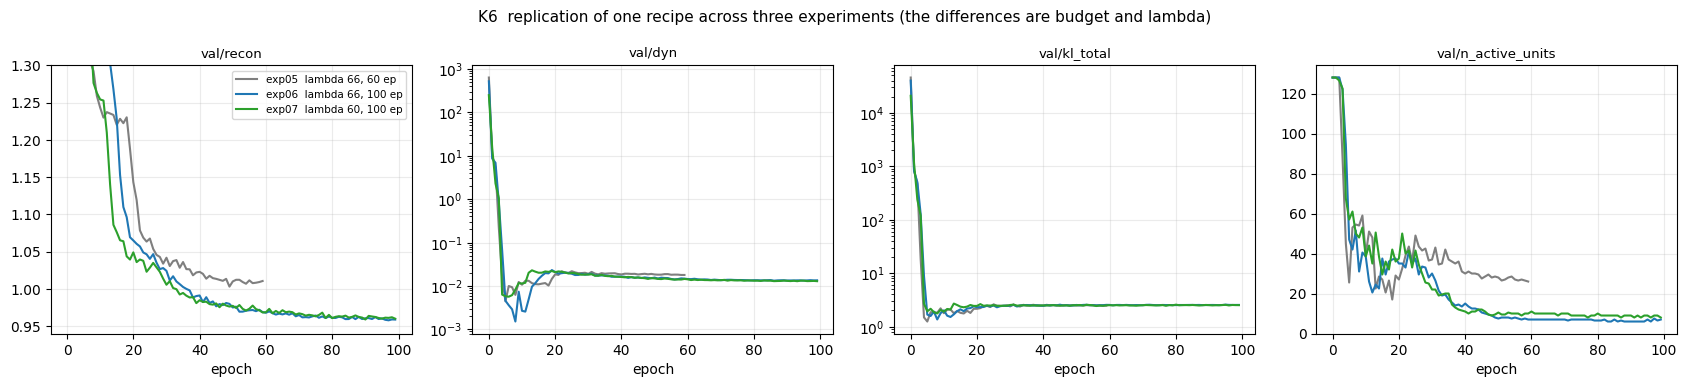

                      n_ep  lam  sel_ep   recon    dose     nact  slope10
cell                                                                     
exp05_comb_fbwd_c1p0    60   66    54.5  1.0044  1.2078  27.5000  -0.0000
exp06_w256_fbwd        100   66    96.0  0.9660  0.9608   7.0000  -0.0001
exp07_comb0p3_fbwd     100   60    94.5  0.9651  0.8432   8.1667  -0.0002

at matched epochs (seed-median): learning rate, active units, reconstruction
epoch                       exp05                       exp06                       exp07
   10    lr 2.8e-04 nact  39.5 r 1.243  lr 2.9e-04 nact  38.5 r 1.376  lr 2.9e-04 nact  38.5 r 1.254
   20    lr 2.3e-04 nact  27.0 r 1.143  lr 2.7e-04 nact  35.0 r 1.065  lr 2.7e-04 nact  37.5 r 1.049
   30    lr 1.5e-04 nact  37.0 r 1.042  lr 2.4e-04 nact  30.0 r 1.024  lr 2.4e-04 nact  22.0 r 1.006
   40    lr 7.7e-05 nact  30.0 r 1.023  lr 2.0e-04 nact  15.0 r 0.991  lr 2.0e-04 nact  11.0 r 0.985
   50    lr 2.3e-05 nact  28.0 r 1.010  lr 1.5e-04 nact   

In [53]:
# K6 - the same nominal cell in three experiments: comb + fwd_bwd at full dose, window 256
REPL = {"exp05_comb_fbwd_c1p0": ("tab:grey", "exp05  lambda 66, 60 ep"),
        "exp06_w256_fbwd": ("tab:blue", "exp06  lambda 66, 100 ep"),
        "exp07_comb0p3_fbwd": ("tab:green", "exp07  lambda 60, 100 ep")}
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
med_repl = {}
for cell, (col, lab) in REPL.items():
    frames = [xcurve(cell, s).set_index("epoch") for s in range(CELLS[cell]["n_seeds"])]
    med_repl[cell] = {k: pd.concat([f[k] for f in frames], axis=1).median(axis=1)
                      for k in ("val/recon", "val/dyn", "val/kl_total", "val/n_active_units", "lr")}
    for ax, key in zip(axes, ["val/recon", "val/dyn", "val/kl_total", "val/n_active_units"]):
        ax.plot(med_repl[cell][key].index, med_repl[cell][key].values, color=col, lw=1.5, label=lab)
for ax, key in zip(axes, ["val/recon", "val/dyn", "val/kl_total", "val/n_active_units"]):
    ax.set_title(key, fontsize=9.5); ax.set_xlabel("epoch"); ax.grid(alpha=0.25)
    if key in ("val/dyn", "val/kl_total"):
        ax.set_yscale("log")
axes[0].set_ylim(0.94, 1.30)   # post-warmup range; epoch 0 sits at ~5 and would flatten the panel
axes[0].legend(fontsize=7.5)
fig.suptitle("K6  replication of one recipe across three experiments (the differences are budget and lambda)", fontsize=11)
fig.tight_layout(); plt.show()

print(XS[XS.cell.isin(REPL)].groupby("cell").agg(
    n_ep=("n_ep", "max"), lam=("lam", "max"), sel_ep=("sel_epoch", "median"), recon=("recon_tail", "mean"),
    dose=("dose_tail", "mean"), nact=("nact_sel", "mean"), slope10=("recon_slope10", "mean")).round(4).to_string())

# Matched-epoch comparison. The cosine schedule is annealed over max_epochs, so two runs of the same
# recipe under different budgets are NOT a truncation of one another: at the same epoch they sit at
# different learning rates, and the latent's active set stops shrinking once the rate collapses.
print("\nat matched epochs (seed-median): learning rate, active units, reconstruction")
header = "epoch  " + "  ".join(f"{c.split('_')[0]:>26s}" for c in REPL)
print(header)
for e in (10, 20, 30, 40, 50, 59):
    row = f"{e:5d}  "
    for cell in REPL:
        m = med_repl[cell]
        row += f"  lr {m['lr'].get(e, np.nan):.1e} nact {m['val/n_active_units'].get(e, np.nan):5.1f} r {m['val/recon'].get(e, np.nan):.3f}"
    print(row)

print("\nepoch-budget audit over every ep100 cell (exp06 + exp07):")
ep100 = XS[XS.n_ep > 60]
print(f"  median |val/recon slope| over the last 10 epochs : {ep100['recon_slope10'].abs().median():.2e} per epoch")
print(f"  runs selecting inside their last 10 epochs        : "
      f"{int((ep100['sel_epoch'] >= ep100['n_ep'] - 10).sum())} / {len(ep100)}")
print(f"  median val-train reconstruction gap               : {ep100['tv_gap_tail'].median():+.4f}")

#### Plain-English read of K6

The same recipe ran three times: exp05 at lambda 66 for 60 epochs, exp06 at lambda 66 for 100, exp07 at
lambda 60 for 100. The two ep100 runs lie on top of each other everywhere (steady-state recon 0.9660 against
0.9651, dose 0.96 against 0.84 - the lambda difference plus the drift correction the exp07 pilots applied).
That is a clean replication across two independent sweeps and two seed counts, and it is the licence for
everything else in this section.

exp05 is **not** a truncation of them, which the matched-epoch table makes explicit. Because the cosine
schedule is annealed over `max_epochs`, the 60-epoch run is at a systematically lower learning rate from
about epoch 25 onward - lr 7.7e-5 at epoch 40 against 2.0e-4 - and both its reconstruction (1.011 vs 0.969
at epoch 59) and its active-unit count (26 vs 7) freeze there. Two consequences worth carrying: a
shorter-budget run of the same recipe is a *different* run, not a prefix; and **no capacity number is
comparable across experiments with different epoch budgets** (this is what F25a records).

The epoch-budget audit at the bottom is the number that would justify a longer schedule, and it does not:
the median absolute slope of `val/recon` over the final ten epochs is 1.3e-4 per epoch and the val-train
gap is flat at -0.002. Extrapolated (generously - it is decaying), another hundred epochs would move
reconstruction by ~0.013, a seventh of what the Hann window returned for free.

#### K7. What the curves say about exp08

Written the way section I of the exp06 notebook was written: each item is a curve-supported statement and
the design consequence that follows. The forward-looking ledger these feed into is
`experiments/open_questions.md`.

1. **Do not spend exp08 on epochs, capacity, or the aux weight.** Reconstruction is flat to 1e-4/epoch by
   epoch 90 with no overfitting (K1, K6), the latent is 95% collapsed under every healthy recipe and the
   cell that recruits three times more units scores mid-table (K5), and the aux weight's whole
   reconstruction cost turns out to be recoverable with a window function (K4). All three are measured
   dead ends at this geometry.

   *Corollary for piloting:* a short run is not a prefix of a long one. The cosine schedule is annealed
   over `max_epochs`, so a 40- or 60-epoch pilot sits at a lower learning rate from its own midpoint
   onward and freezes its latent earlier - which is why exp07's λ pilots needed an empirical drift
   correction (ep40 → ep100 ≈ 0.75) rather than a direct read. Any exp08 pilot must either run the full
   budget or carry that correction explicitly.

2. **The dynamics term is binary, not a dial - so exp08 should ask what it *is*, not how much of it.**
   Inside the fwd+bwd arm the dose varies 0.79-1.07 and orders nothing (K2, within-arm rho ~0), while the
   arm itself separates the two groups of cells with no overlap. Combined with the fact that the win
   survives on a latent that recruits at most three extra units (K5), the natural exp08 question is
   whether a *non-dynamical* smoothness constraint reproduces the effect - the Q4 experiment in the
   ledger, which is one ablation cell and answers the sharpest objection to the world-model framing.

3. **Every readout ranks the four exp07 encoders the same way, and it is not the loss ranking** (K3).
   MIL-winner, mean-pooling and `mean_resid` all put fwd+bwd above dyn-off; `val/recon` puts the *worst*
   encoder first. Two consequences: the exp05 rule against val-loss selection now holds under a pooled
   readout as well, and the aux form is invisible to all three readouts, so an exp08 that varies the aux
   again would be measuring seed noise.

4. **Pooling buys more than any training-side change measured in exp05-07, and it buys it on every arm.**
   The MIL winner beats mean pooling by a comparable margin on trained and untrained encoders alike (K3),
   which is both the argument for adopting it in the tables and the reason it must be selected on
   absolute score rather than on a trained-minus-untrained gap.

5. **The taper's refund is a lead, not just a fix.** A window function returned 9.2% of the reconstruction
   loss with no downstream cost (K4), which says a measurable fraction of the aux term's gradient was
   being spent on an artefact of the framing rather than on the star. The obvious follow-up is the
   frequency-weighted or multitaper aux term flagged in J4: it targets the one measured cost of the
   frozen recipe (13% in the pulsator band) with the machinery already in this notebook.

6. **Keep the curve dump in the protocol, and keep it for auditing only.** Three experiments now agree
   that no validation quantity - total, reconstruction, aux, dose, or active units - selects a cell or a
   seed. What the curves *are* good for is exactly what they did here: proving the replication (K6),
   catching a selection pathology (A6), and pricing a budget question (K1) before anyone spends GPU hours
   on it.

## J. What exp08+ inherits

Measured quantities from this notebook and the constraint each places on the follow-up experiments. These
are inputs to a design session, not a choice of experiment.

1. **Epoch budget is nearly exhausted, and cheaply so.** 22 of 26 fwd_bwd runs still select inside their
   last ten epochs, but they made only 1.3-3.9% of their post-warmup travel over the final 20 (A2). A
   longer budget therefore buys very little per epoch at this geometry; if a follow-up needs headroom it
   should come from the objective or the readout, not from more epochs.

2. **The selection metric has a weight-dependent failure mode.** `recon + w*aux` selects the pre-collapse
   epoch-0 checkpoint whenever the weighted aux improvement is smaller than the reconstruction penalty the
   KL warmup imposes, which at this geometry means any cell at weight 0.1 with the dynamics term off (A6).
   Any experiment that sweeps `recon_aux.weight`, or that lowers it below 0.3, needs either a warmup-aware
   selection floor (restrict the argmin to epochs beyond `beta_warmup_epochs`) or a different metric.
   Every downstream number for such a cell is otherwise an untrained-encoder number wearing a trained label.

3. **The edge defect is closed and it was never a probe cost.** The dipole is abolished rather than
   reduced (antisymmetric component 0.001 +/- 0.011), the residual is a small symmetric taper shadow, and
   the purchase is unavailable by construction (C2, C3). Within an arm, edge severity does not predict
   probe score (B4). Per star the taper leaves the median star's endpoints *better* than its interior
   (ratio 0.71), with the residual confined to the quiet end of the corpus (C5). The edge should not be
   re-opened as a lever; it belongs in the paper as a correctness and standards argument.

4. **The taper's cost is concentrated where the science is.** Under a neutral referee `hann0p3` is 13%
   worse than the baseline at 65-260 uHz and 44-58% better above 1 mHz (D2). Any follow-up that leans on
   low-frequency spectral content, and any asteroseismic probe on this recipe, should carry that number.
   A frequency-weighted or multitaper aux term is the obvious way to keep the sidelobe suppression without
   paying in the pulsator band, and it is measurable with the machinery here.

5. **Reconstruction quality is not the channel the probes read.** The decoder retains about 1% of the true
   peak power and places the dominant peak correctly a quarter of the time under every recipe (D3), and
   `hann0p3` reconstructs the pulsator band *worse* than the baseline while scoring *better* on the
   pulsating probe (G1). Selecting or designing future objectives on reconstruction fidelity, in any band,
   is not supported by this evidence; the exp05/exp06 rule against val-loss selection extends to
   band-resolved spectral fidelity.

6. **hann0p3 and comb0p3 are the same representation.** Cross-recipe canonical correlations sit inside the
   seed-to-seed null and the hann-unique residual is no more informative than a seed difference (F1, F2).
   A follow-up looking for a *different* representation will not get one from the aux window; the axes that
   moved the latent in this project remain the dynamics term and the geometry.

7. **The latent is still collapsed to 5-8 of 128 dimensions** at the selected checkpoint under every
   healthy recipe, and dynamics-on recruits only marginally (E2). Capacity is not the binding constraint on
   any exp07 result, and any claim about representational richness has to be made against that number.

**Where the forward-looking version of this list lives.** These are measurements. The tracked ledger that
turns them into candidate experiments - with status, the cheapest test, and what each answer would change -
is `experiments/open_questions.md` (Q1-Q10). Read that before choosing exp08; its highest-value open entry
is Q1, the 7-probe downstream menu never having been scored on this frozen recipe.


## Summary

| # | Finding | Status |
|---|---|---|
| 1 | Every published exp07 gate reproduces from the raw CSVs to 0.001; the per-star decomposition sums back to the same deltas | CONFIRMED (B1, G0) |
| 2 | G-noregress: `hann0p3` regresses nowhere over 6 seeds (worst -0.009) and gains pulsating +0.018 mean / +0.025 mean_std | CONFIRMED |
| 3 | G-C1 in the winner: fwd_bwd - off is +0.080 eb, +0.046 rotation; pulsating +0.001, so the pulsating lift is aux-driven | CONFIRMED |
| 4 | G-dose passes on all 30 fwd_bwd runs including the extension seeds (cell means 0.78-1.05) | CONFIRMED |
| 5 | Edge severity tracks aux PRESSURE, not form; `lpsd0p3` spikes at 41.5x, so no untapered config combines full pressure with a clean edge | CONFIRMED (B3) |
| 6 | The taper abolishes the dipole rather than shrinking it (antisym 0.001 +/- 0.011 vs comb 2.65); the residual 1.15x is a small, symmetric, seed-repeatable taper shadow | NEW (C2) |
| 7 | The edge purchase is unavailable by construction: untapered log-PSD has a tuned minimum at the learned amplitude, the tapered term is flat to four decimals | NEW (C3) |
| 8 | Within an arm, edge severity does not predict probe score; the apparent pooled correlation is the dynamics axis | NEW (B4) |
| 9 | The taper's cost is real and lands in the pulsator band: -13% at 65-260 uHz, +44-58% above 1 mHz, under a referee neither model trained on | NEW (D2) |
| 10 | Scoring under either training window flips the verdict by up to 4x, so a neutral referee is mandatory for any window comparison | NEW (D1) |
| 11 | Every recipe retains ~1% of true peak power and places the dominant peak correctly ~25% of the time; nothing above 300 uHz is resolved | NEW (D3) |
| 12 | `hann0p3` and `comb0p3` span the same latent subspace: cross-recipe canonical correlations sit inside the seed-pair null | NEW (F1) |
| 13 | No hann-unique information: comb linearly predicts 99.3-99.5% of hann's mu, and the residual probes at seed-difference level | NEW (F2) |
| 14 | The leakage mechanism for the pulsating gain is REFUTED, with the opposite sign (rho -0.20, p 0.013); spectral fidelity in a task's band does not predict its probe score | NEW (G1) |
| 15 | `comb0p1_off` and `lpsd0p1_off` select the epoch-0 pre-collapse checkpoint on all seeds and sit at the untrained floor; a weight-dependent selection-metric failure | NEW (A6) |
| 16 | Two runs lost their pre-resume epochs from the curve dump (no `killedprefix` files in exp07, unlike exp05/06); checkpoints intact | NEW (A1) |
| 18 | Per star, `hann0p3`'s endpoints are reconstructed BETTER than its interior (ratio 0.71 ± 0.01); the 1.15x residual is a quiet-star minority, and `comb0p3`'s absolute edge excess tracks star noise at rho +0.90 | NEW (C5) |
| 17 | Rollout stays closed under every aux configuration (lag-1 ACF -0.014 to +0.012 vs the 0.3 threshold), and quiet still exceeds periodic | CONFIRMED (H1) |

**Verdict.** `hann0p3` survives the audit as the frozen recipe: every pre-registered gate reproduces, the
edge mechanism is closed by construction rather than empirically, and the latent is unchanged. Two things
qualify how it should be written up. The taper is not free, costing 13% of spectral accuracy in the band
this corpus's pulsators occupy, and its one probe gain is not delivered through the spectral channel that
motivated it. And one cell pair in the factorization never trained a checkpoint, which qualifies the
weight-0.1 dyn-off arms of the README's supporting claims without touching any headline gate.